# TCN-Transformer Log Anomaly Notebook

Run All и всё. Тетрадка сама проходит по нескольким датасетам, при необходимости готовит данные, запускает обучение/evaluation/report assets и показывает общие метрики. Код моделей, XAI, графиков и preprocessing остаётся в `src/` и `scripts/`.


In [1]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import load_config, save_config
import src.utils.notebook_workflow as notebook_workflow
notebook_workflow = importlib.reload(notebook_workflow)
dataset_links_table = notebook_workflow.dataset_links_table
load_metric_tables_many = notebook_workflow.load_metric_tables_many
load_training_histories_many = notebook_workflow.load_training_histories_many
make_notebook_config = notebook_workflow.make_notebook_config
make_full_data_config = notebook_workflow.make_full_data_config
make_memory_saver_config = notebook_workflow.make_memory_saver_config
split_label_summary = notebook_workflow.split_label_summary
real_vs_synthetic_label_summary = notebook_workflow.real_vs_synthetic_label_summary
detailed_label_summary = notebook_workflow.detailed_label_summary
config_audit_table = notebook_workflow.config_audit_table
expected_detection_counts = notebook_workflow.expected_detection_counts
run_stage = notebook_workflow.run_stage
cuda_status = notebook_workflow.cuda_status
ensure_loghub_gold_labels = notebook_workflow.ensure_loghub_gold_labels

PROJECT_ROOT


PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer')

## Настройки

По умолчанию запускаются все три датасета в RAM-safe режиме. Если нужно ещё легче, оставь в `DATASETS` только один датасет.


In [2]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import load_config, save_config
import src.utils.notebook_workflow as notebook_workflow
notebook_workflow = importlib.reload(notebook_workflow)

dataset_links_table = notebook_workflow.dataset_links_table
load_metric_tables_many = notebook_workflow.load_metric_tables_many
load_training_histories_many = notebook_workflow.load_training_histories_many
make_notebook_config = notebook_workflow.make_notebook_config
make_full_data_config = notebook_workflow.make_full_data_config
make_memory_saver_config = notebook_workflow.make_memory_saver_config
split_label_summary = notebook_workflow.split_label_summary
real_vs_synthetic_label_summary = notebook_workflow.real_vs_synthetic_label_summary
detailed_label_summary = notebook_workflow.detailed_label_summary
config_audit_table = notebook_workflow.config_audit_table
expected_detection_counts = notebook_workflow.expected_detection_counts
run_stage = notebook_workflow.run_stage
cuda_status = notebook_workflow.cuda_status
ensure_loghub_gold_labels = notebook_workflow.ensure_loghub_gold_labels

DATASETS = ['lo2', 'loghub2', 'rcaeval']  # варианты: 'lo2', 'loghub2', 'rcaeval', 'demo'
FORCE_PREPARE = True
FORCE_TRAIN = True  # поставь True, если надо переобучить уже существующие checkpoints на 100 эпох
RUN_ENSEMBLE = True
RUN_EVALUATION = True
RUN_REPORT = True
FULL_DATA = False  # True жрёт RAM: снимает caps и грузит весь raw сразу
MEMORY_SAVER = True  # щадящий RAM/VRAM режим для ноутбука
MEMORY_BATCH_SIZE = 64
TRAINING_NUM_WORKERS = 0  # важно для Jupyter/sandbox; GPU при этом используется
MAX_LOCALIZATION_SAMPLES = 128  # сколько synthetic samples брать для XAI/heatmap
TRAINING_EPOCHS = 1000
TRAINING_PATIENCE = 8
NOTEBOOK_COMPACT_LOGS = False  # не чистим training logs, чтобы можно было листать эпохи
print({'cuda': cuda_status()})

CONFIG_BY_DATASET = {
    'lo2': PROJECT_ROOT / 'configs' / 'experiment_lo2.yaml',
    'loghub2': PROJECT_ROOT / 'configs' / 'experiment_loghub.yaml',
    'rcaeval': PROJECT_ROOT / 'configs' / 'experiment_rcaeval.yaml',
    'demo': PROJECT_ROOT / 'configs' / 'experiment_demo.yaml',
}

DATASET_STATE = {}
for dataset_name in DATASETS:
    if dataset_name == 'loghub2':
        label_path = ensure_loghub_gold_labels(PROJECT_ROOT / 'data' / 'raw' / 'loghub2')
        print(f'Loghub gold labels: {label_path}')
    base_config_path = CONFIG_BY_DATASET[dataset_name]
    base_config = load_config(base_config_path)
    output_dir = PROJECT_ROOT / 'outputs' / dataset_name
    config_factory = make_full_data_config if FULL_DATA else make_notebook_config
    notebook_config_path = config_factory(base_config_path, dataset_name=dataset_name, output_dir=output_dir)
    if MEMORY_SAVER:
        notebook_config_path = make_memory_saver_config(
            notebook_config_path,
            dataset_name=dataset_name,
            output_dir=output_dir,
            batch_size=MEMORY_BATCH_SIZE,
            max_localization_samples=MAX_LOCALIZATION_SAMPLES,
            epochs=TRAINING_EPOCHS,
            patience=TRAINING_PATIENCE,
            num_workers=TRAINING_NUM_WORKERS,
        )
    notebook_config = load_config(notebook_config_path)
    used_config_path = PROJECT_ROOT / notebook_config['data']['processed_dir'] / 'used_config.yaml'
    DATASET_STATE[dataset_name] = {
        'base_config_path': base_config_path,
        'notebook_config_path': notebook_config_path,
        'used_config_path': used_config_path,
        'output_dir': output_dir,
    }

DATASET_STATE


{'lo2': {'base_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/configs/experiment_lo2.yaml'),
  'notebook_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/lo2_memory_saver_notebook_config.yaml'),
  'used_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/processed/lo2/used_config.yaml'),
  'output_dir': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/lo2')},
 'loghub2': {'base_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/configs/experiment_loghub.yaml'),
  'notebook_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/loghub2_memory_saver_notebook_config.yaml'),
  'used_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/processed/loghub2/used_c

## Датасеты

Справка по источникам и папкам raw-данных.


In [3]:
print(f"lo2-sample.zip\nHDFS.zip\nRE1-OB.zip")

lo2-sample.zip
HDFS.zip
RE1-OB.zip


In [4]:
dataset_links_table()


,dataset,target_dir,url,note
0,lo2,data/raw/lo2 там 2 папки logs и metrics,https://doi.org/10.5281/zenodo.14265858,LO2 / Light-OAuth2 microservice API anomaly da...
1,loghub2,data/raw/loghub2 без папки тупо данные,https://zenodo.org/records/8275861,Loghub-2.0 collection. Put extracted log files...
2,rcaeval,data/raw/rcaeval папка сюда RE1-OB тупо копиро...,https://zenodo.org/records/14590730,RCAEval benchmark repository/data. Put extract...


## Баланс Данных

Перед обучением видно, сколько normal/anomaly уже лежит в подготовленных split-файлах. В RAM-safe режиме `FULL_DATA=False`, поэтому используются лимиты из YAML-конфигов и готовые splits переиспользуются, если они уже есть.


In [5]:
label_summary = split_label_summary(DATASET_STATE)
real_synthetic_summary = real_vs_synthetic_label_summary(DATASET_STATE)
detailed_summary = detailed_label_summary(DATASET_STATE)

print('ИТОГ: real / synthetic / all по каждому датасету')
real_synthetic_summary


ИТОГ: real / synthetic / all по каждому датасету


,dataset,source,normal,anomaly,total
0,lo2,real,140,2670,2810
1,lo2,synthetic,31,19,50
2,lo2,real+synthetic,171,2689,2860
3,loghub2,real,1563,0,1563
4,loghub2,synthetic,238,262,500
5,loghub2,real+synthetic,1801,262,2063
6,rcaeval,real,5450,999,6449
7,rcaeval,synthetic,920,824,1744
8,rcaeval,real+synthetic,6370,1823,8193
9,ALL,real,7153,3669,10822


### Детализация По Split

Если нужно посмотреть train/val/test/test_synthetic отдельно, эта таблица ниже.


### Полная таблица: каждый split отдельно

Здесь видно, где именно normal/anomaly: train, val, val_synthetic, test, test_synthetic.


In [6]:
detailed_summary


,dataset,source,split,normal,anomaly,total,normal_pct,anomaly_pct,status
0,lo2,real,train,90,0,90,100.00,0.00,ok
1,lo2,real,val,22,1187,1209,1.82,98.18,ok
2,lo2,synthetic,val_synthetic,12,10,22,54.55,45.45,ok
3,lo2,real,test,28,1483,1511,1.85,98.15,ok
4,lo2,synthetic,test_synthetic,19,9,28,67.86,32.14,ok
5,lo2,real,real_total,140,2670,2810,4.98,95.02,total
6,lo2,synthetic,synthetic_total,31,19,50,62.00,38.00,total
7,lo2,real+synthetic,dataset_total,171,2689,2860,5.98,94.02,total
8,loghub2,real,train,1000,0,1000,100.00,0.00,ok
9,loghub2,real,val,250,0,250,100.00,0.00,ok


In [7]:
label_summary


,dataset,source,split,normal,anomaly,total,status,normal_pct,anomaly_pct
0,lo2,real,train,90,0,90,ok,100.00,0.00
1,lo2,real,val,22,1187,1209,ok,1.82,98.18
2,lo2,synthetic,val_synthetic,12,10,22,ok,54.55,45.45
3,lo2,real,test,28,1483,1511,ok,1.85,98.15
4,lo2,synthetic,test_synthetic,19,9,28,ok,67.86,32.14
5,loghub2,real,train,1000,0,1000,ok,100.00,0.00
6,loghub2,real,val,250,0,250,ok,100.00,0.00
7,loghub2,synthetic,val_synthetic,119,131,250,ok,47.60,52.40
8,loghub2,real,test,313,0,313,ok,100.00,0.00
9,loghub2,synthetic,test_synthetic,119,131,250,ok,47.60,52.40


## Разметка И Проверка Перед Обучением

Этот блок запускается до обучения. Он готовит split-файлы, подключает gold labels для Loghub/HDFS, проверяет конфиги и показывает, сколько normal/anomaly должно попасть в validation/test.


In [ ]:
from IPython.display import display

LABELING_ALREADY_PREPARED = False

for dataset_name, state in DATASET_STATE.items():
    print('=' * 80)
    print(f'LABELING: {dataset_name}')
    print('=' * 80)
    if dataset_name == 'loghub2':
        label_path = ensure_loghub_gold_labels(PROJECT_ROOT / 'data' / 'raw' / 'loghub2')
        print(f'Loghub gold labels: {label_path}')

    prepare_needed = FORCE_PREPARE or not state['used_config_path'].exists()
    if prepare_needed:
        print(f'Preparing labels/splits from {state["notebook_config_path"]} ...')
        run_stage('prepare_data', state['notebook_config_path'])
    else:
        print(f'Prepared labels/splits already exist: {state["used_config_path"]}')

LABELING_ALREADY_PREPARED = True

config_audit = config_audit_table(DATASET_STATE)
label_summary = split_label_summary(DATASET_STATE)
real_synthetic_summary = real_vs_synthetic_label_summary(DATASET_STATE)
detailed_summary = detailed_label_summary(DATASET_STATE)
expected_counts = expected_detection_counts(DATASET_STATE)

print('Проверка подключенных конфигов/model settings:')
display(config_audit)
print('Сколько модель должна обнаружить после разметки:')
display(expected_counts)
print('Детализация по split:')
display(detailed_summary)


## Автозапуск Pipeline По Всем Датасетам

Эта ячейка делает всю работу. Для каждого датасета результаты пишутся в свою папку: `outputs/lo2`, `outputs/loghub2`, `outputs/rcaeval`.


In [8]:
def model_checkpoint(output_dir, model_name):
    return output_dir / 'models' / f'{model_name}_best.pt'

for dataset_name, state in DATASET_STATE.items():
    if dataset_name == 'loghub2':
        label_path = ensure_loghub_gold_labels(PROJECT_ROOT / 'data' / 'raw' / 'loghub2')
        print(f'Loghub gold labels: {label_path}')
    print('=' * 80)
    print(f'DATASET: {dataset_name}')
    print('=' * 80)

    prepare_needed = (FORCE_PREPARE and not globals().get('LABELING_ALREADY_PREPARED', False)) or not state['used_config_path'].exists()
    if prepare_needed:
        print(f'Preparing data from {state["notebook_config_path"]} ...')
        run_stage('prepare_data', state['notebook_config_path'])
    else:
        print(f'Prepared config already exists: {state["used_config_path"]}')

    config_path_for_run = state['used_config_path'] if state['used_config_path'].exists() else state['notebook_config_path']
    if MEMORY_SAVER:
        config_path_for_run = make_memory_saver_config(
            config_path_for_run,
            dataset_name=dataset_name,
            output_dir=state['output_dir'],
            batch_size=MEMORY_BATCH_SIZE,
            max_localization_samples=MAX_LOCALIZATION_SAMPLES,
            epochs=TRAINING_EPOCHS,
            patience=TRAINING_PATIENCE,
            num_workers=TRAINING_NUM_WORKERS,
        )
    else:
        config_path_for_run = make_notebook_config(config_path_for_run, dataset_name=dataset_name, output_dir=state['output_dir'])

    config = load_config(config_path_for_run)
    config.setdefault('notebook', {})['compact_training_log'] = NOTEBOOK_COMPACT_LOGS
    save_config(config, config_path_for_run)
    config = load_config(config_path_for_run)

    training = config['training']
    print({
        'config': str(config_path_for_run),
        'output_dir': config['project']['output_dir'],
        'epochs': training['epochs'],
        'patience': training['patience'],
        'batch_size': training['batch_size'],
        'device': training['device'],
        'target_recall': config.get('threshold', {}).get('target_recall'),
    })

    if 'expected_counts' in globals():
        print('Expected labels for this dataset:')
        display(expected_counts[expected_counts['dataset'] == dataset_name])

    for model_name, stage in [('tcn_ae', 'train_tcn_ae'), ('tcn_transformer_ae', 'train_tcn_transformer_ae')]:
        ckpt = model_checkpoint(state['output_dir'], model_name)
        if FORCE_TRAIN or not ckpt.exists():
            print()
            print(f'Training {dataset_name}/{model_name} ...')
            run_stage(stage, config_path_for_run)
        else:
            print(f'Skip training {dataset_name}/{model_name}: checkpoint exists -> {ckpt}')

    ensemble_enabled = bool(config.get('ensemble', {}).get('enabled', False)) and RUN_ENSEMBLE
    if ensemble_enabled:
        member_seeds = config.get('ensemble', {}).get('member_seeds', [])
        missing_members = [
            seed for seed in member_seeds
            if not (state['output_dir'] / 'models' / f'tcn_transformer_ae_seed{int(seed)}_best.pt').exists()
        ]
        if FORCE_TRAIN or missing_members:
            print()
            print(f'Training {dataset_name}/transformer ensemble; missing_members={missing_members}')
            run_stage('train_tcn_transformer_ensemble', config_path_for_run)
        else:
            print(f'Skip ensemble training for {dataset_name}: all member checkpoints exist')
    else:
        print(f'Skip ensemble training for {dataset_name}: disabled by config or RUN_ENSEMBLE=False')

    if RUN_EVALUATION:
        for stage in ['evaluate_detection', 'evaluate_localization', 'evaluate_adaptive_threshold']:
            print()
            print(f'Running {dataset_name}/{stage} ...')
            run_stage(stage, config_path_for_run)

    if RUN_REPORT:
        print()
        print(f'Generating report assets for {dataset_name} ...')
        run_stage('generate_report_assets', config_path_for_run)

print()
print('Done. Per-dataset outputs are in outputs/<dataset_name>/.')


DATASET: lo2
Preparing data from /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/lo2_memory_saver_notebook_config.yaml ...
Loading raw dataset=lo2 from /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/raw/lo2
Loaded rows=595,201 sessions=7,552 labels={1: 584044, 0: 11157}
Cleaning messages and building event templates...
Built vocab_size=32,826; building sequences...
Sequences=7,552 label_counts={0: 140, 1: 7412}
Prepared. vocab=32826 train_normal=90 val=1209 test=1511 synthetic=28
Label summary: train={0: 90, 1: 0} val={0: 22, 1: 1187} test={0: 28, 1: 1483} val_synthetic={0: 12, 1: 10} synthetic={0: 19, 1: 9}
Use config: /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/processed/lo2/used_config.yaml
{'config': '/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/lo2_memory_saver_notebook_config.yaml', 'output_dir': '/home/danderety/Documents/GitHub/TCN_Transf

## Общие Метрики

Таблицы ниже объединяют результаты из `outputs/<dataset>/metrics/` и добавляют колонку `dataset`.


In [9]:
OUTPUT_DIRS = {name: state['output_dir'] for name, state in DATASET_STATE.items()}
tables = load_metric_tables_many(OUTPUT_DIRS)
tables.keys()


dict_keys(['detection', 'localization', 'adaptive_threshold', 'final_comparison'])

In [10]:
tables.get('detection')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,...,val_f1,val_fp,val_fn,raw_val_fp,raw_val_fn,safe_val_fp,safe_val_fn,validation_monitor_source,ensemble_members,ensemble_seeds
0,lo2,0.981469,1.000000,0.990648,0.983347,0.490945,0,28,0,1483,...,0.990818,22,0,10,616,22,11,real_val,NaN,NaN
1,lo2,0.981457,0.999326,0.990311,0.983185,0.489934,0,28,1,1482,...,0.990818,22,0,13,461,22,11,real_val,NaN,NaN
2,lo2,0.981469,1.000000,0.990648,0.983183,0.491860,0,28,0,1483,...,0.990818,22,0,13,461,22,11,real_val,3.0,42 43 44
3,loghub2,0.000000,0.000000,0.000000,NaN,NaN,0,313,0,0,...,0.415214,369,0,57,86,367,1,real_val_plus_val_synthetic,NaN,NaN
4,loghub2,0.000000,0.000000,0.000000,NaN,NaN,1,312,0,0,...,0.417197,366,0,31,96,361,1,real_val_plus_val_synthetic,NaN,NaN
5,loghub2,0.000000,0.000000,0.000000,NaN,NaN,0,313,0,0,...,0.415873,368,0,3,113,363,1,real_val_plus_val_synthetic,3.0,42 43 44
6,rcaeval,0.337386,1.000000,0.504545,0.488894,0.647599,0,1090,0,555,...,0.504545,872,0,50,355,872,0,real_val,NaN,NaN
7,rcaeval,0.337386,1.000000,0.504545,0.343224,0.511893,0,1090,0,555,...,0.504545,872,0,872,0,872,0,real_val,NaN,NaN
8,rcaeval,0.337386,1.000000,0.504545,0.387458,0.563698,0,1090,0,555,...,0.504545,872,0,0,444,872,0,real_val,3.0,42 43 44


In [11]:
tables.get('localization')


,dataset,top_1_hit,iou_at_1,top_3_hit,iou_at_3,top_5_hit,iou_at_5,mean_rank,model,xai_method,ensemble_members,ensemble_seeds
0,lo2,0.111111,0.111111,0.555556,0.166667,0.555556,0.103704,13.777778,tcn_ae,reconstruction_error_heatmap,NaN,NaN
1,lo2,0.111111,0.111111,0.444444,0.138889,0.444444,0.085185,18.222222,tcn_transformer_ae,reconstruction_error_heatmap,NaN,NaN
2,lo2,0.000000,0.000000,0.111111,0.027778,0.111111,0.018519,39.222222,tcn_transformer_ae,transformer_attention_received,NaN,NaN
3,lo2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,41.555556,tcn_transformer_ae_ensemble,ensemble_transformer_attention_received,3.0,42 43 44
4,loghub2,0.233333,0.233333,0.333333,0.108333,0.400000,0.077778,32.250000,tcn_ae,reconstruction_error_heatmap,NaN,NaN
5,loghub2,0.233333,0.233333,0.283333,0.100000,0.333333,0.069444,35.333333,tcn_transformer_ae,reconstruction_error_heatmap,NaN,NaN
6,loghub2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,78.133333,tcn_transformer_ae,transformer_attention_received,NaN,NaN
7,loghub2,0.016667,0.008333,0.033333,0.008333,0.050000,0.008889,80.866667,tcn_transformer_ae_ensemble,ensemble_transformer_attention_received,3.0,42 43 44
8,rcaeval,0.324324,0.229730,0.540541,0.200450,0.540541,0.129730,30.243243,tcn_ae,reconstruction_error_heatmap,NaN,NaN
9,rcaeval,0.459459,0.310811,0.513514,0.200450,0.513514,0.136036,32.000000,tcn_transformer_ae,reconstruction_error_heatmap,NaN,NaN


In [12]:
tables.get('adaptive_threshold')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,false_positive_rate,false_negative_rate,model,threshold_type,window_size,adaptive_window_size_config,k,validation_monitor_source
0,lo2,0.986689,0.399865,0.569098,0.983185,0.489934,20,8,890,593,0.285714,0.600135,tcn_transformer_ae,adaptive,151,auto,2.0,real_val
1,loghub2,0.000000,0.000000,0.000000,NaN,NaN,187,126,0,0,0.402556,0.000000,tcn_transformer_ae,adaptive,31,auto,2.0,real_val_plus_val_synthetic
2,rcaeval,0.547619,0.041441,0.077052,0.343224,0.511893,1071,19,532,23,0.017431,0.958559,tcn_transformer_ae,adaptive,164,auto,2.0,real_val


In [13]:
tables.get('final_comparison')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,...,raw_val_fp,raw_val_fn,safe_val_fp,safe_val_fn,validation_monitor_source,ensemble_members,ensemble_seeds,window_size,adaptive_window_size_config,k
0,lo2,0.981469,1.000000,0.990648,0.983347,0.490945,0,28,0,1483,...,10.0,616.0,22.0,11.0,real_val,NaN,NaN,NaN,NaN,NaN
1,lo2,0.981457,0.999326,0.990311,0.983185,0.489934,0,28,1,1482,...,13.0,461.0,22.0,11.0,real_val,NaN,NaN,NaN,NaN,NaN
2,lo2,0.981469,1.000000,0.990648,0.983183,0.491860,0,28,0,1483,...,13.0,461.0,22.0,11.0,real_val,3.0,42 43 44,NaN,NaN,NaN
3,lo2,0.986689,0.399865,0.569098,0.983185,0.489934,20,8,890,593,...,NaN,NaN,NaN,NaN,real_val,NaN,NaN,151.0,auto,2.0
4,loghub2,0.000000,0.000000,0.000000,NaN,NaN,0,313,0,0,...,57.0,86.0,367.0,1.0,real_val_plus_val_synthetic,NaN,NaN,NaN,NaN,NaN
5,loghub2,0.000000,0.000000,0.000000,NaN,NaN,1,312,0,0,...,31.0,96.0,361.0,1.0,real_val_plus_val_synthetic,NaN,NaN,NaN,NaN,NaN
6,loghub2,0.000000,0.000000,0.000000,NaN,NaN,0,313,0,0,...,3.0,113.0,363.0,1.0,real_val_plus_val_synthetic,3.0,42 43 44,NaN,NaN,NaN
7,loghub2,0.000000,0.000000,0.000000,NaN,NaN,187,126,0,0,...,NaN,NaN,NaN,NaN,real_val_plus_val_synthetic,NaN,NaN,31.0,auto,2.0
8,rcaeval,0.337386,1.000000,0.504545,0.488894,0.647599,0,1090,0,555,...,50.0,355.0,872.0,0.0,real_val,NaN,NaN,NaN,NaN,NaN
9,rcaeval,0.337386,1.000000,0.504545,0.343224,0.511893,0,1090,0,555,...,872.0,0.0,872.0,0.0,real_val,NaN,NaN,NaN,NaN,NaN


## История Обучения

Все эпохи, `train_loss`, `val_loss`, validation recall/F1/FP/FN, threshold и `BEST saved` сохраняются в `outputs/<dataset>/metrics/*_training_history.csv`.


In [14]:
histories = load_training_histories_many(OUTPUT_DIRS)
histories.keys()


dict_keys(['lo2/tcn_ae_training_history', 'lo2/tcn_transformer_ae_seed42_training_history', 'lo2/tcn_transformer_ae_seed43_training_history', 'lo2/tcn_transformer_ae_seed44_training_history', 'lo2/tcn_transformer_ae_training_history', 'loghub2/tcn_ae_training_history', 'loghub2/tcn_transformer_ae_seed42_training_history', 'loghub2/tcn_transformer_ae_seed43_training_history', 'loghub2/tcn_transformer_ae_seed44_training_history', 'loghub2/tcn_transformer_ae_training_history', 'rcaeval/tcn_ae_training_history', 'rcaeval/tcn_transformer_ae_seed42_training_history', 'rcaeval/tcn_transformer_ae_seed43_training_history', 'rcaeval/tcn_transformer_ae_seed44_training_history', 'rcaeval/tcn_transformer_ae_training_history'])

In [15]:
next(iter(histories.values())) if histories else None


,model,epoch,epochs_total,train_loss,val_loss,stop_patience,threshold_patience,threshold_monitor_interval,best_val_loss_before_epoch,best_checkpoint_score_before_epoch,...,threshold_signal,threshold_checkpoint,threshold_save_loss_tolerance,checkpoint_score,best_checkpoint_score_after_epoch,is_best,best_val_loss_after_epoch,best_detection_score_after_epoch,patience_after_epoch,epoch_time_sec
0,tcn_ae,1,1000,10.515124,10.303939,9,9,5,NaN,NaN,...,True,False,0.05,10.303939,10.303939,True,10.303939,0.990818,0,9.368725
1,tcn_ae,2,1000,10.228477,10.051432,9,9,5,10.303939,10.303939,...,False,False,0.05,10.051432,10.051432,True,10.051432,0.990818,0,0.978244
2,tcn_ae,3,1000,9.955132,9.752728,9,9,5,10.051432,10.051432,...,False,False,0.05,9.752728,9.752728,True,9.752728,0.990818,0,0.961425
3,tcn_ae,4,1000,9.567584,9.365983,9,9,5,9.752728,9.752728,...,False,False,0.05,9.365983,9.365983,True,9.365983,0.990818,0,1.003401
4,tcn_ae,5,1000,9.132805,8.841361,9,9,5,9.365983,9.365983,...,False,False,0.05,8.841361,8.841361,True,8.841361,0.990818,0,9.027970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,tcn_ae,61,1000,0.615274,1.839574,9,9,5,1.824229,1.824229,...,False,False,0.05,1.839574,1.824229,False,1.824229,0.990818,5,0.724356
61,tcn_ae,62,1000,0.577694,1.833179,9,9,5,1.824229,1.824229,...,False,False,0.05,1.833179,1.824229,False,1.824229,0.990818,6,0.724417
62,tcn_ae,63,1000,0.614770,1.835300,9,9,5,1.824229,1.824229,...,False,False,0.05,1.835300,1.824229,False,1.824229,0.990818,7,0.727436
63,tcn_ae,64,1000,0.589149,1.852032,9,9,5,1.824229,1.824229,...,False,False,0.05,1.852032,1.824229,False,1.824229,0.990818,8,8.730419


## Где Смотреть Файлы

- `outputs/lo2/`, `outputs/loghub2/`, `outputs/rcaeval/` — отдельные результаты по датасетам.
- `outputs/<dataset>/models/` — checkpoints.
- `outputs/<dataset>/metrics/` — CSV-метрики и истории обучения.
- `outputs/<dataset>/predictions/` — scores, predictions, XAI JSON.
- `outputs/<dataset>/figures/` — heatmap/attention/summary PNG.
- `outputs/<dataset>/reports/summary.md` — markdown-сводка.


## Картинки По Датасетам

После `RUN_REPORT=True` здесь показываются сохранённые confusion matrices и общие heatmap по каждому датасету и модели.


### lo2

**Матрицы ошибок**

`confusion_matrix_tcn_ae_combined.png`

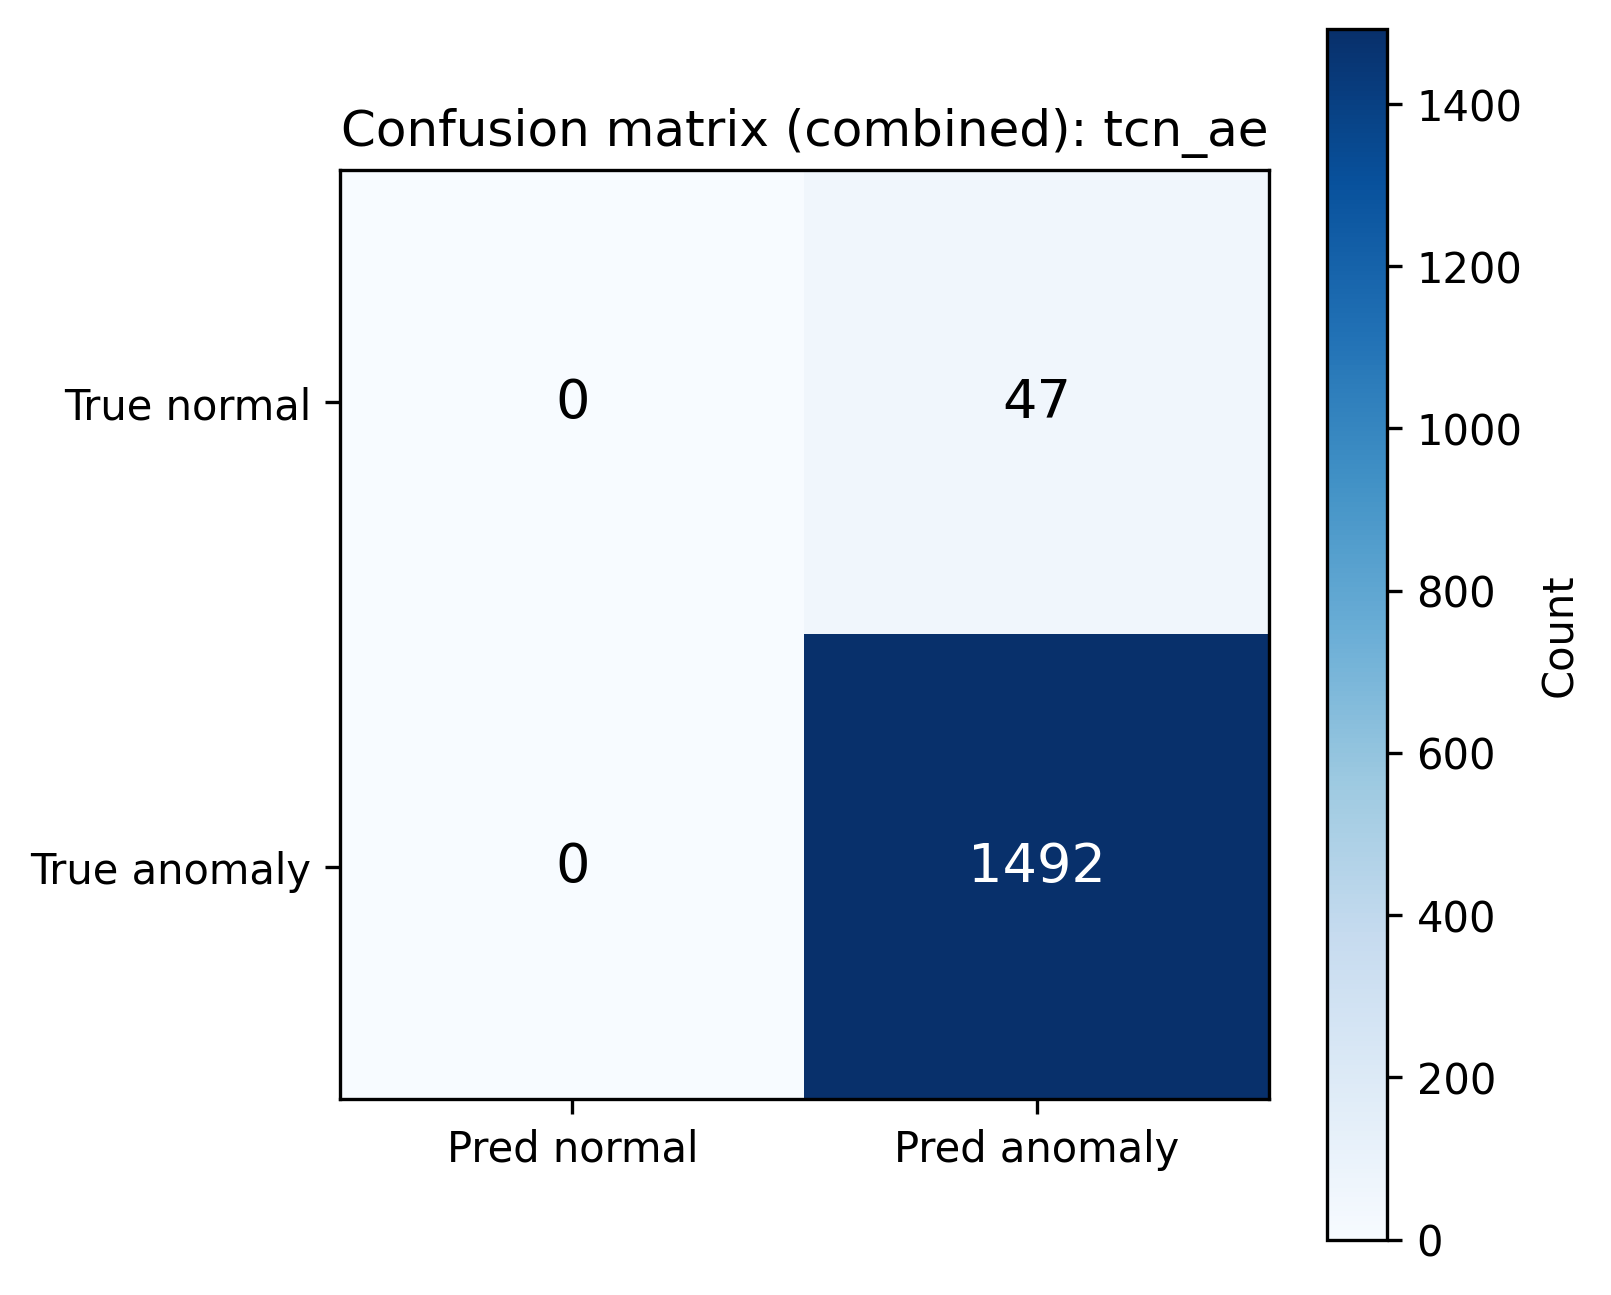

`confusion_matrix_tcn_ae_real.png`

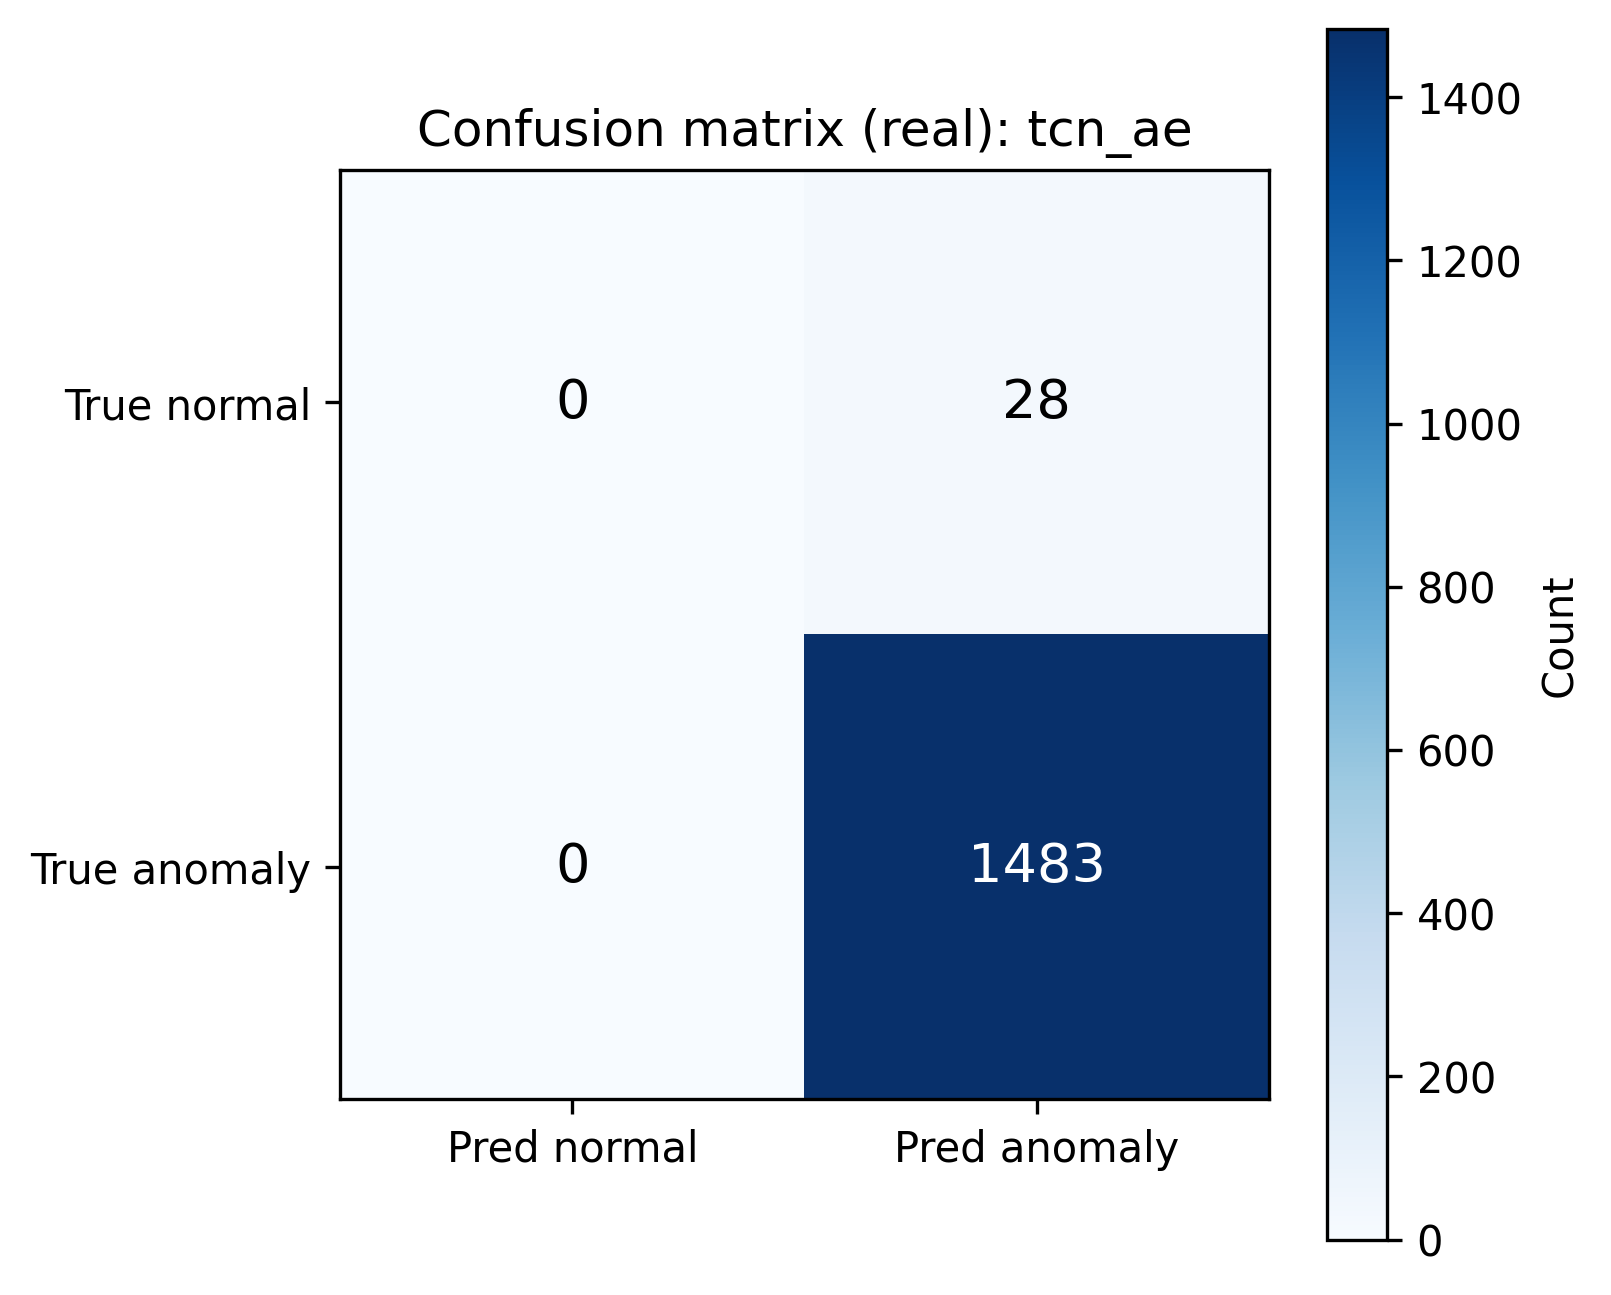

`confusion_matrix_tcn_ae_synthetic.png`

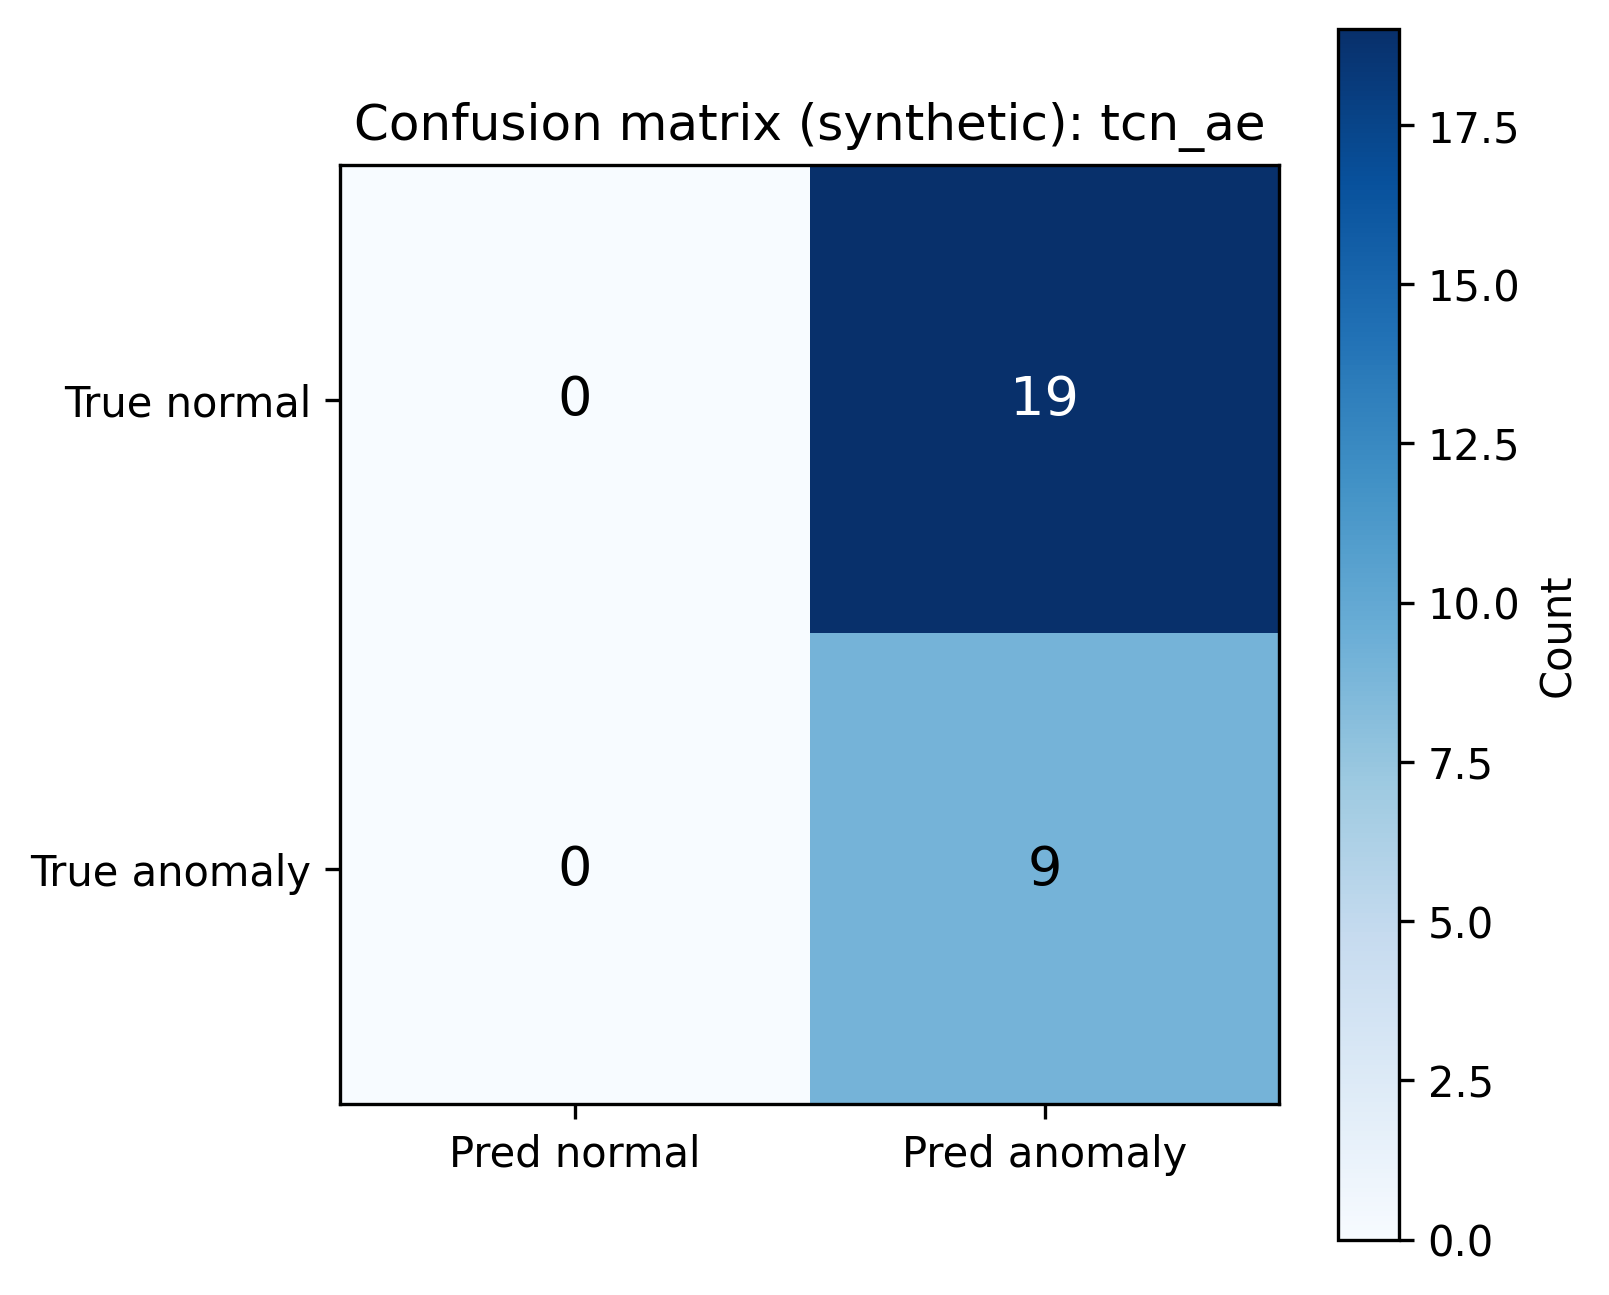

`confusion_matrix_tcn_transformer_ae_combined.png`

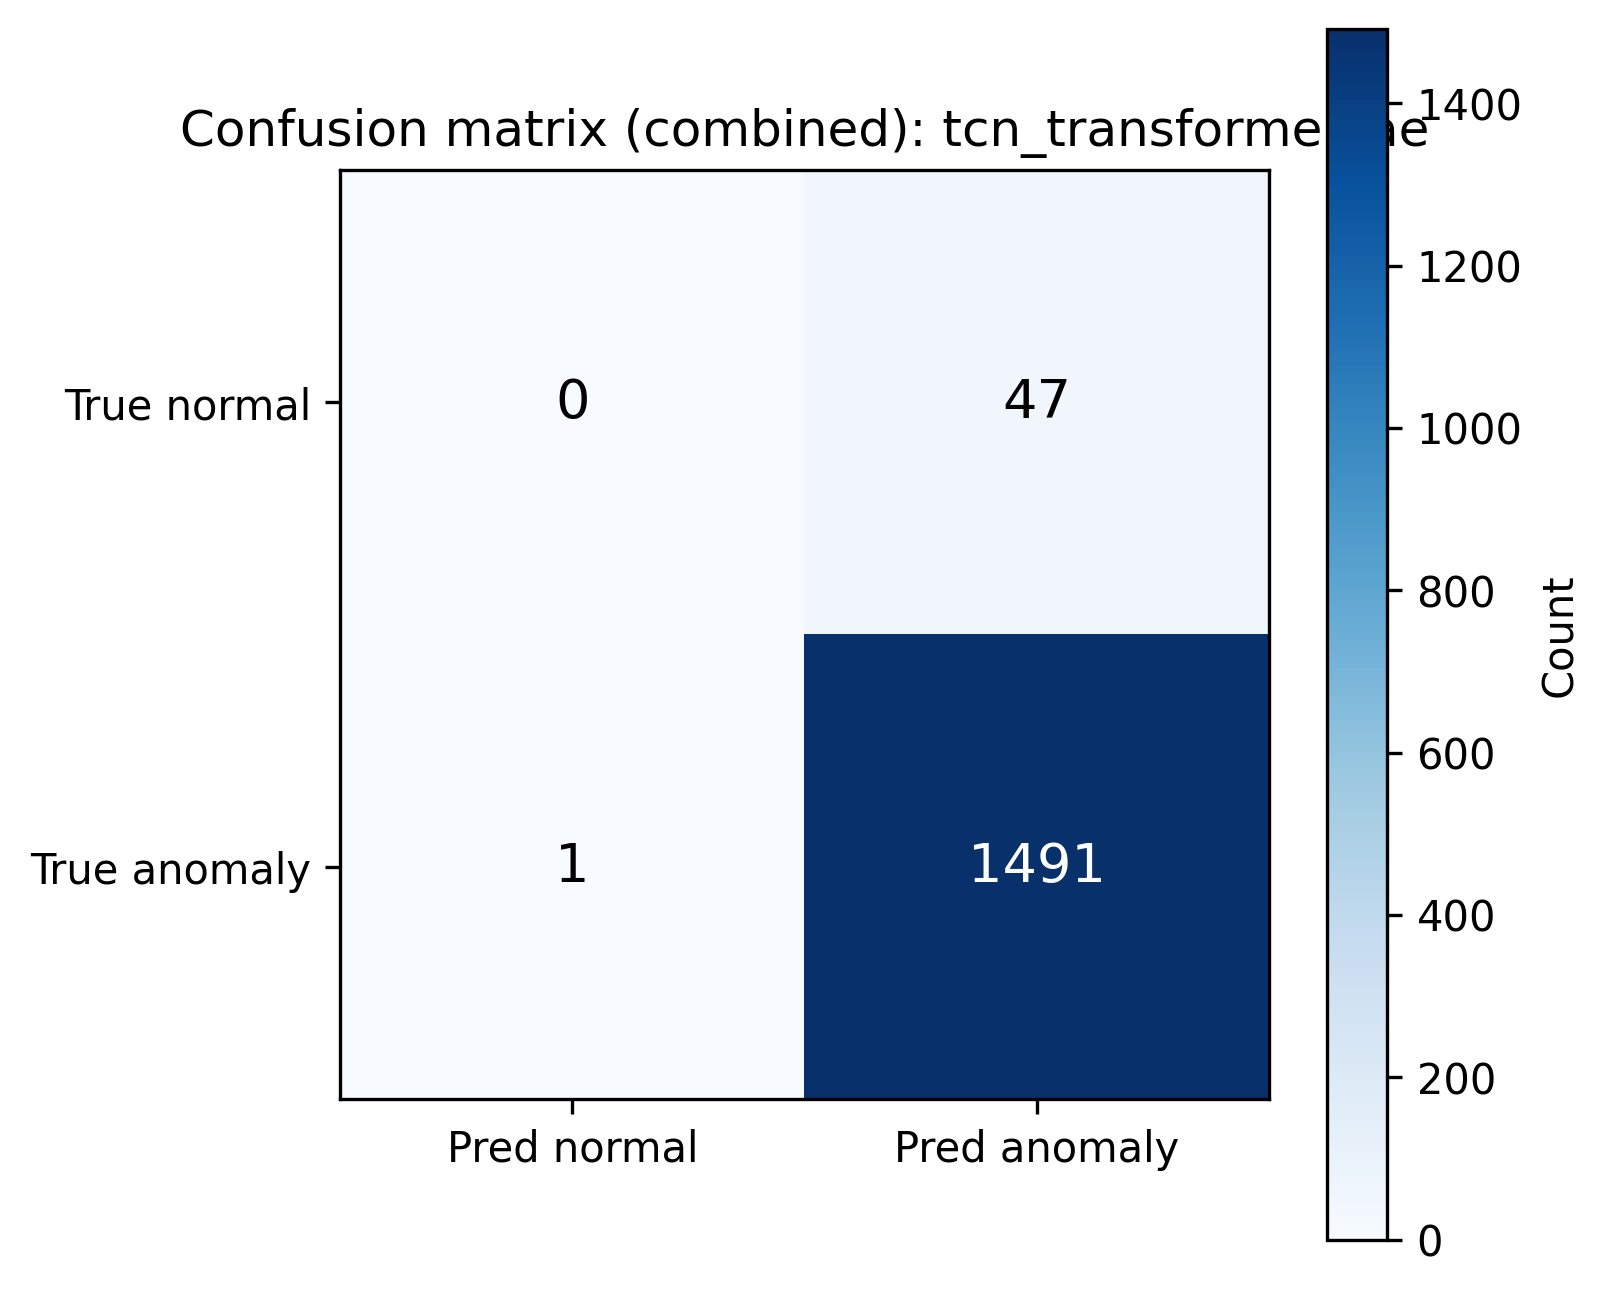

`confusion_matrix_tcn_transformer_ae_ensemble_combined.png`

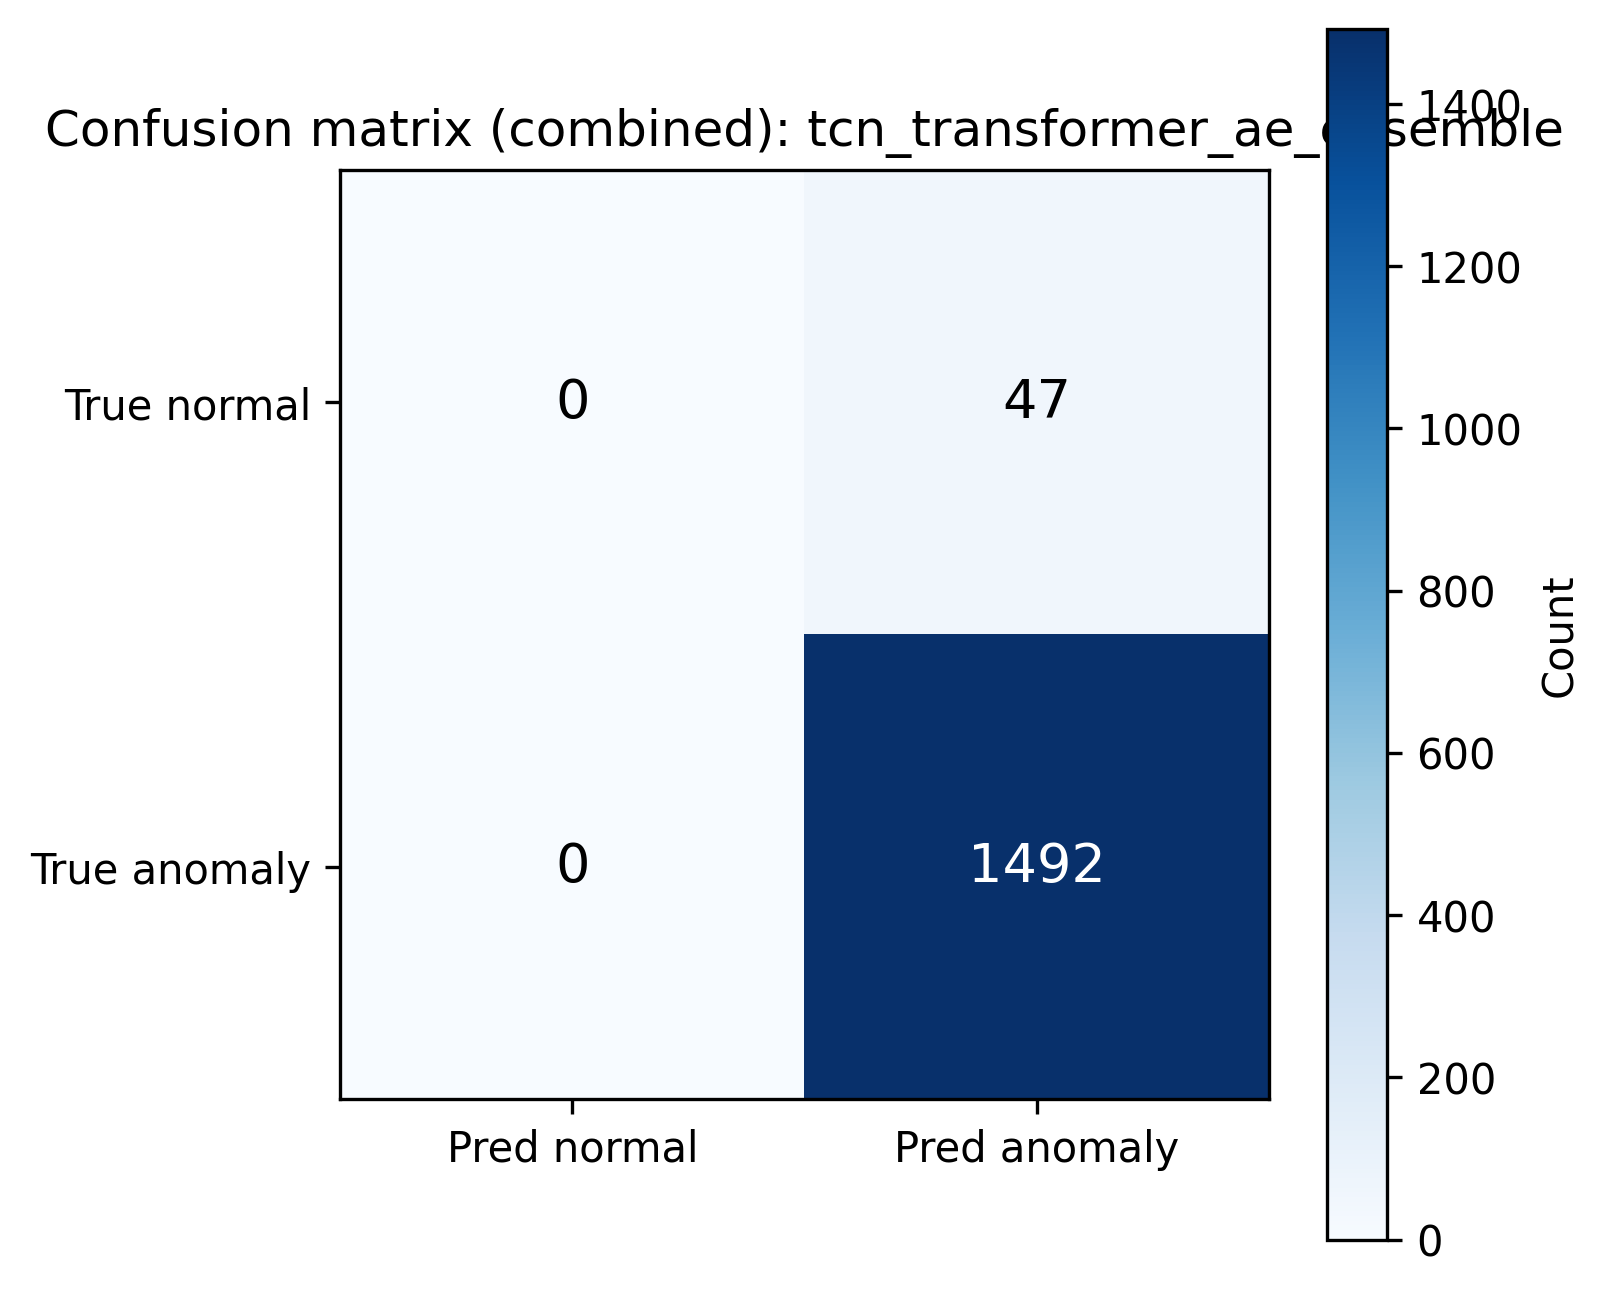

`confusion_matrix_tcn_transformer_ae_ensemble_real.png`

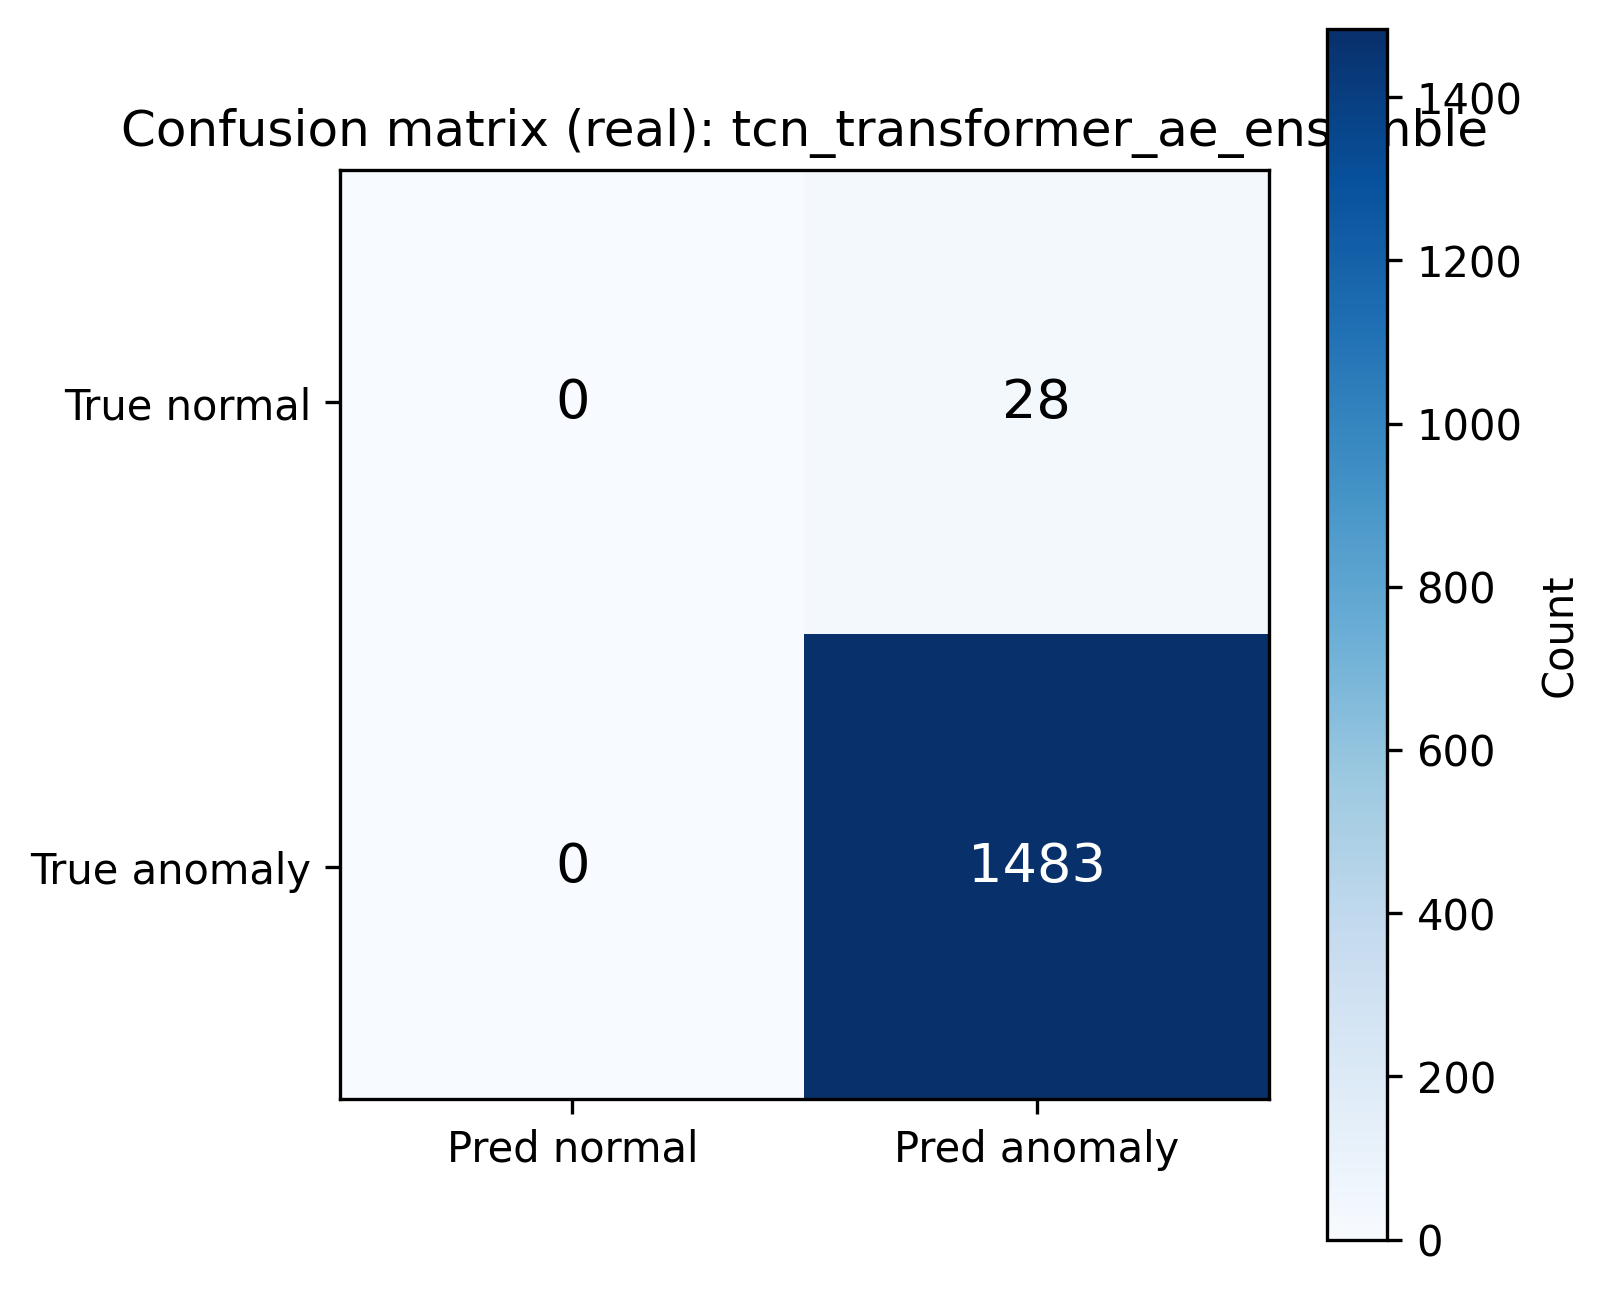

`confusion_matrix_tcn_transformer_ae_ensemble_synthetic.png`

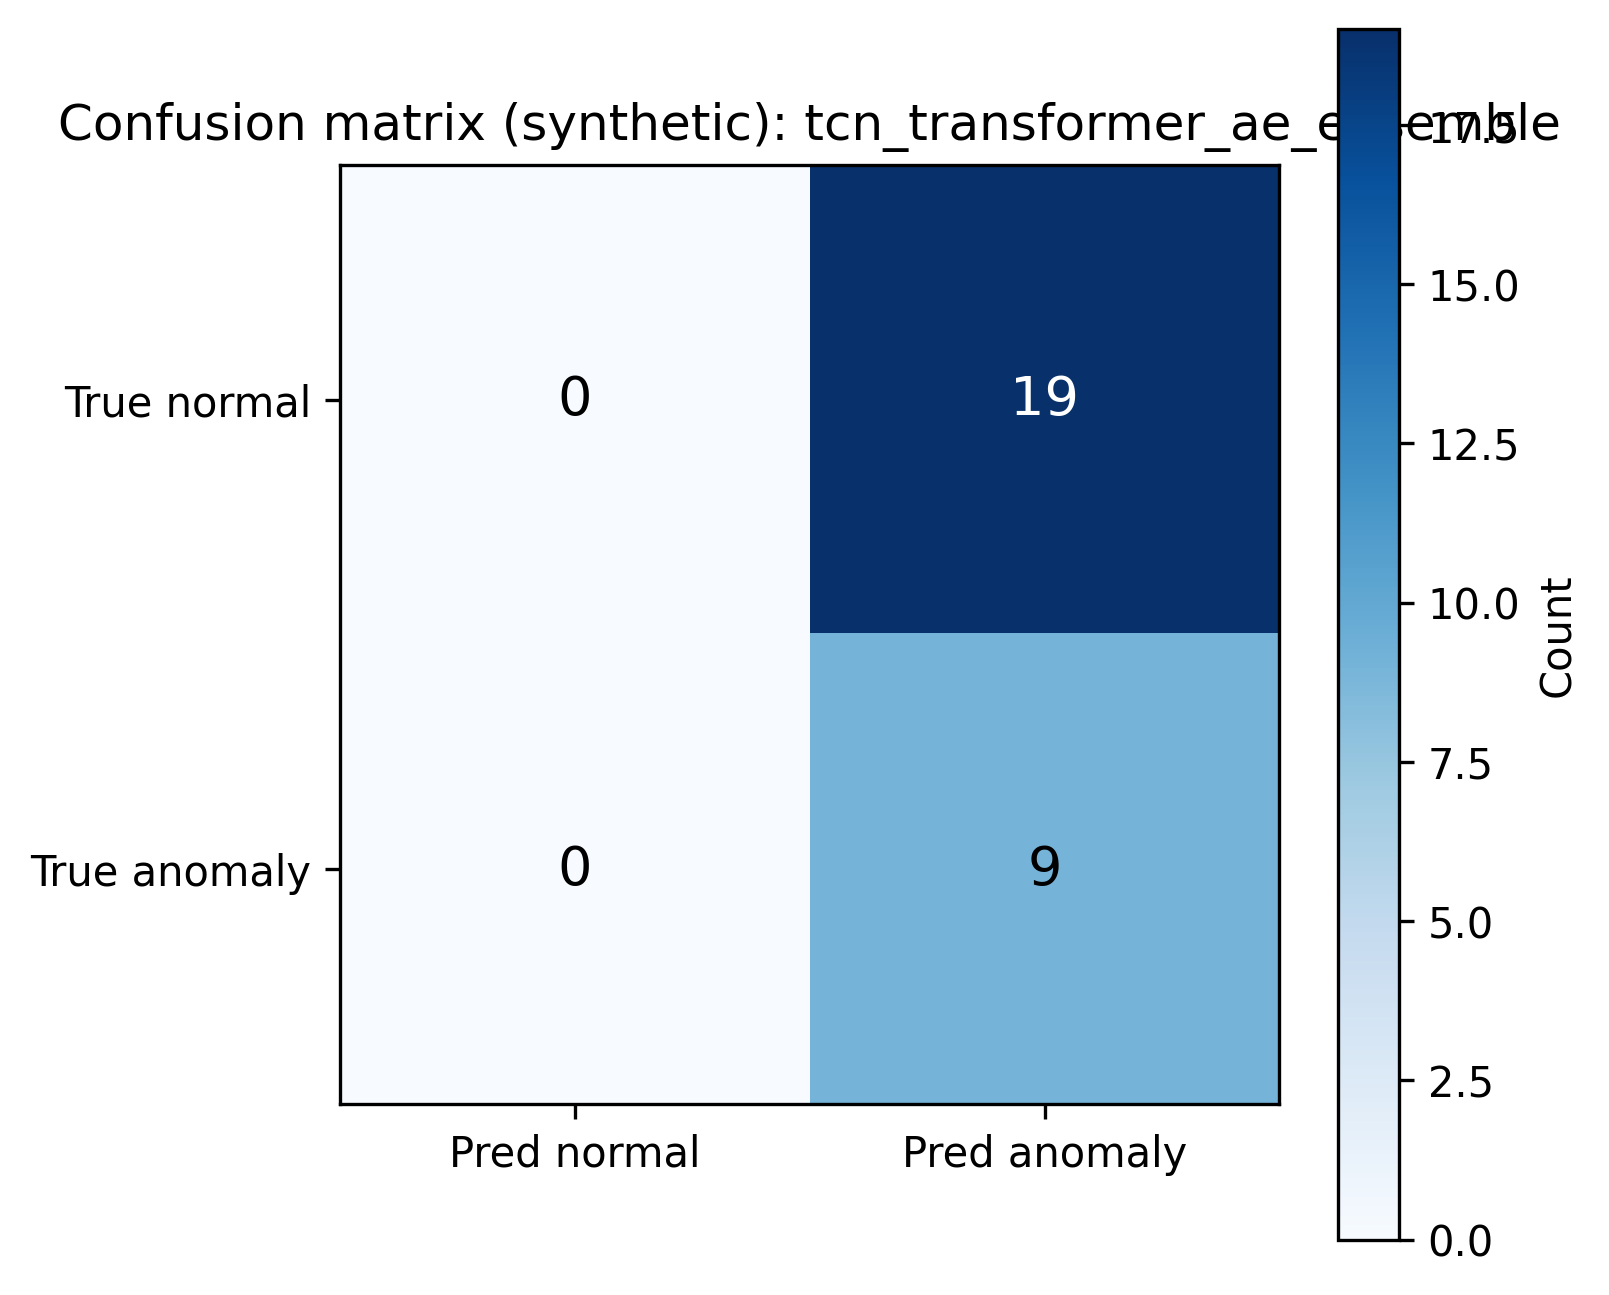

`confusion_matrix_tcn_transformer_ae_real.png`

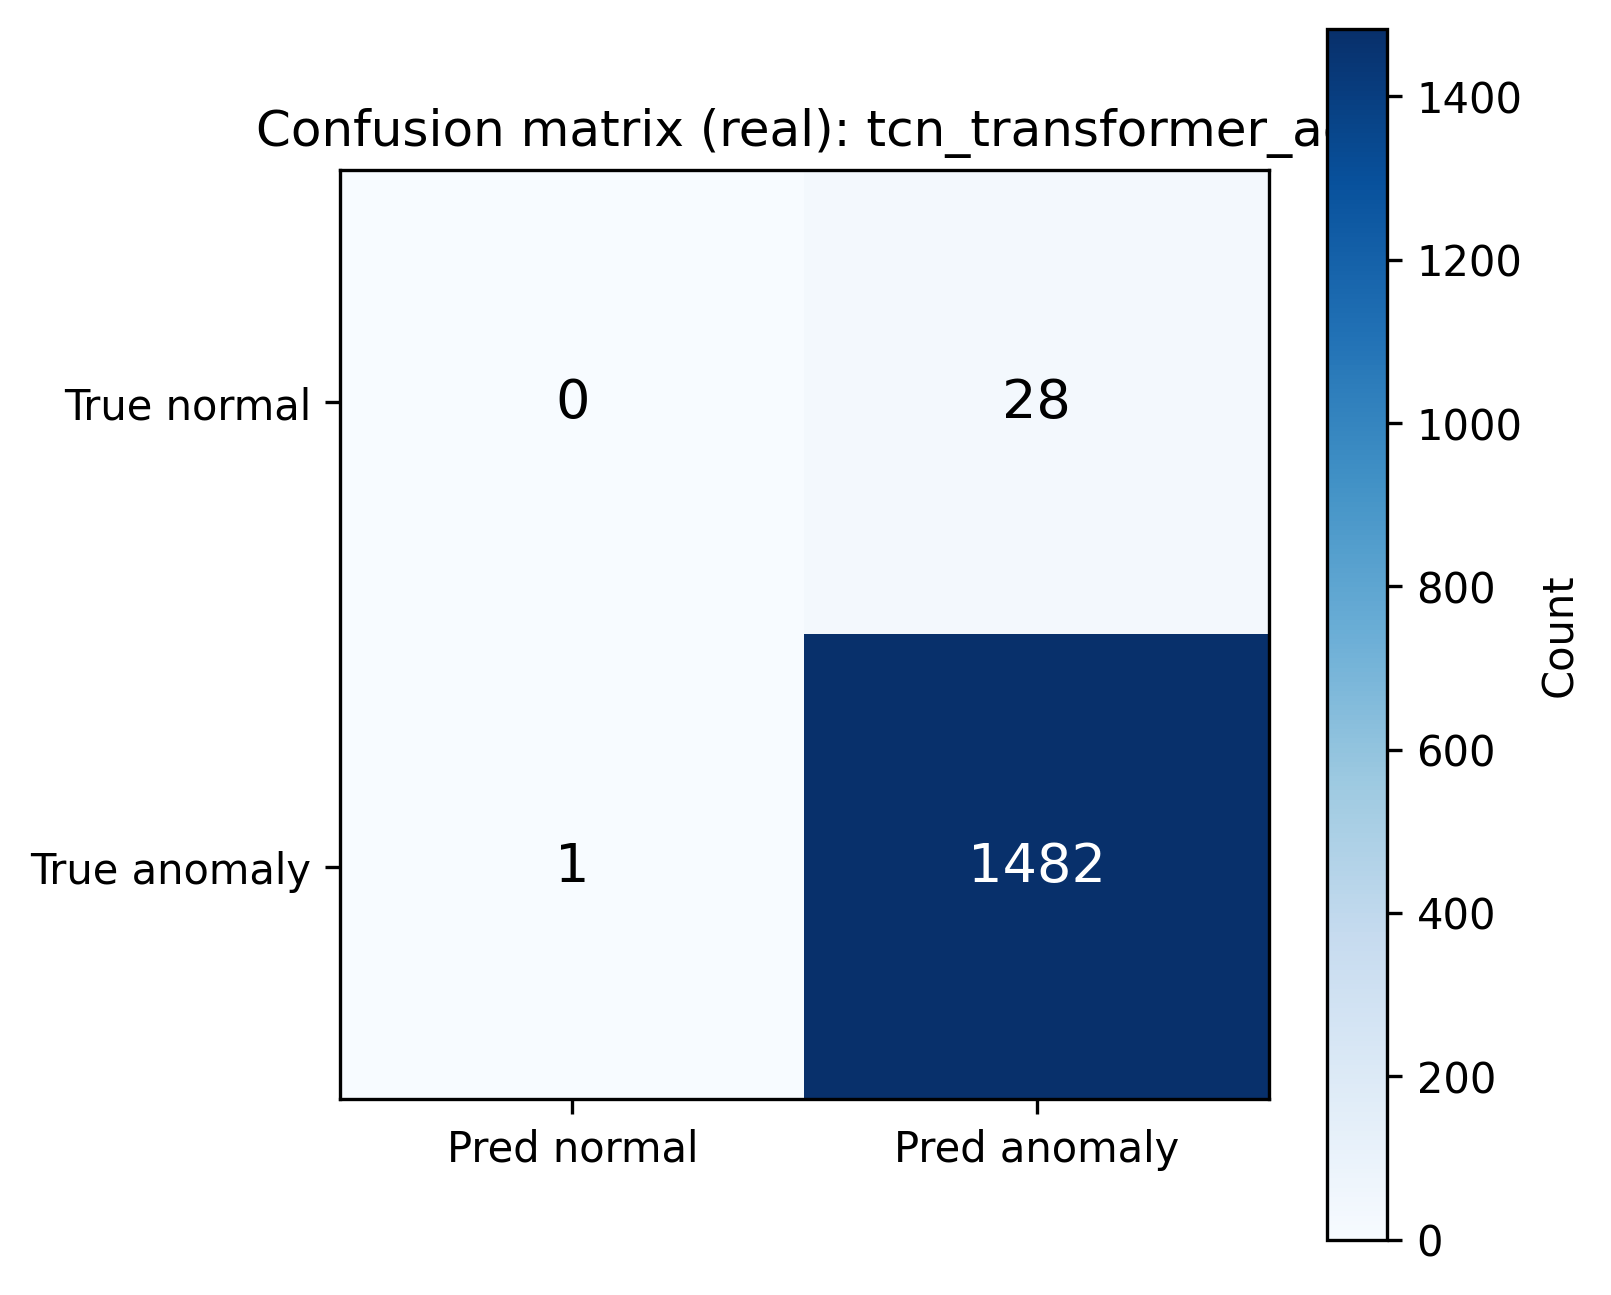

`confusion_matrix_tcn_transformer_ae_synthetic.png`

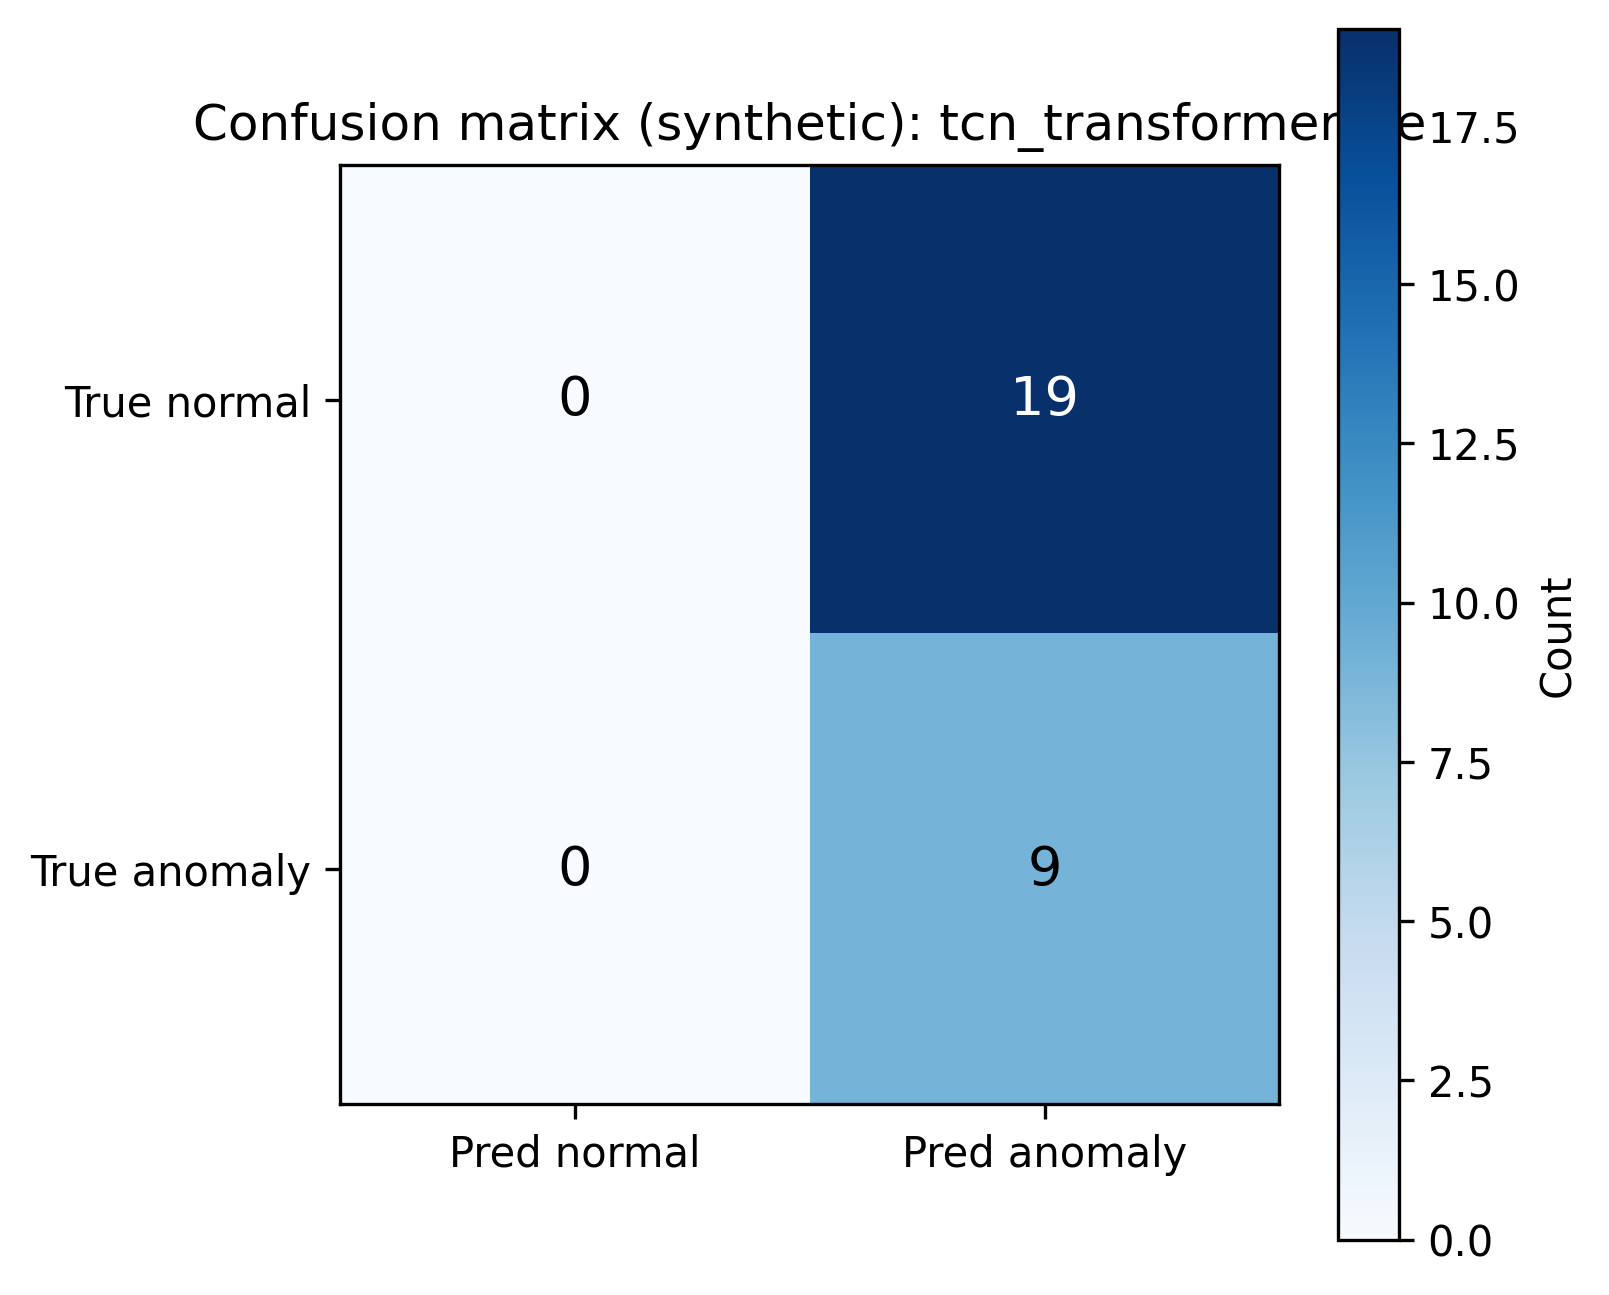

**Общие heatmap**

`aggregate_heatmap_tcn_ae_reconstruction.png`

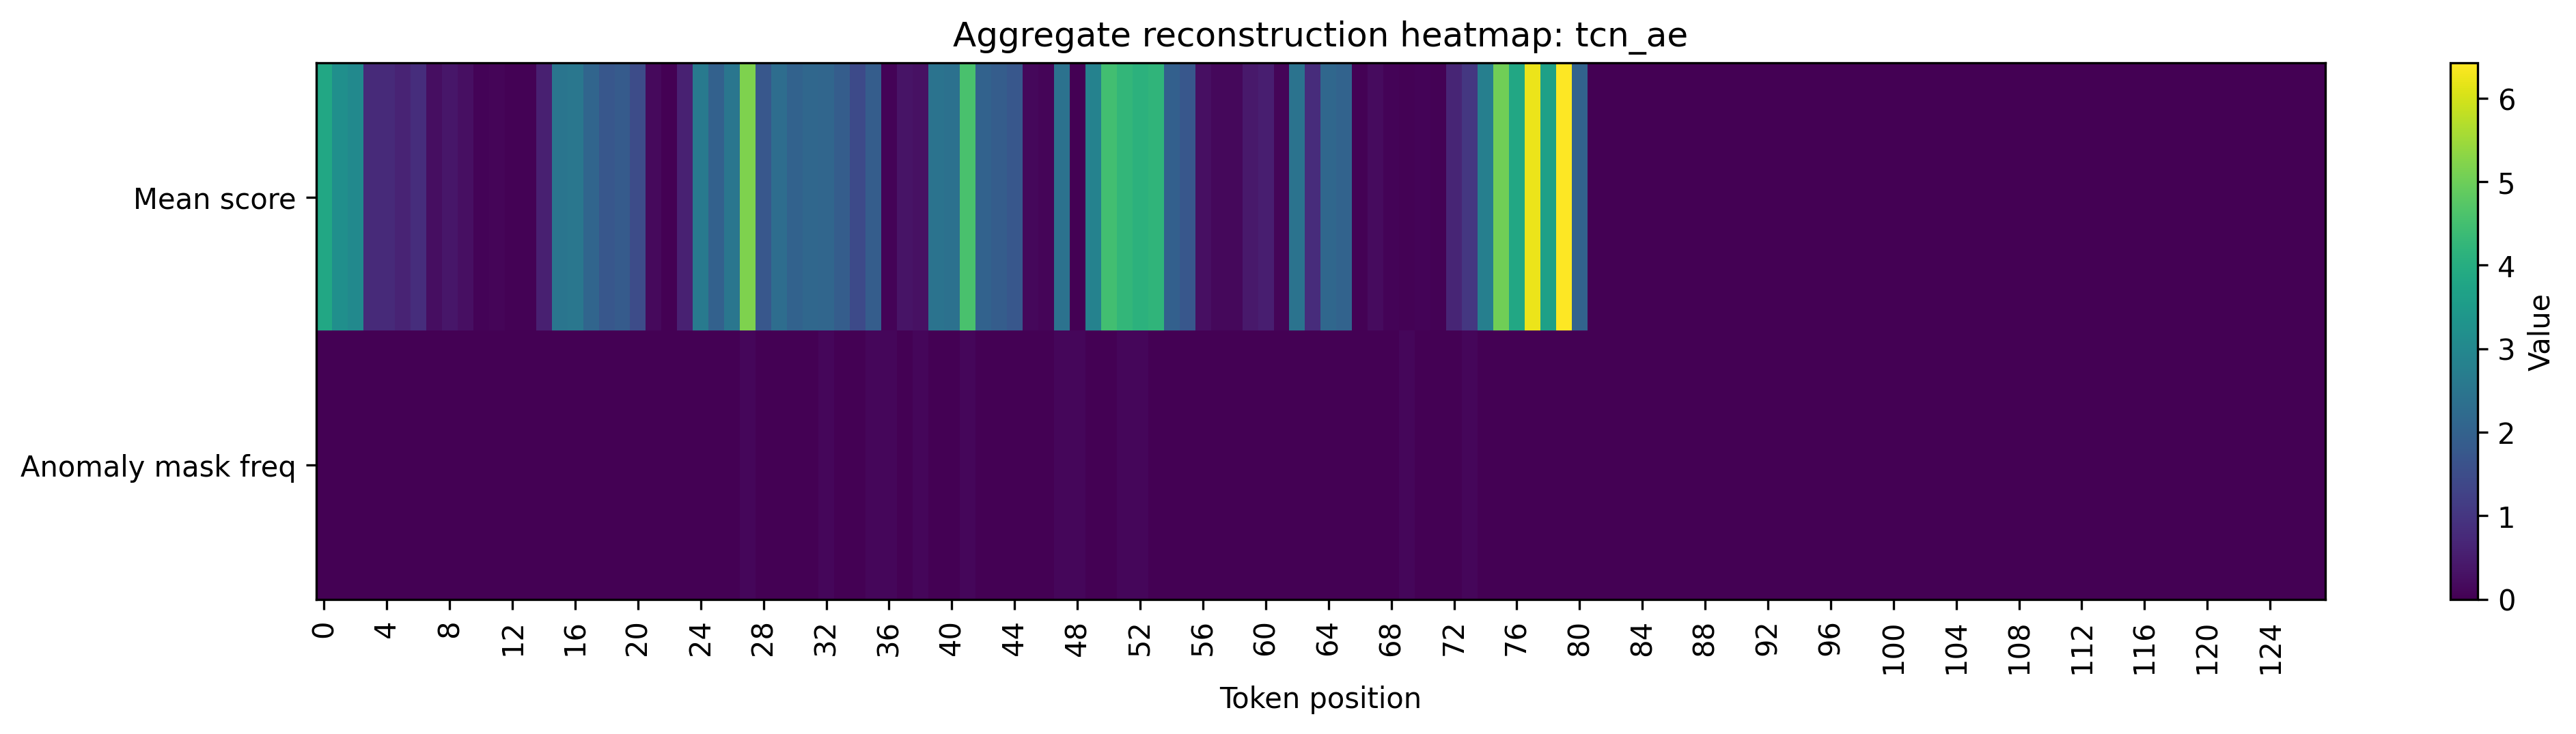

`aggregate_heatmap_tcn_transformer_ae_attention.png`

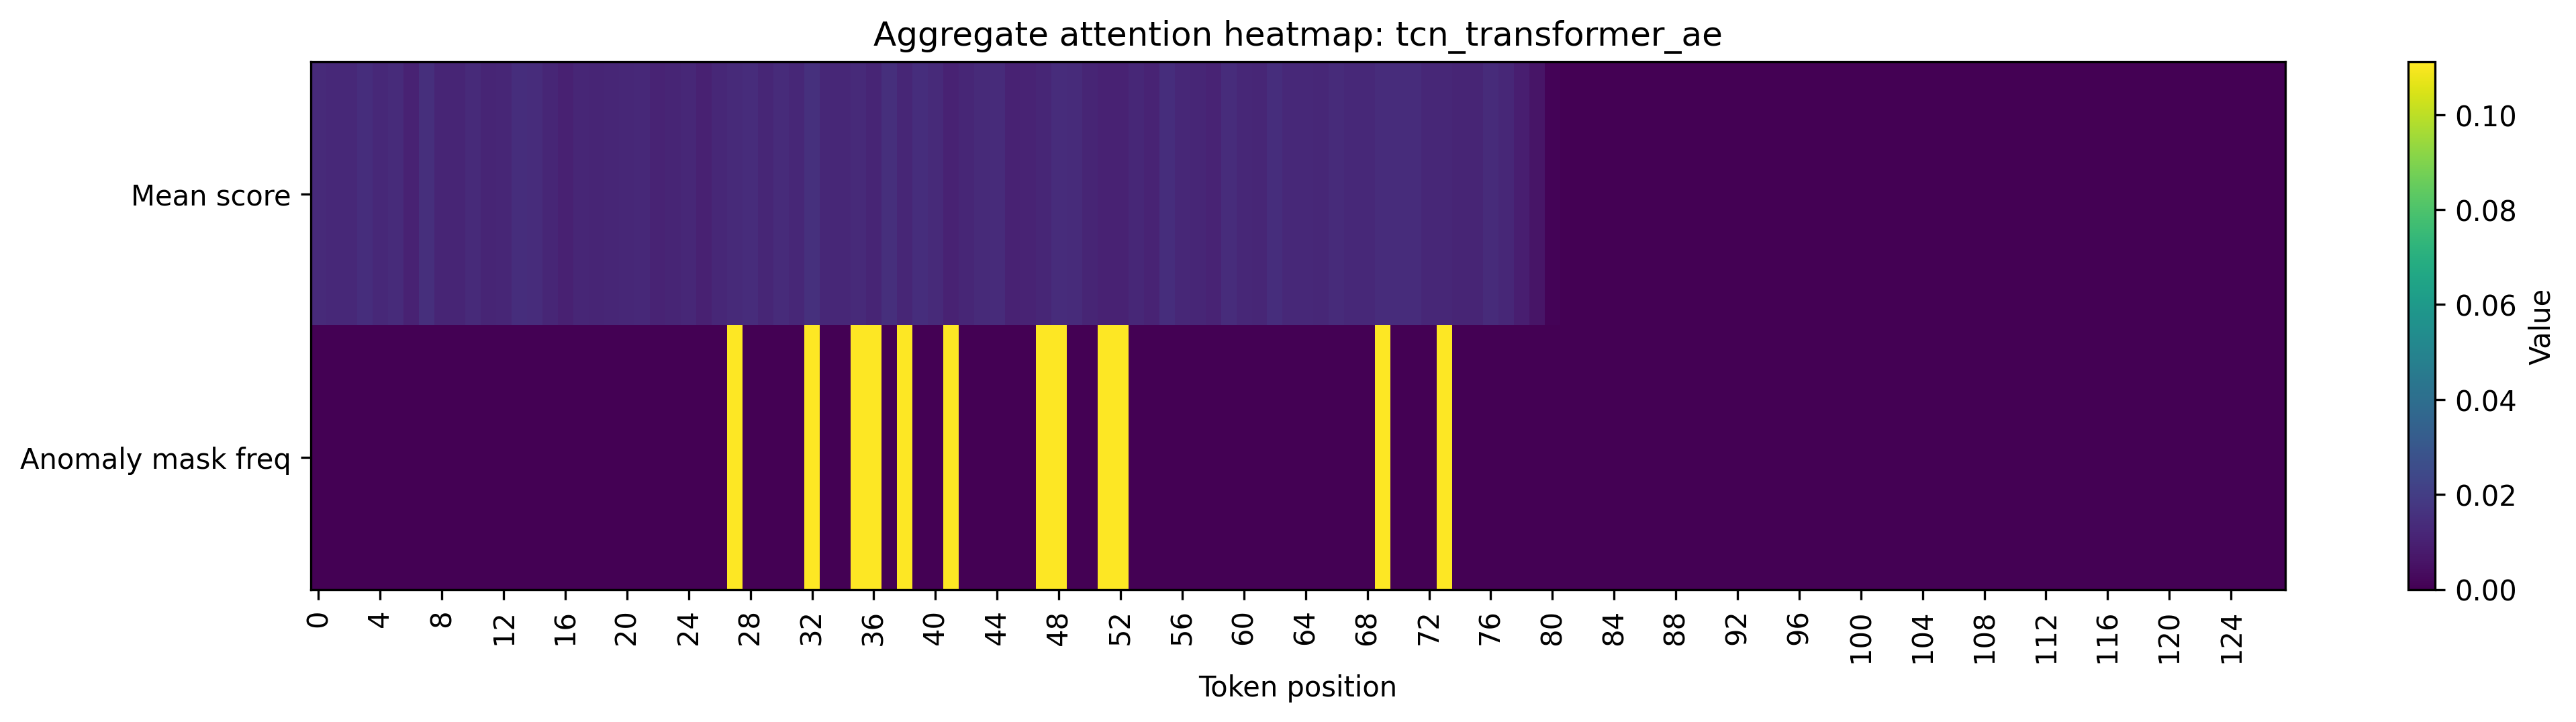

`aggregate_heatmap_tcn_transformer_ae_ensemble_attention.png`

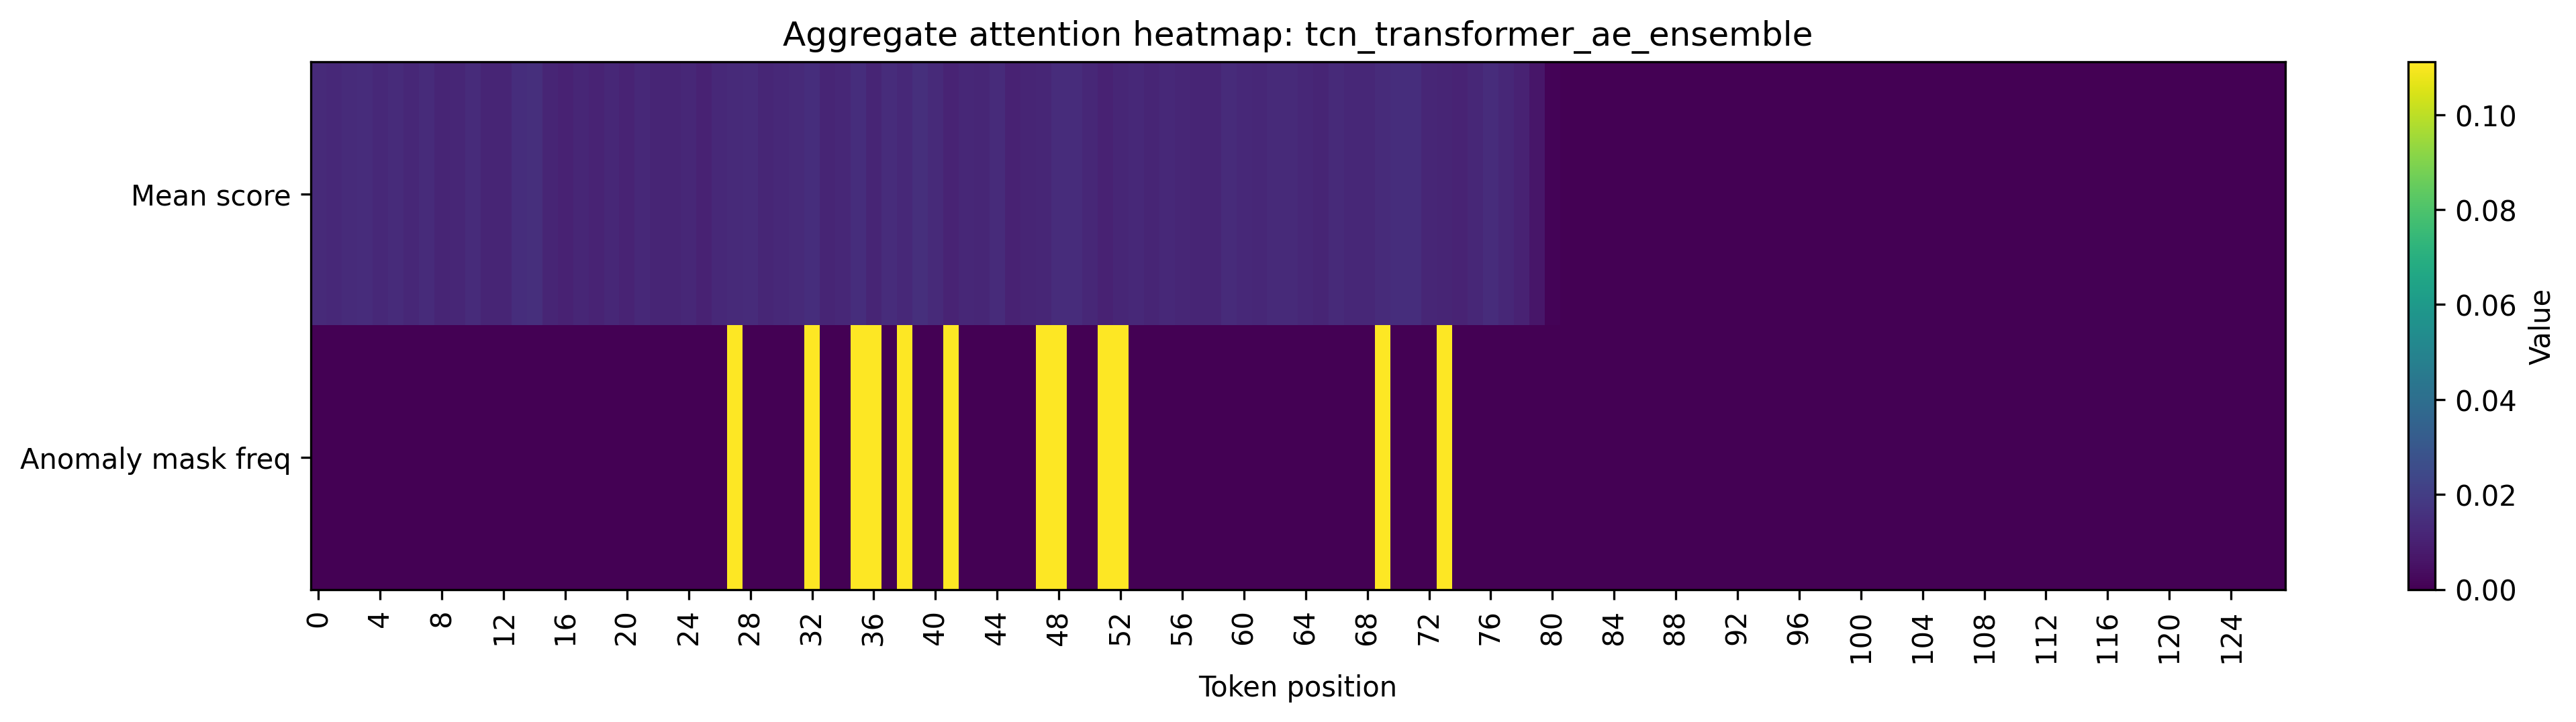

`aggregate_heatmap_tcn_transformer_ae_reconstruction.png`

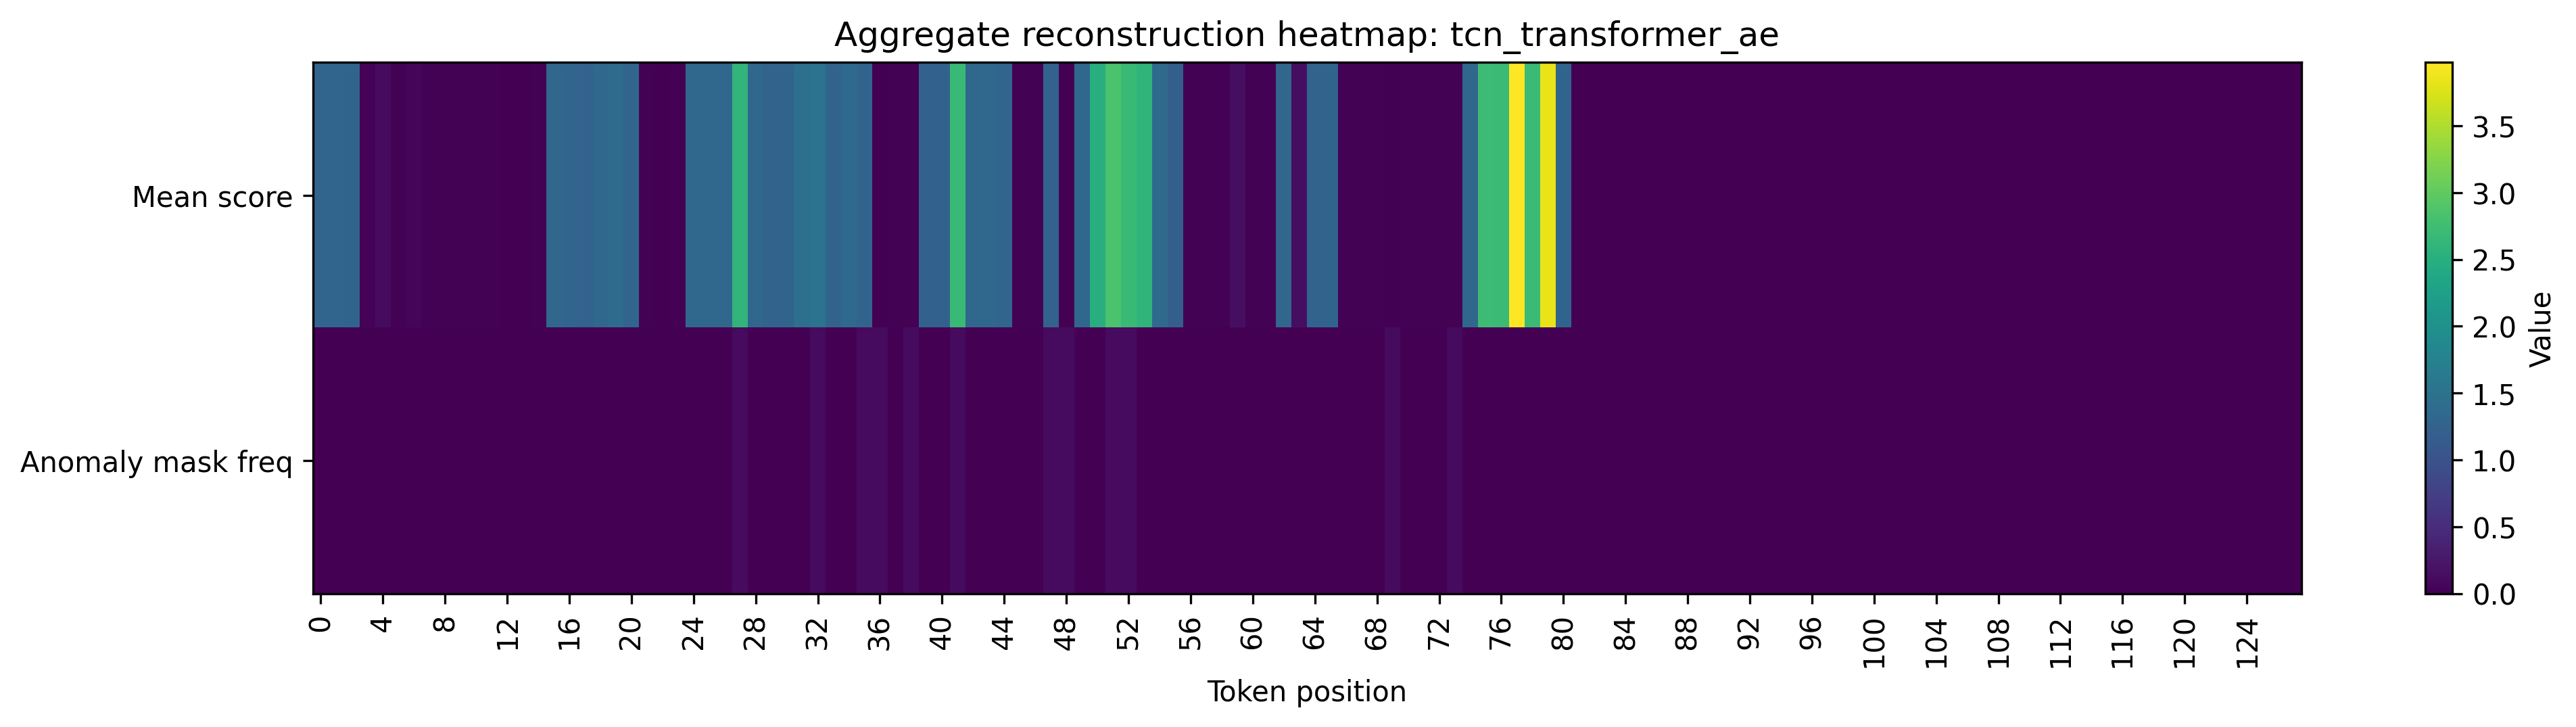

### loghub2

**Матрицы ошибок**

`confusion_matrix_tcn_ae_combined.png`

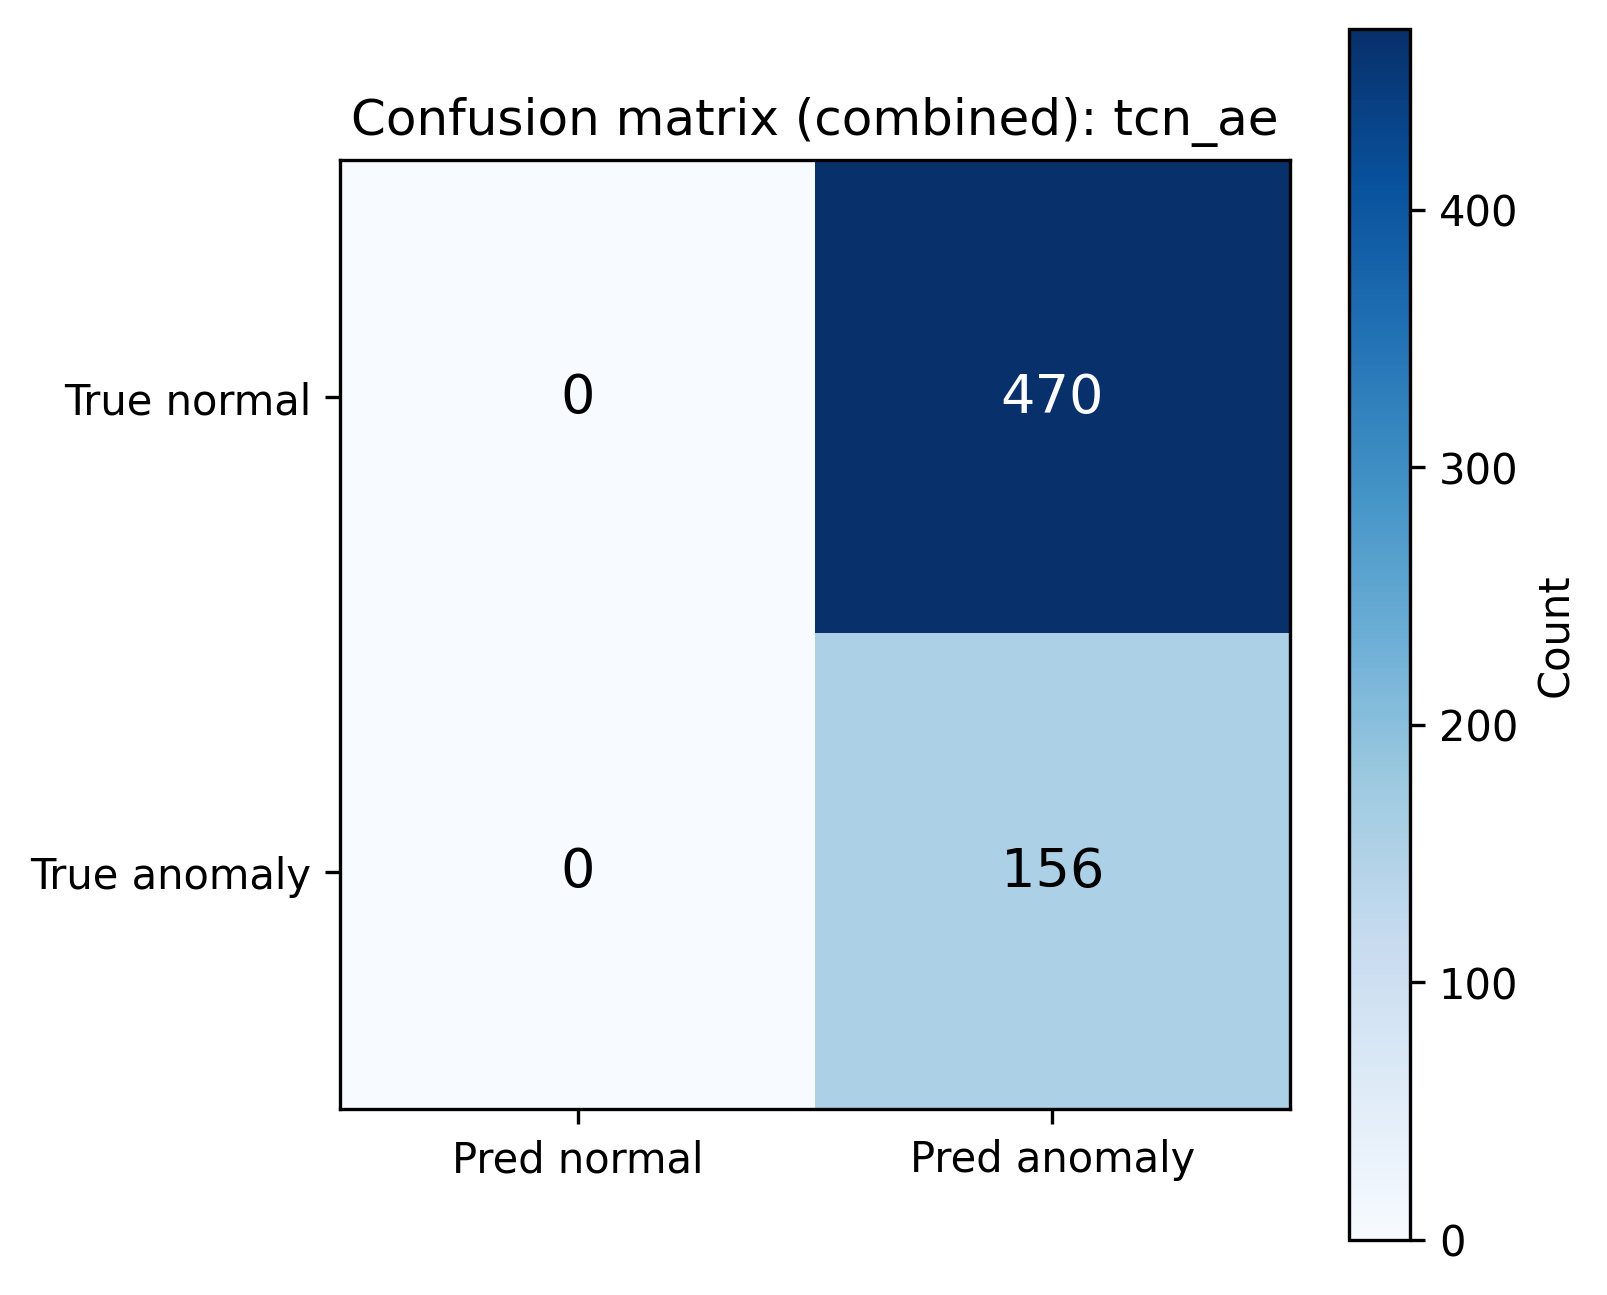

`confusion_matrix_tcn_ae_real.png`

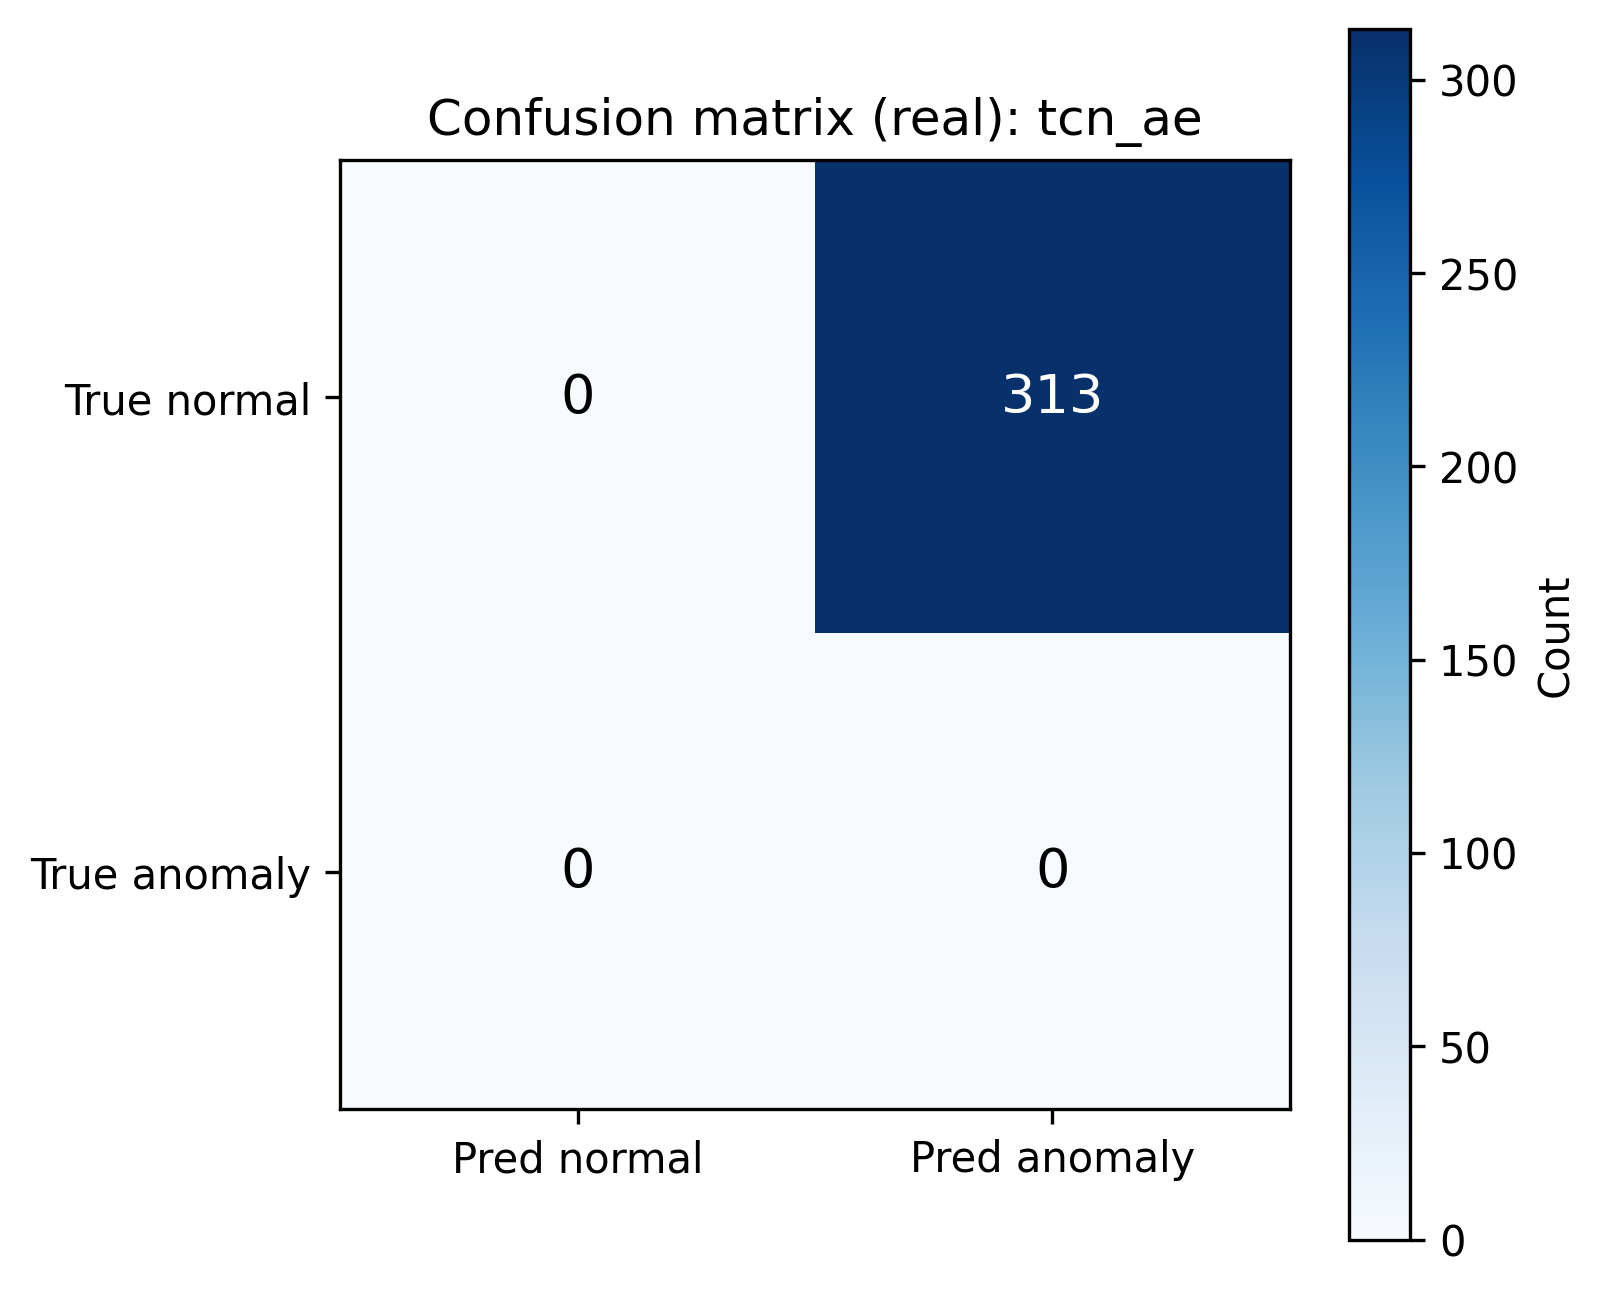

`confusion_matrix_tcn_ae_synthetic.png`

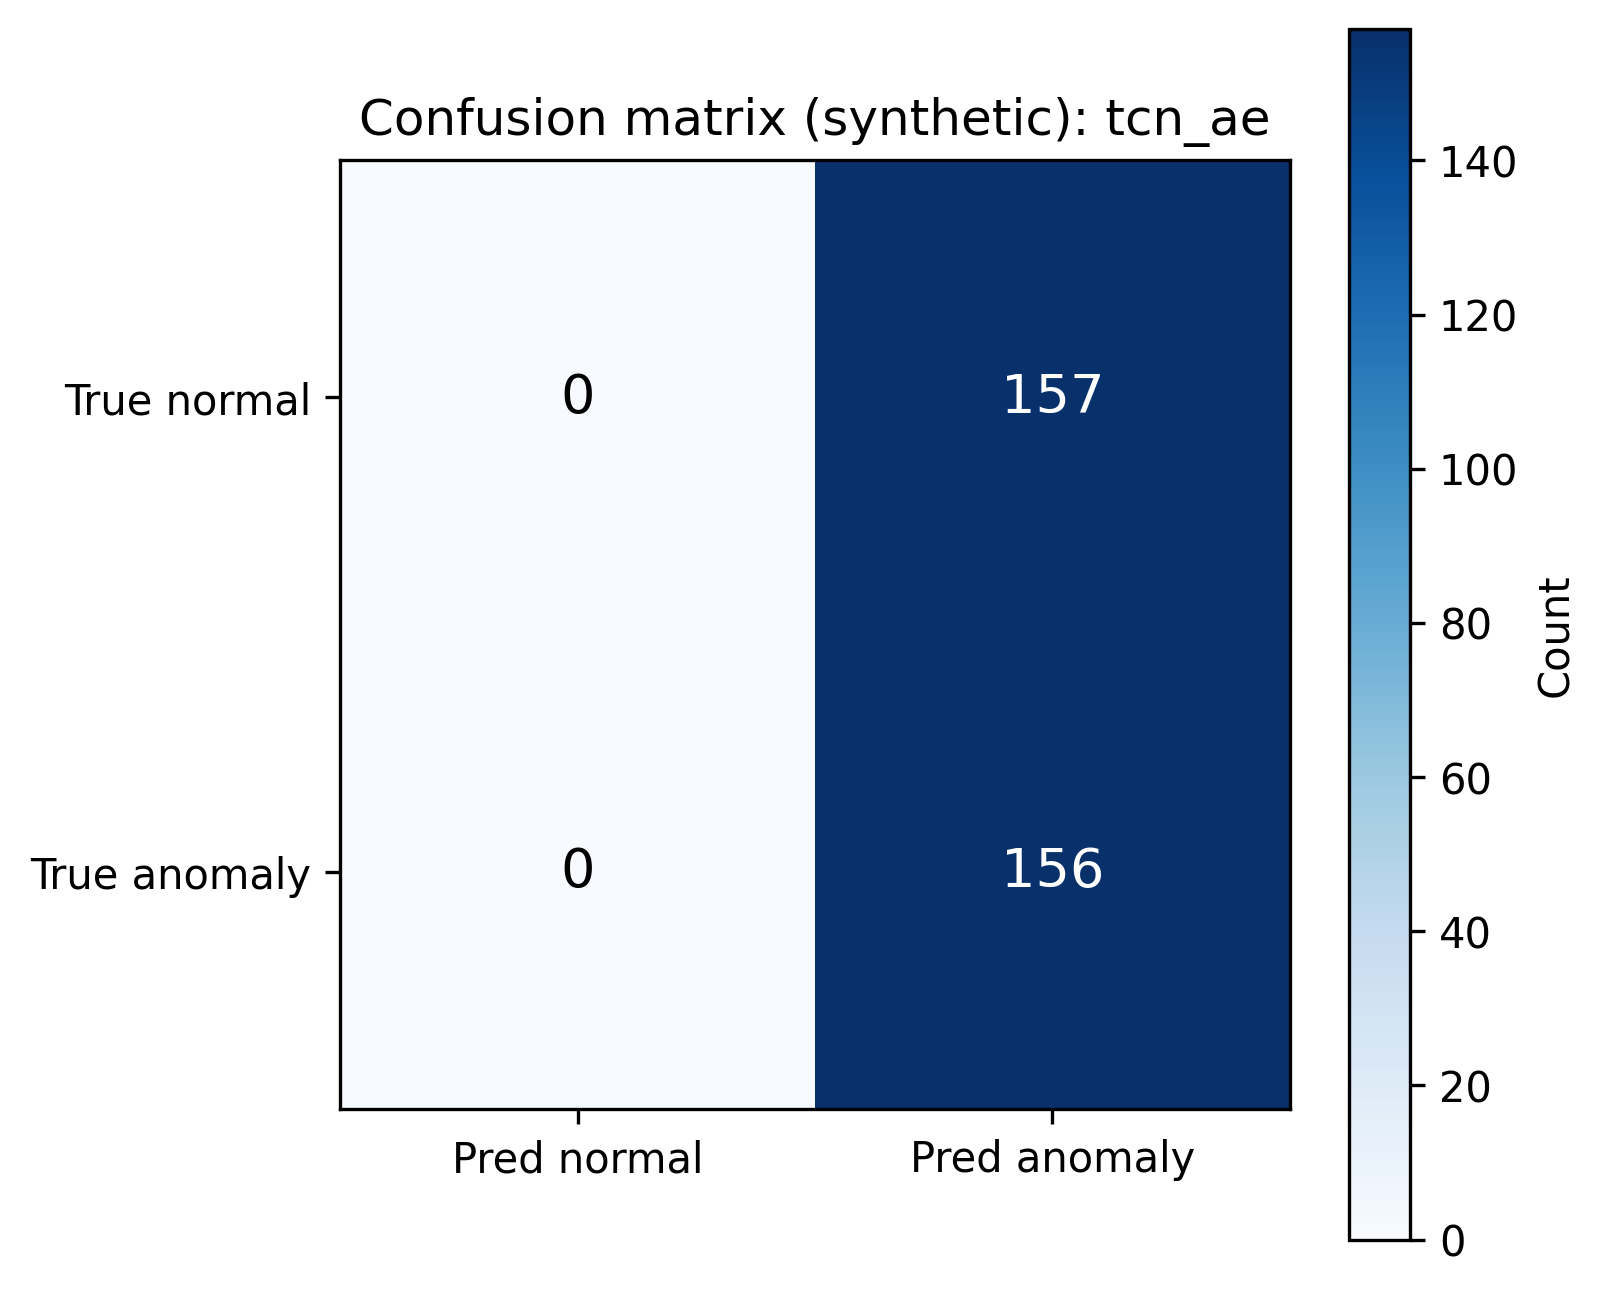

`confusion_matrix_tcn_transformer_ae_combined.png`

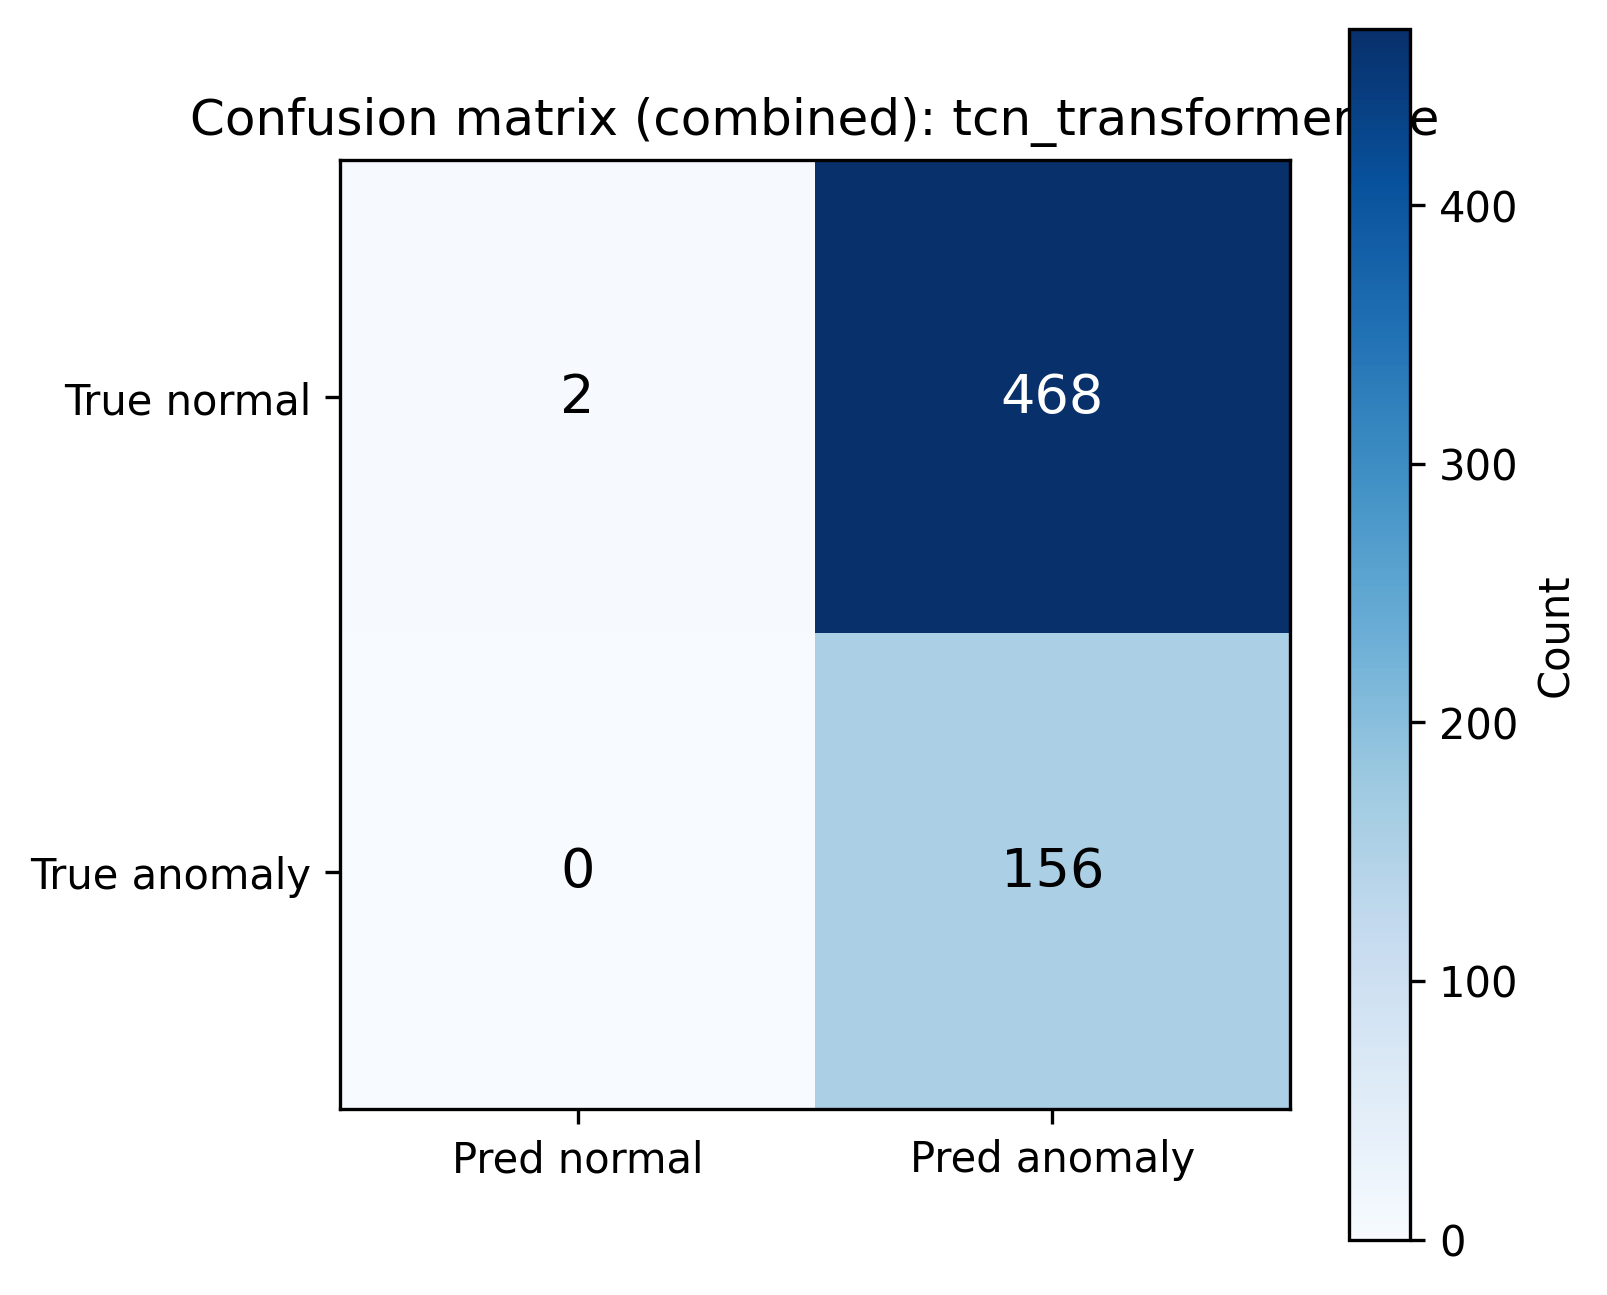

`confusion_matrix_tcn_transformer_ae_ensemble_combined.png`

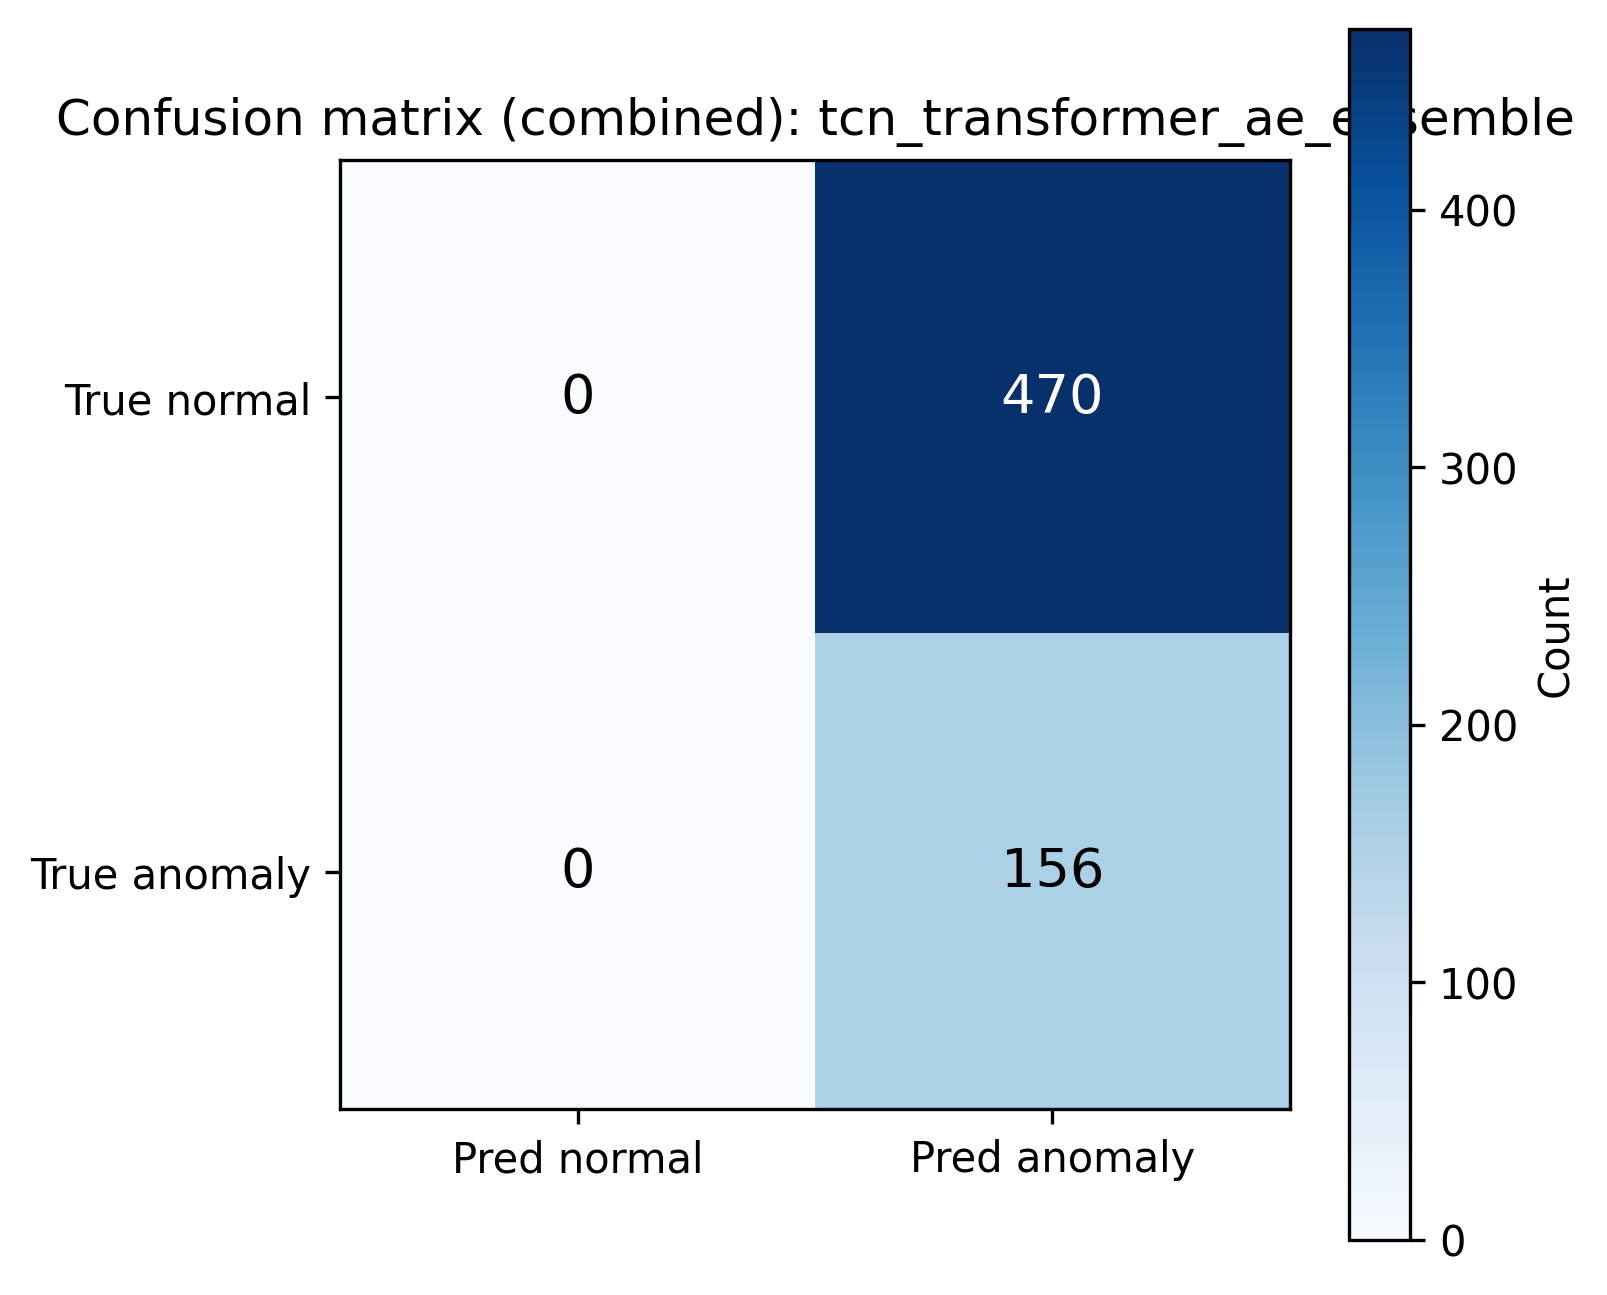

`confusion_matrix_tcn_transformer_ae_ensemble_real.png`

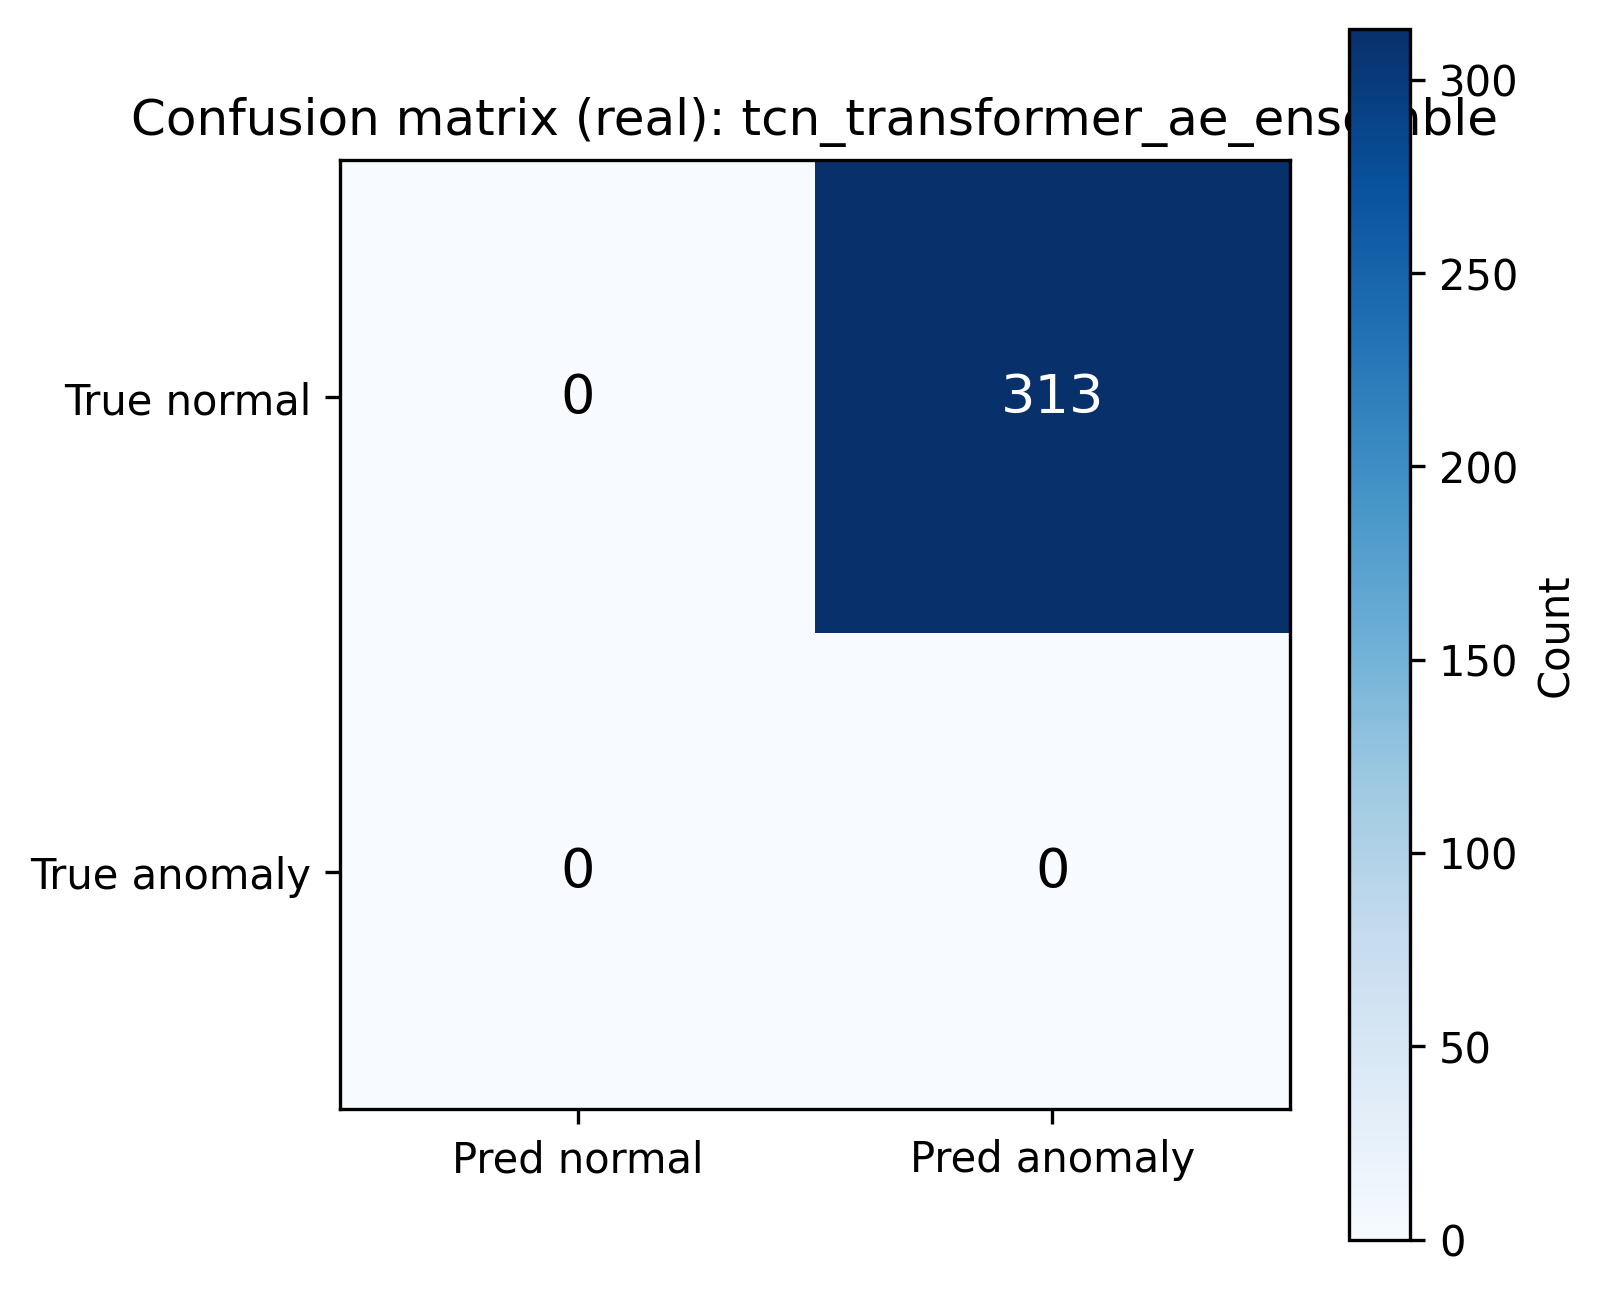

`confusion_matrix_tcn_transformer_ae_ensemble_synthetic.png`

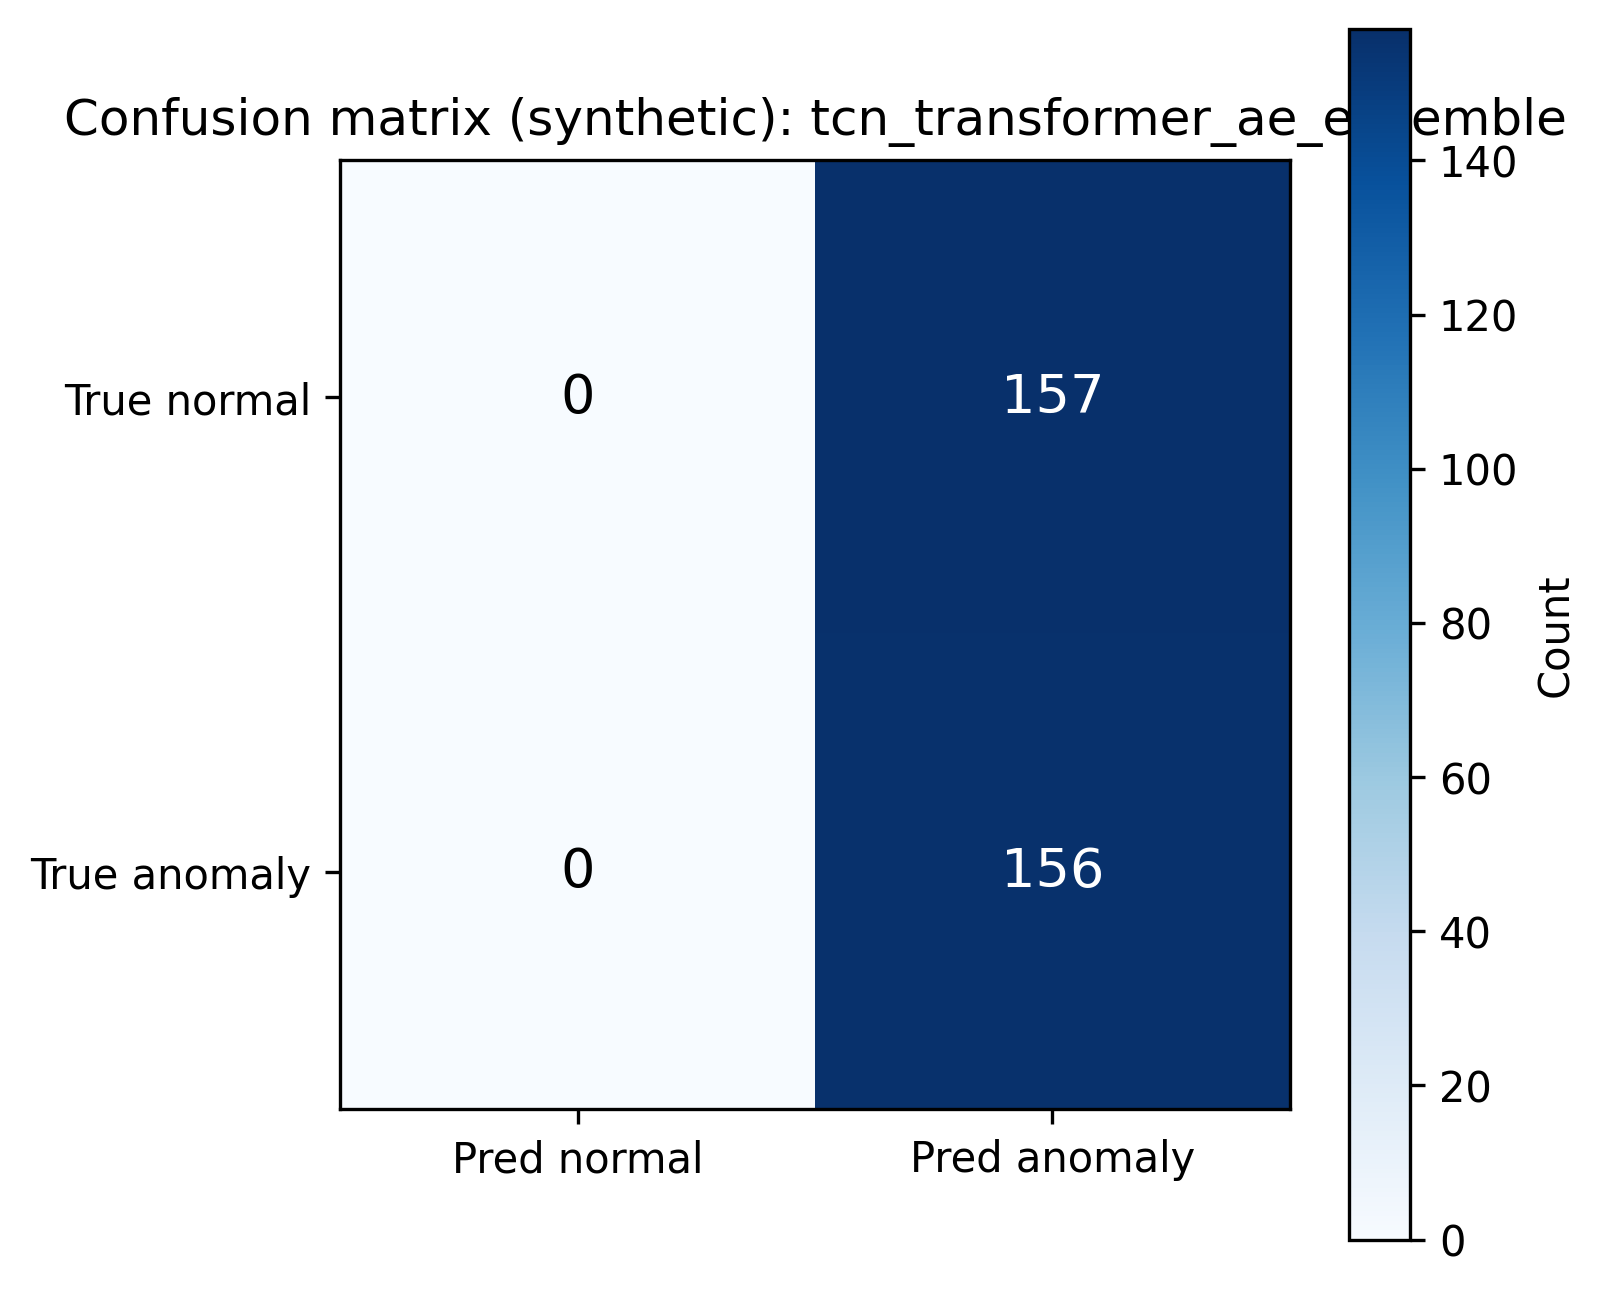

`confusion_matrix_tcn_transformer_ae_real.png`

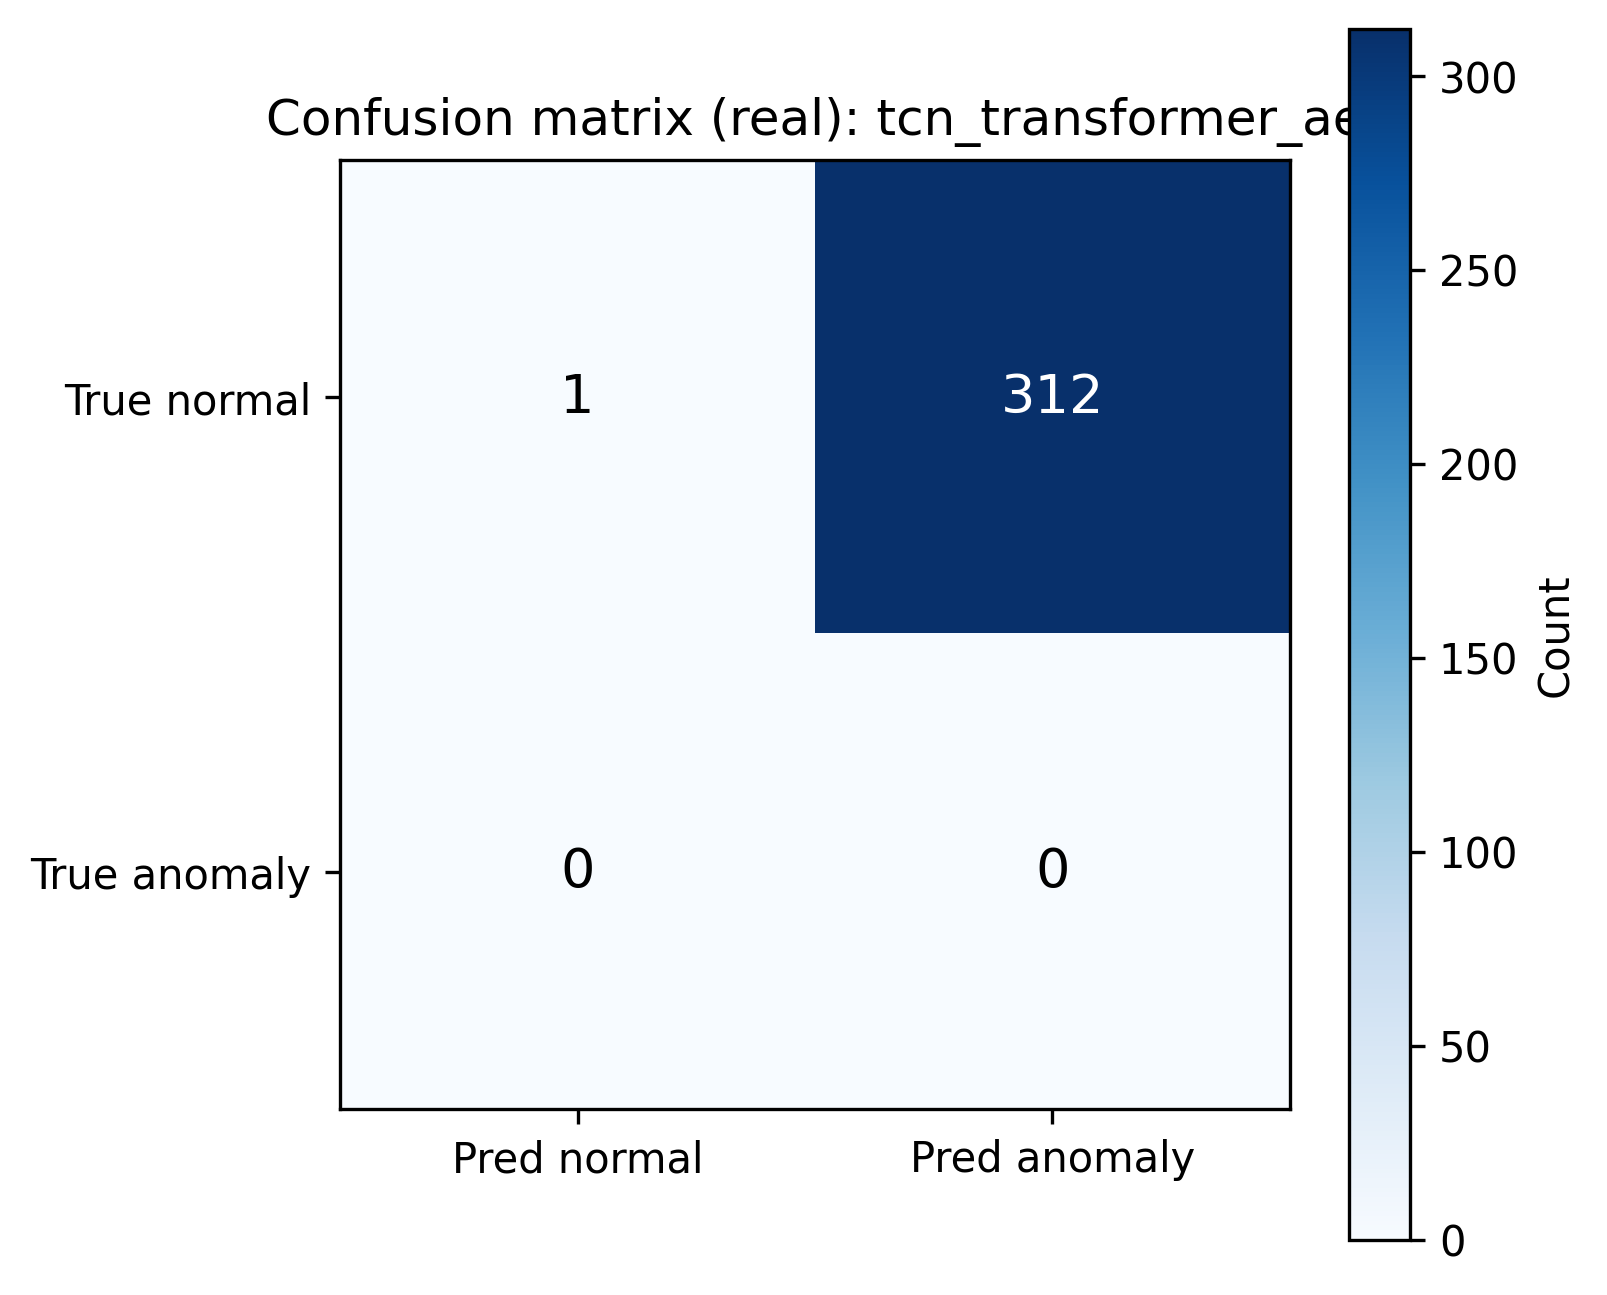

`confusion_matrix_tcn_transformer_ae_synthetic.png`

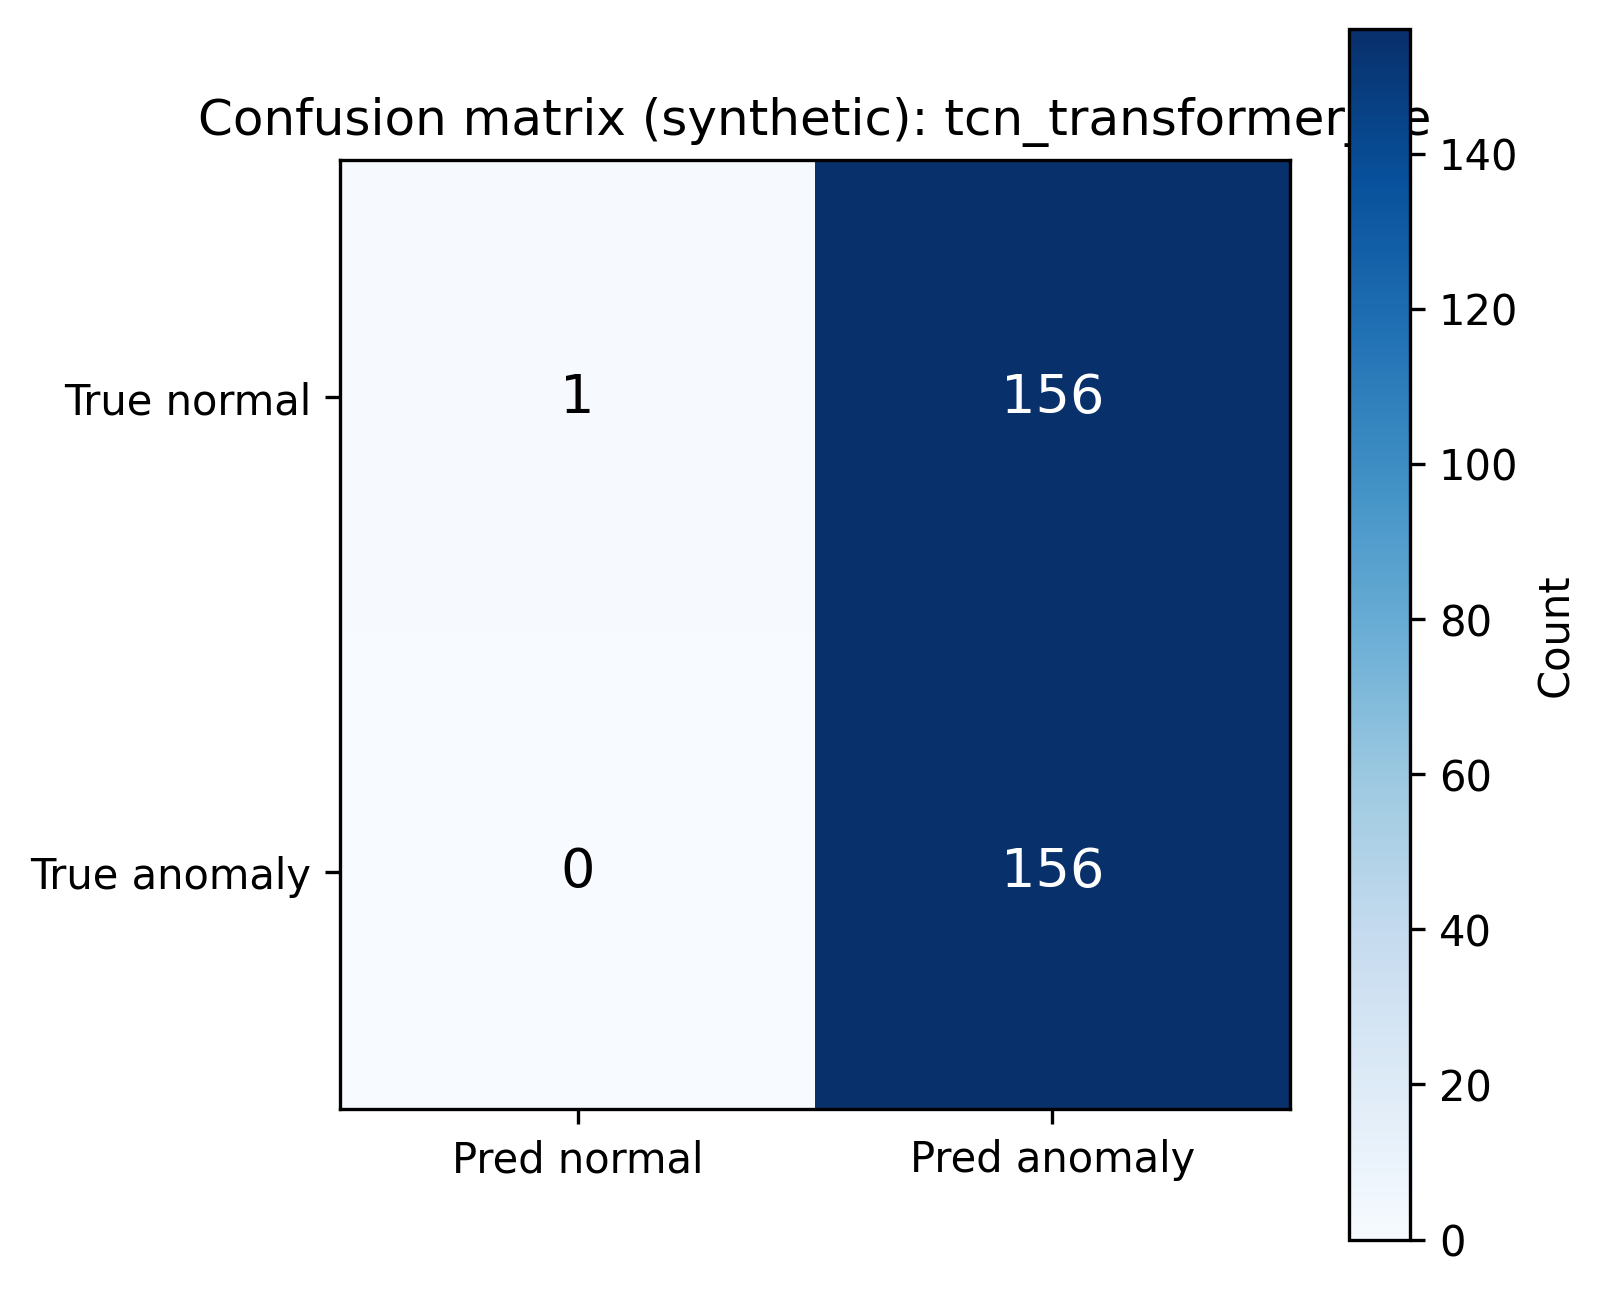

**Общие heatmap**

`aggregate_heatmap_tcn_ae_reconstruction.png`

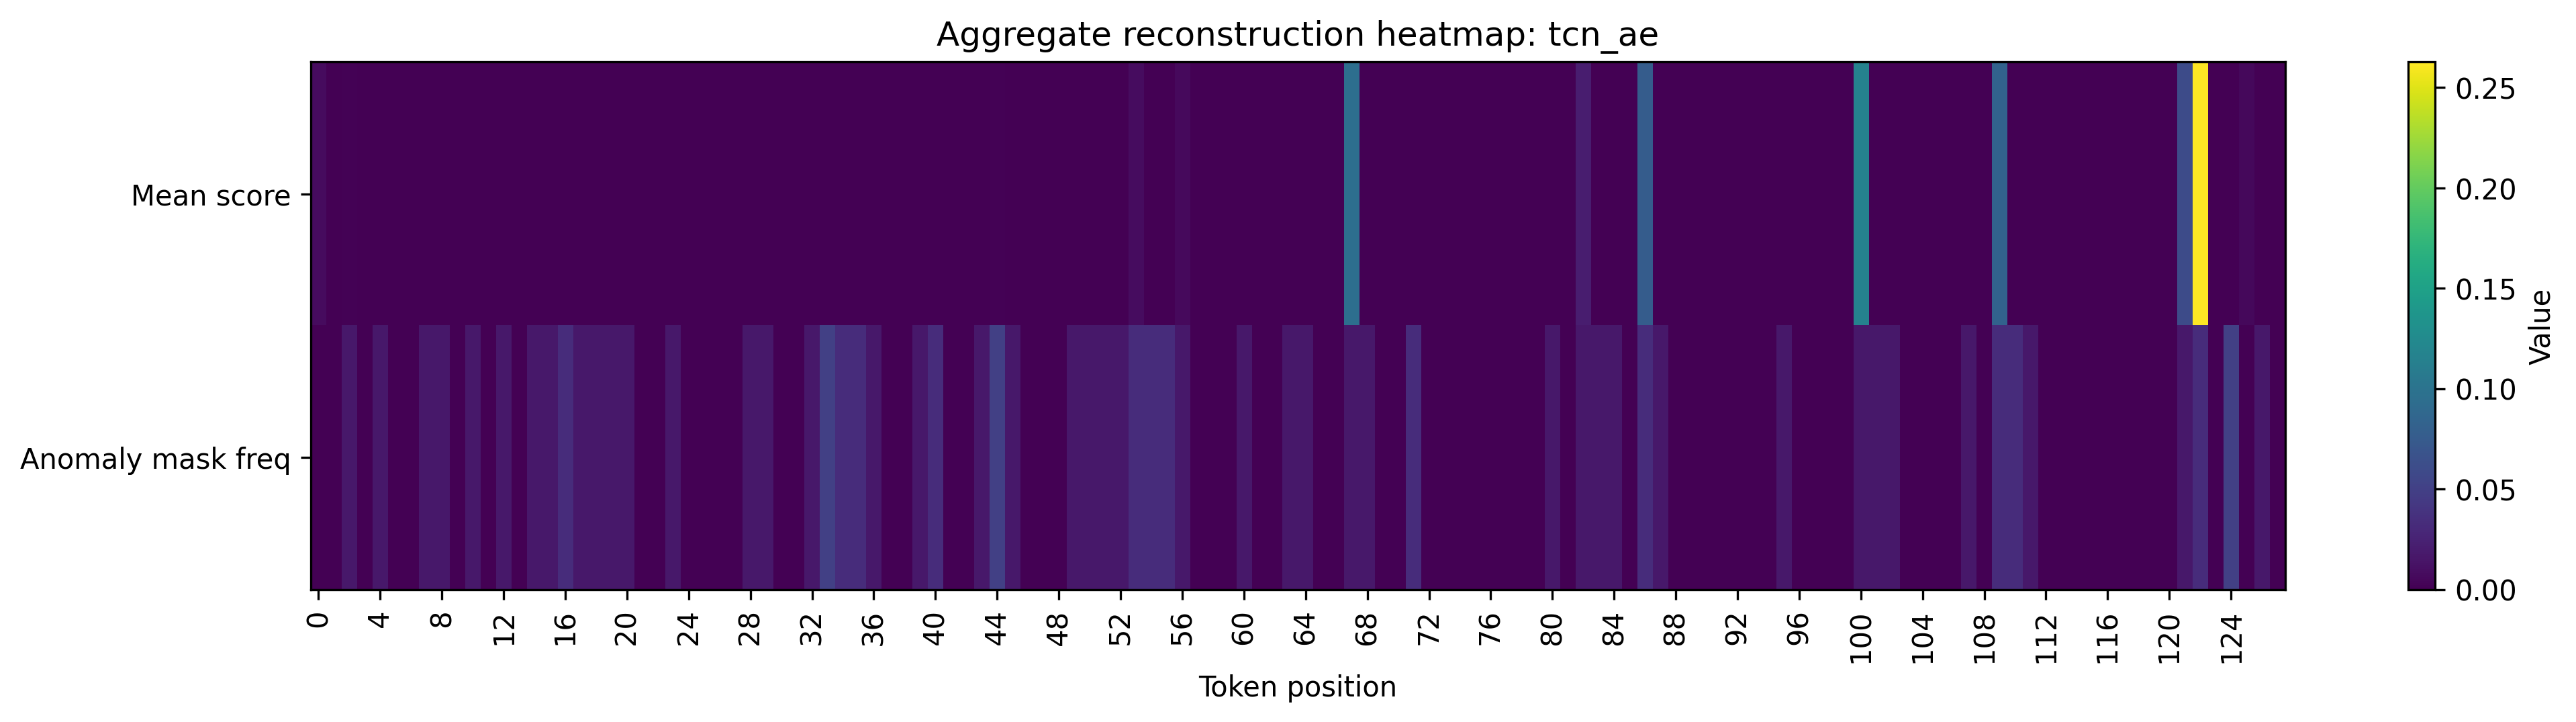

`aggregate_heatmap_tcn_transformer_ae_attention.png`

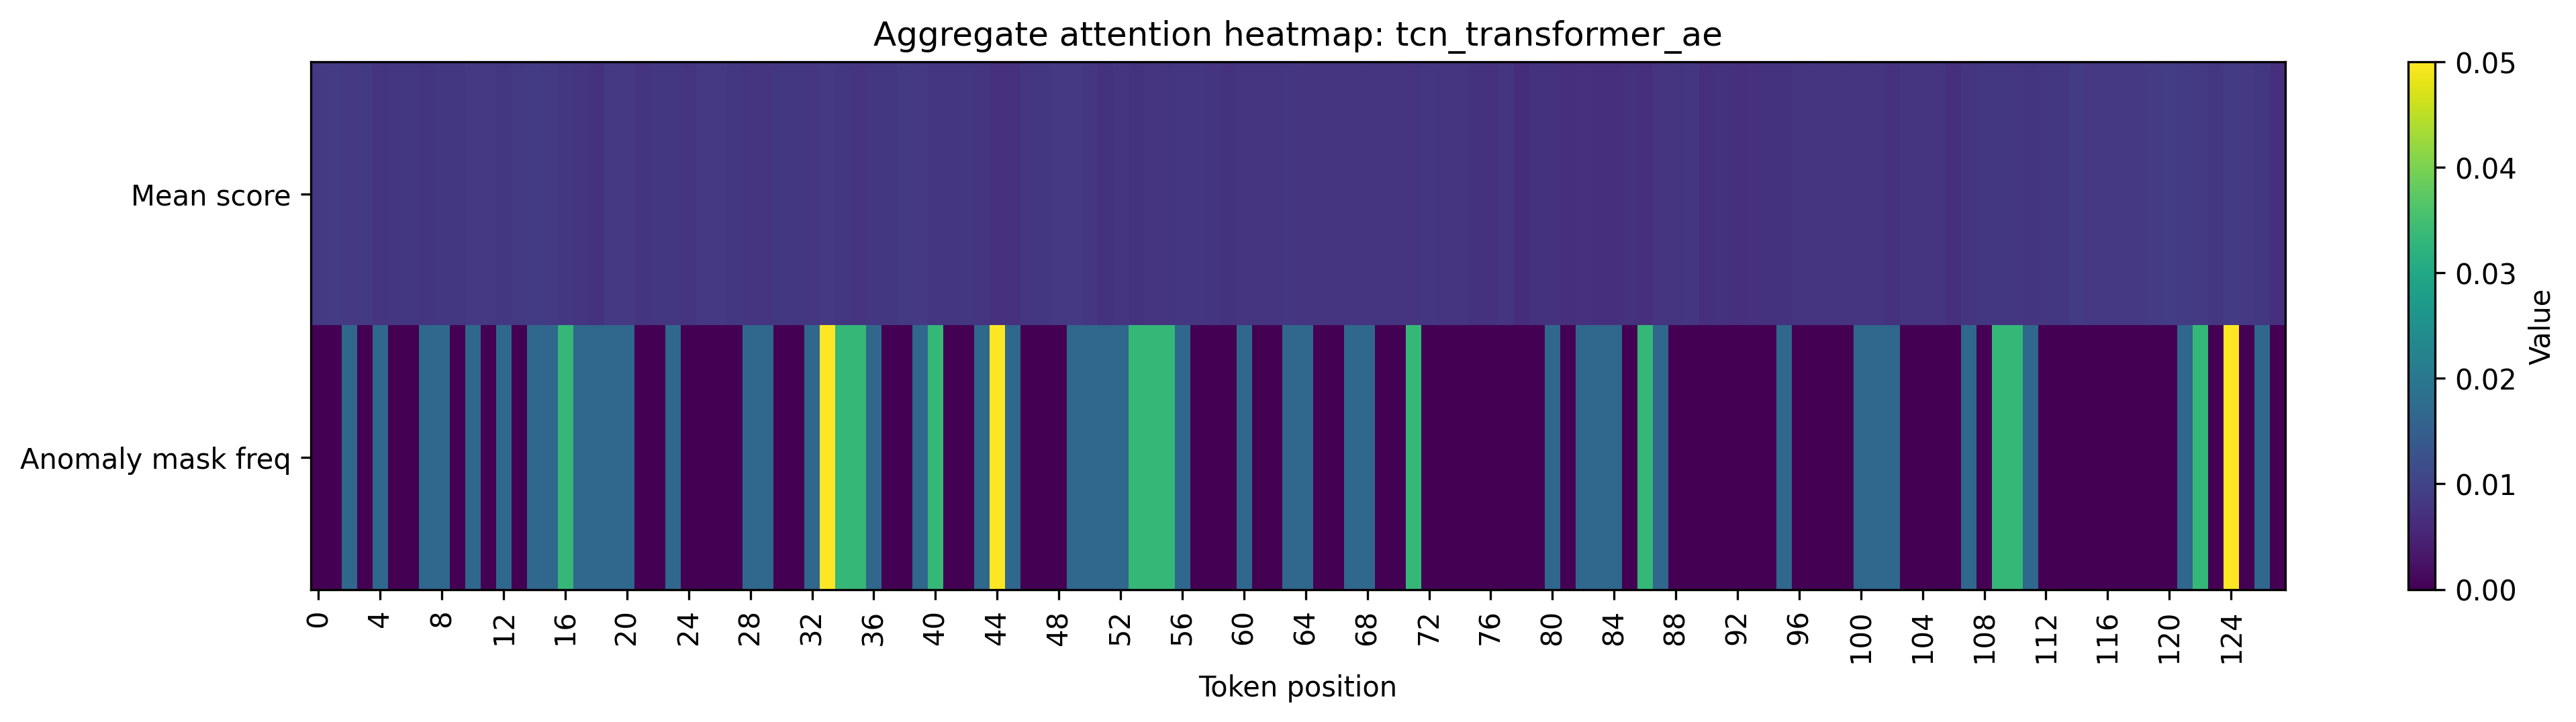

`aggregate_heatmap_tcn_transformer_ae_ensemble_attention.png`

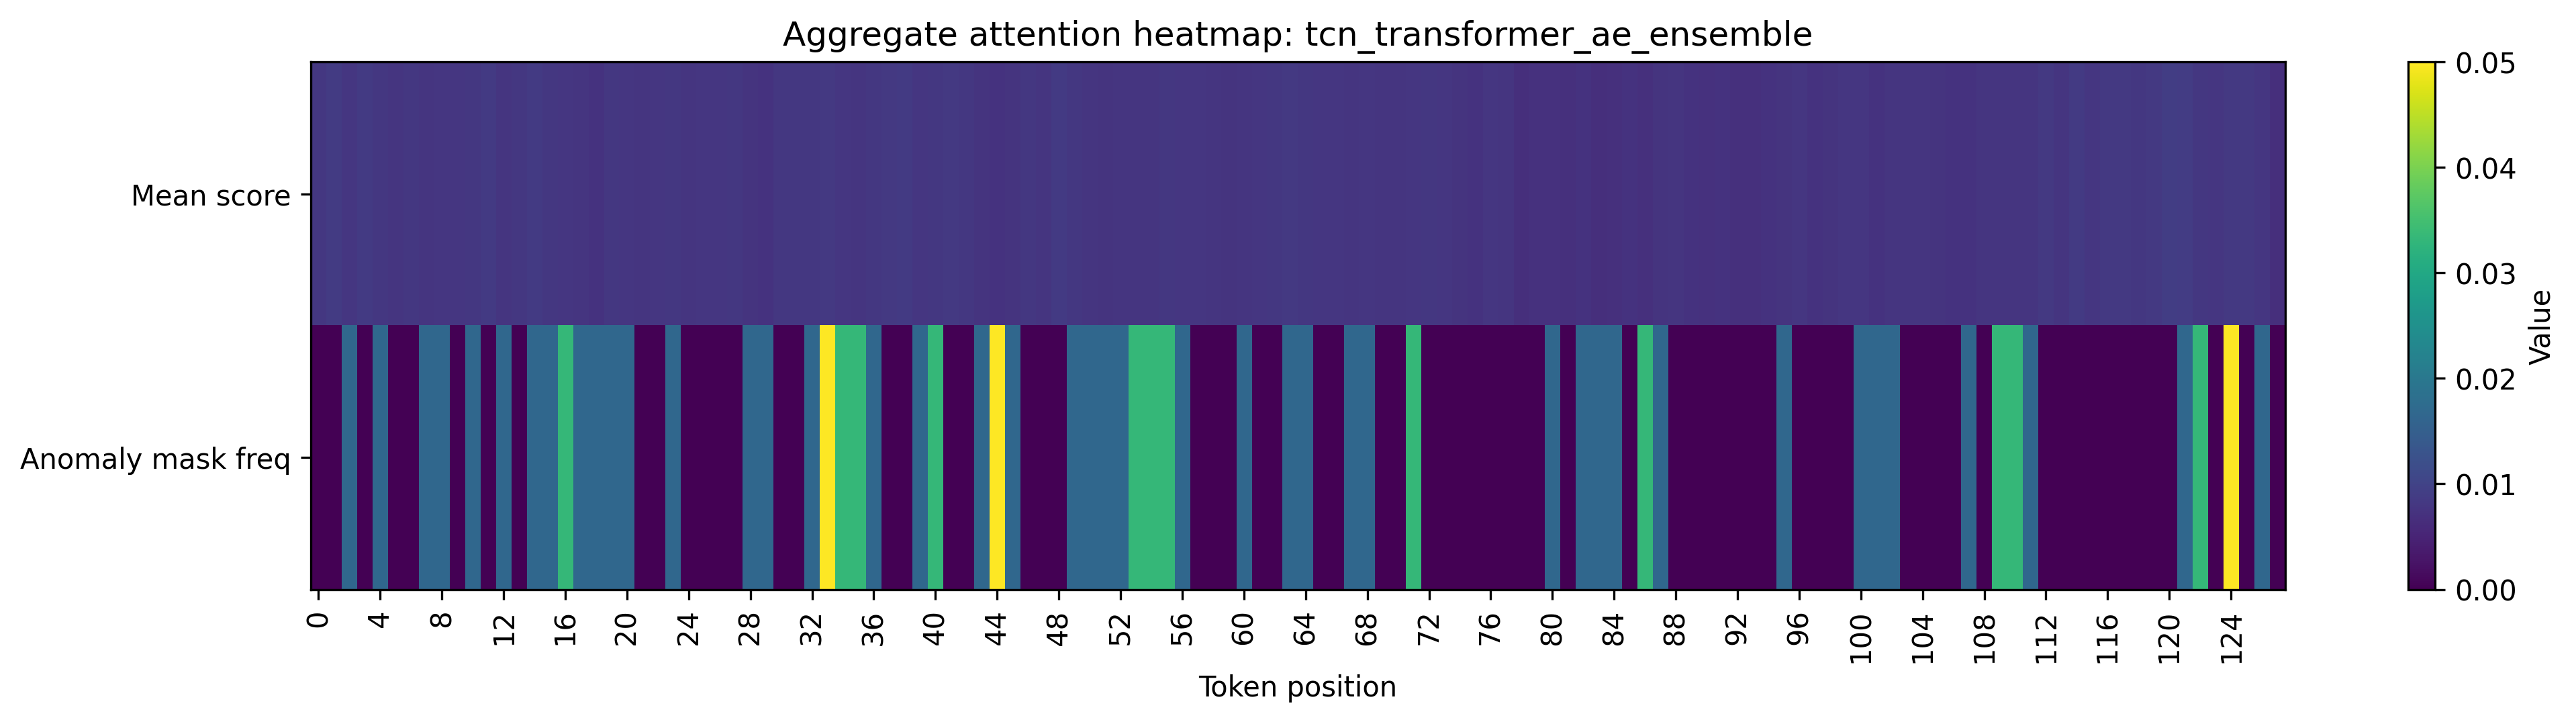

`aggregate_heatmap_tcn_transformer_ae_reconstruction.png`

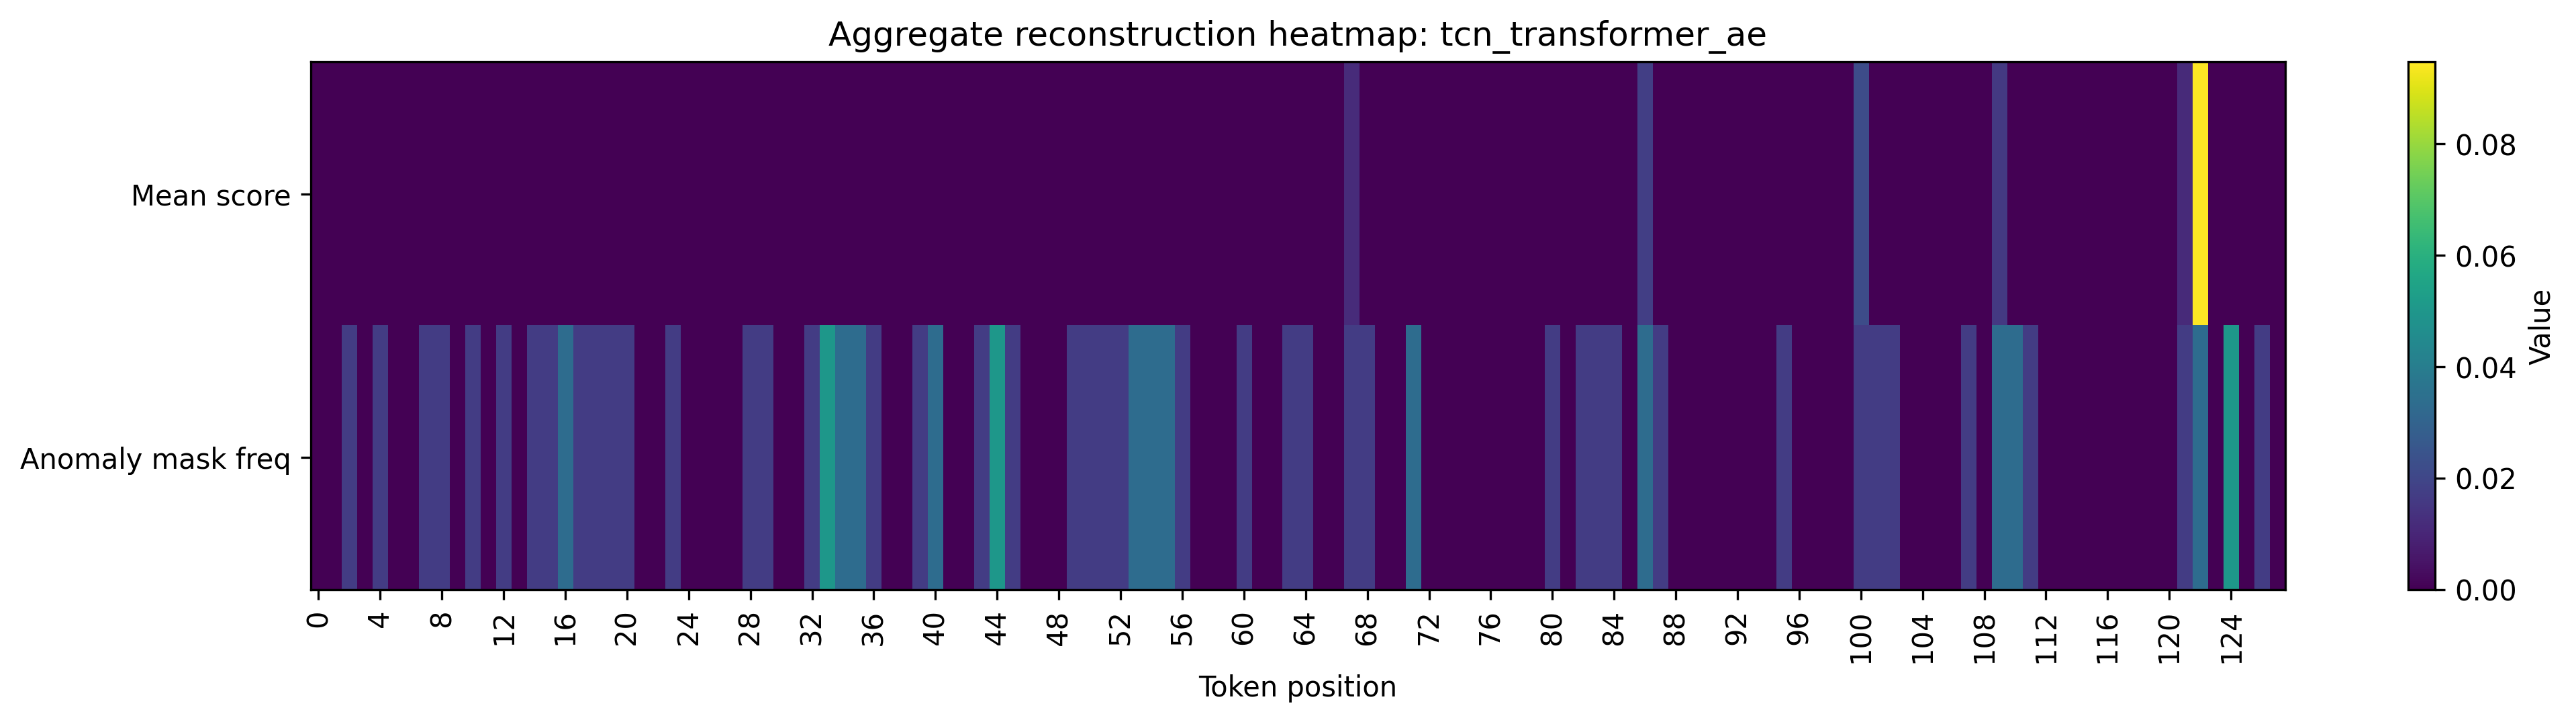

### rcaeval

**Матрицы ошибок**

`confusion_matrix_tcn_ae_combined.png`

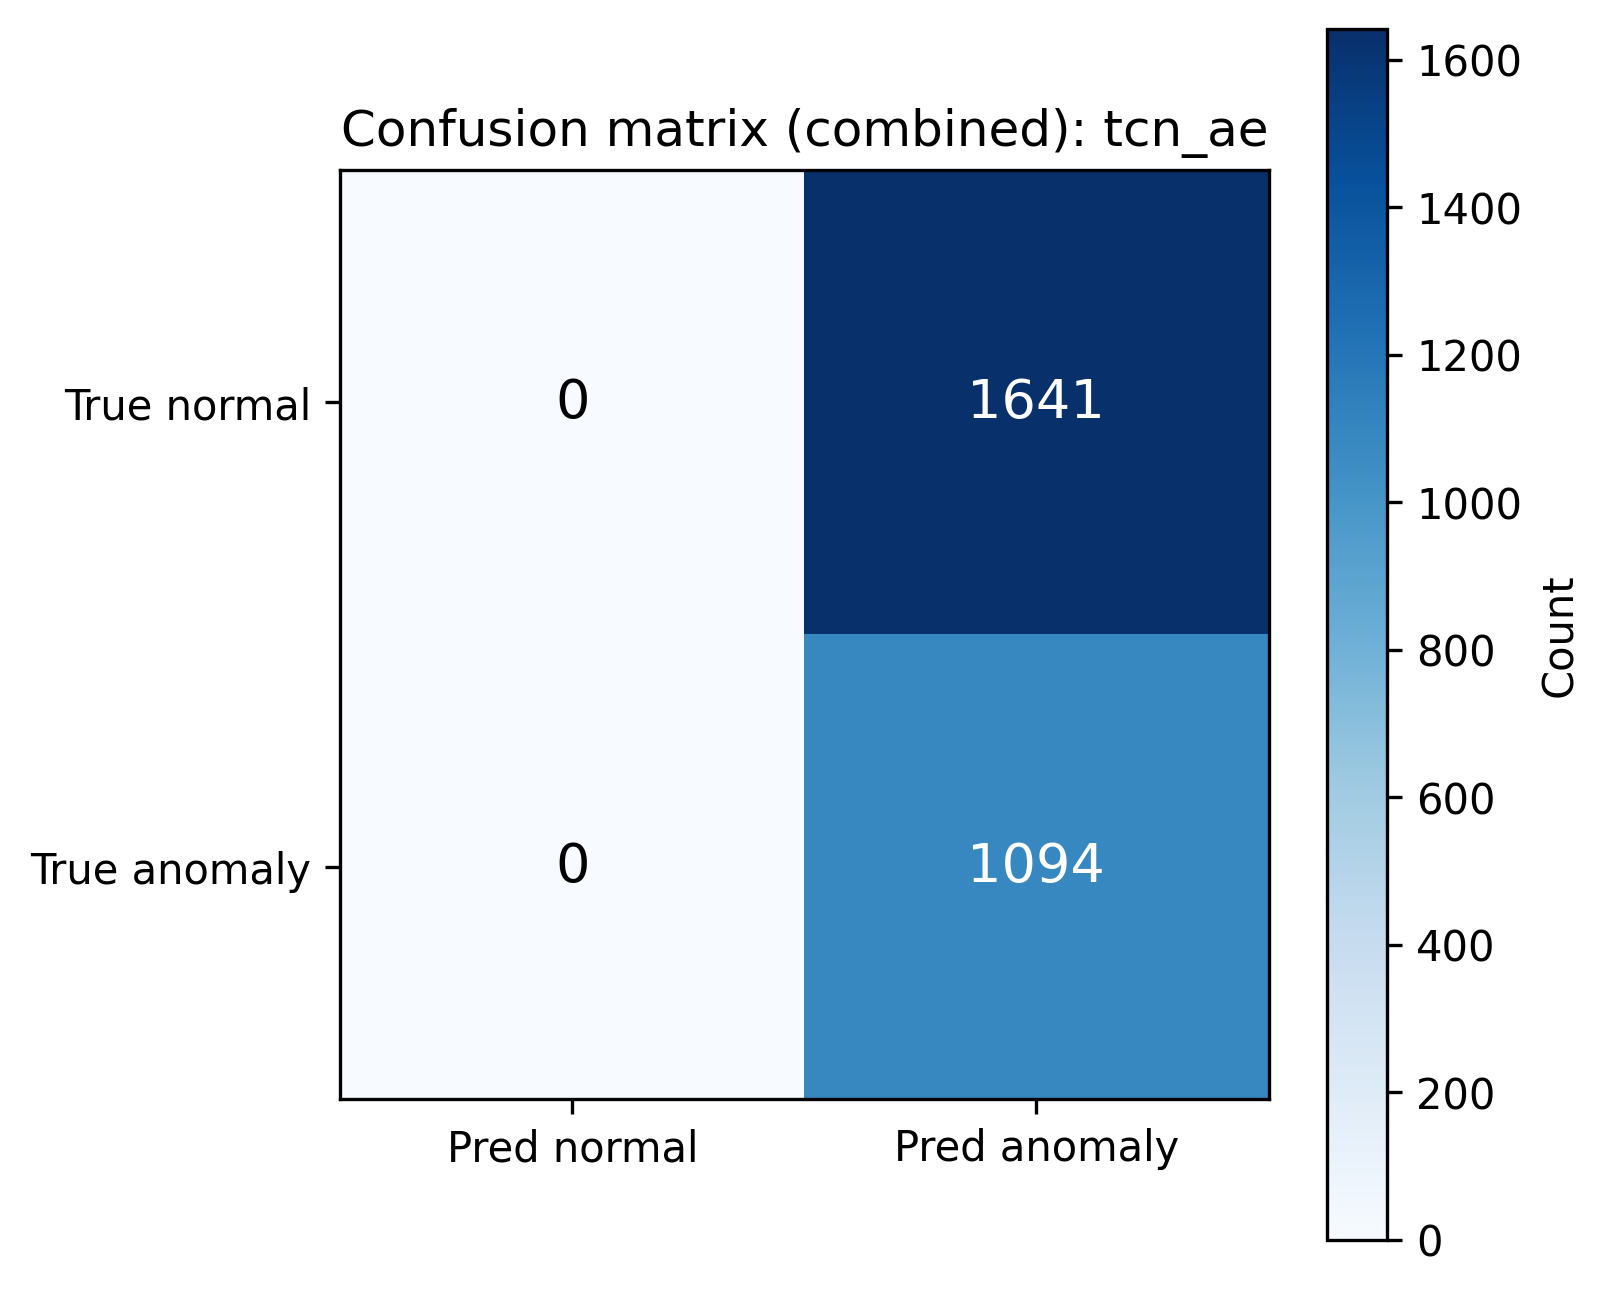

`confusion_matrix_tcn_ae_real.png`

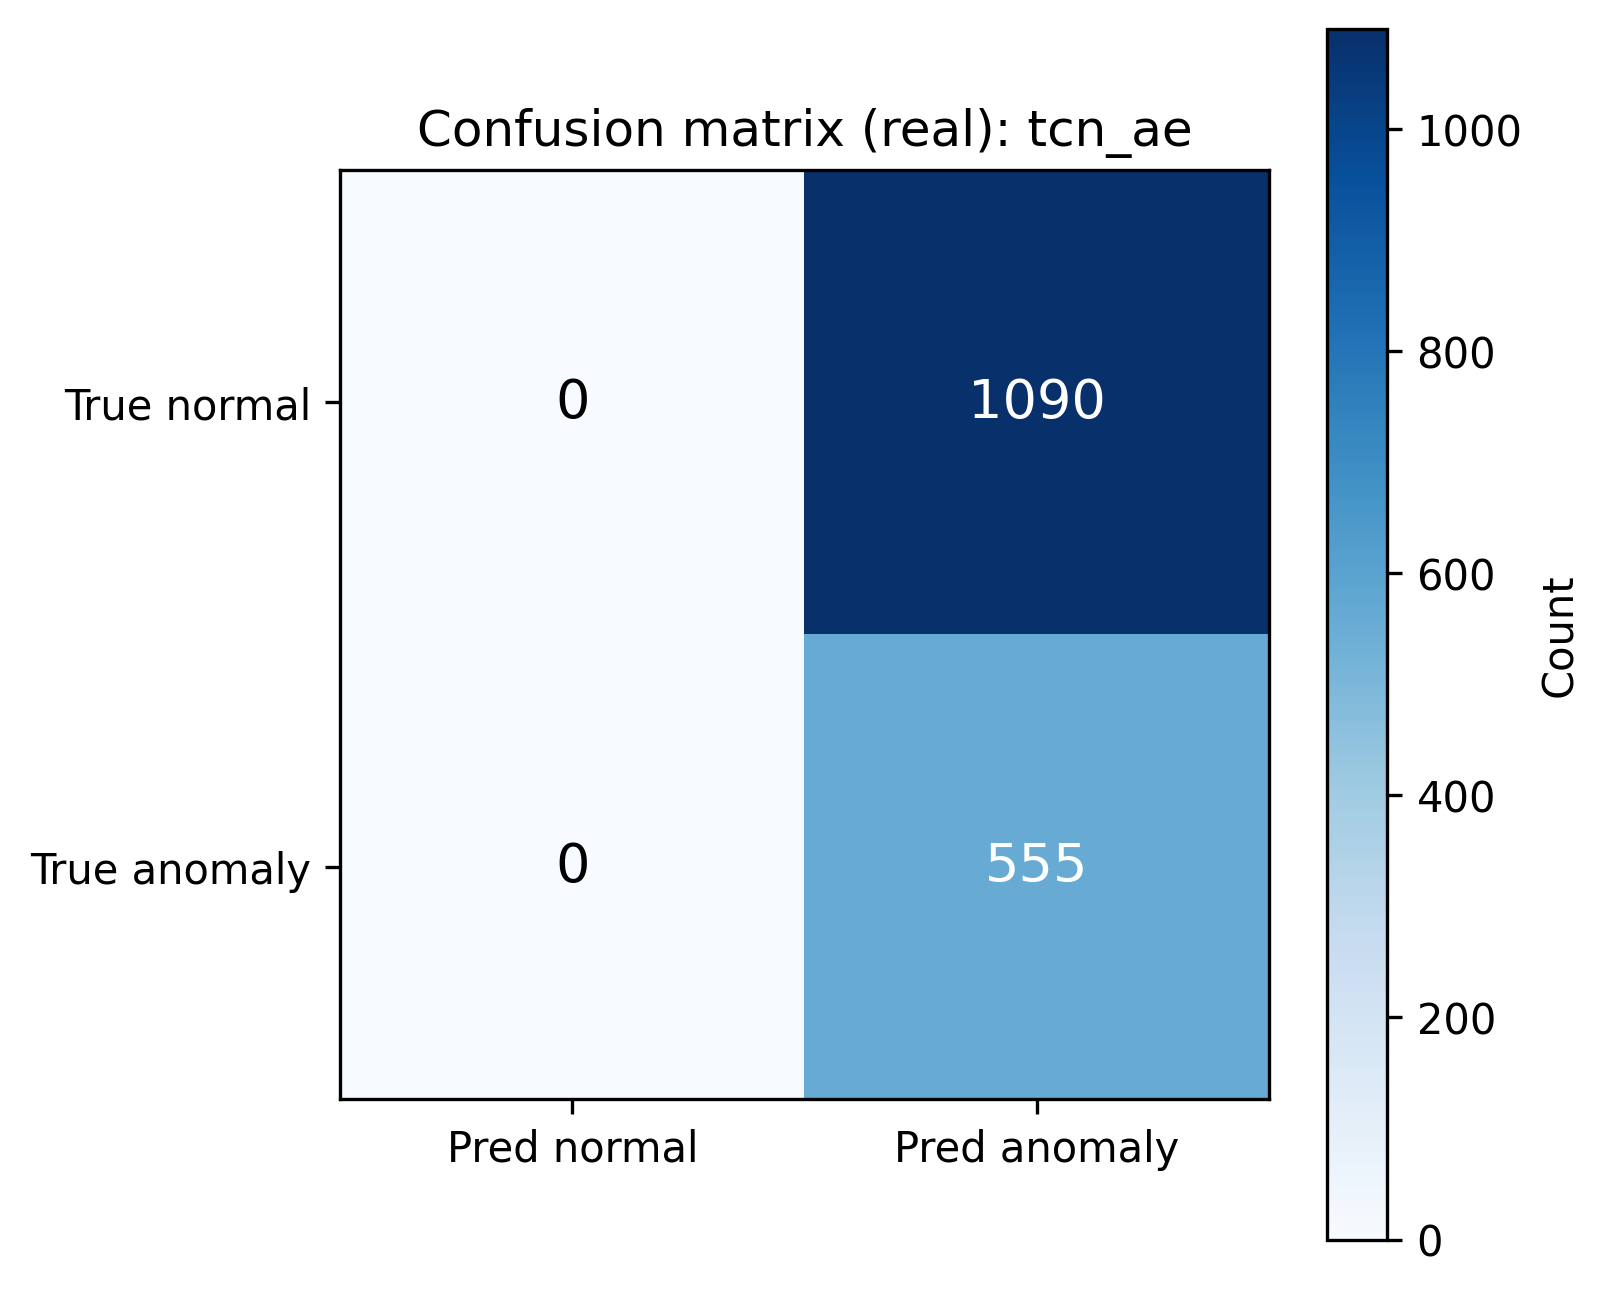

`confusion_matrix_tcn_ae_synthetic.png`

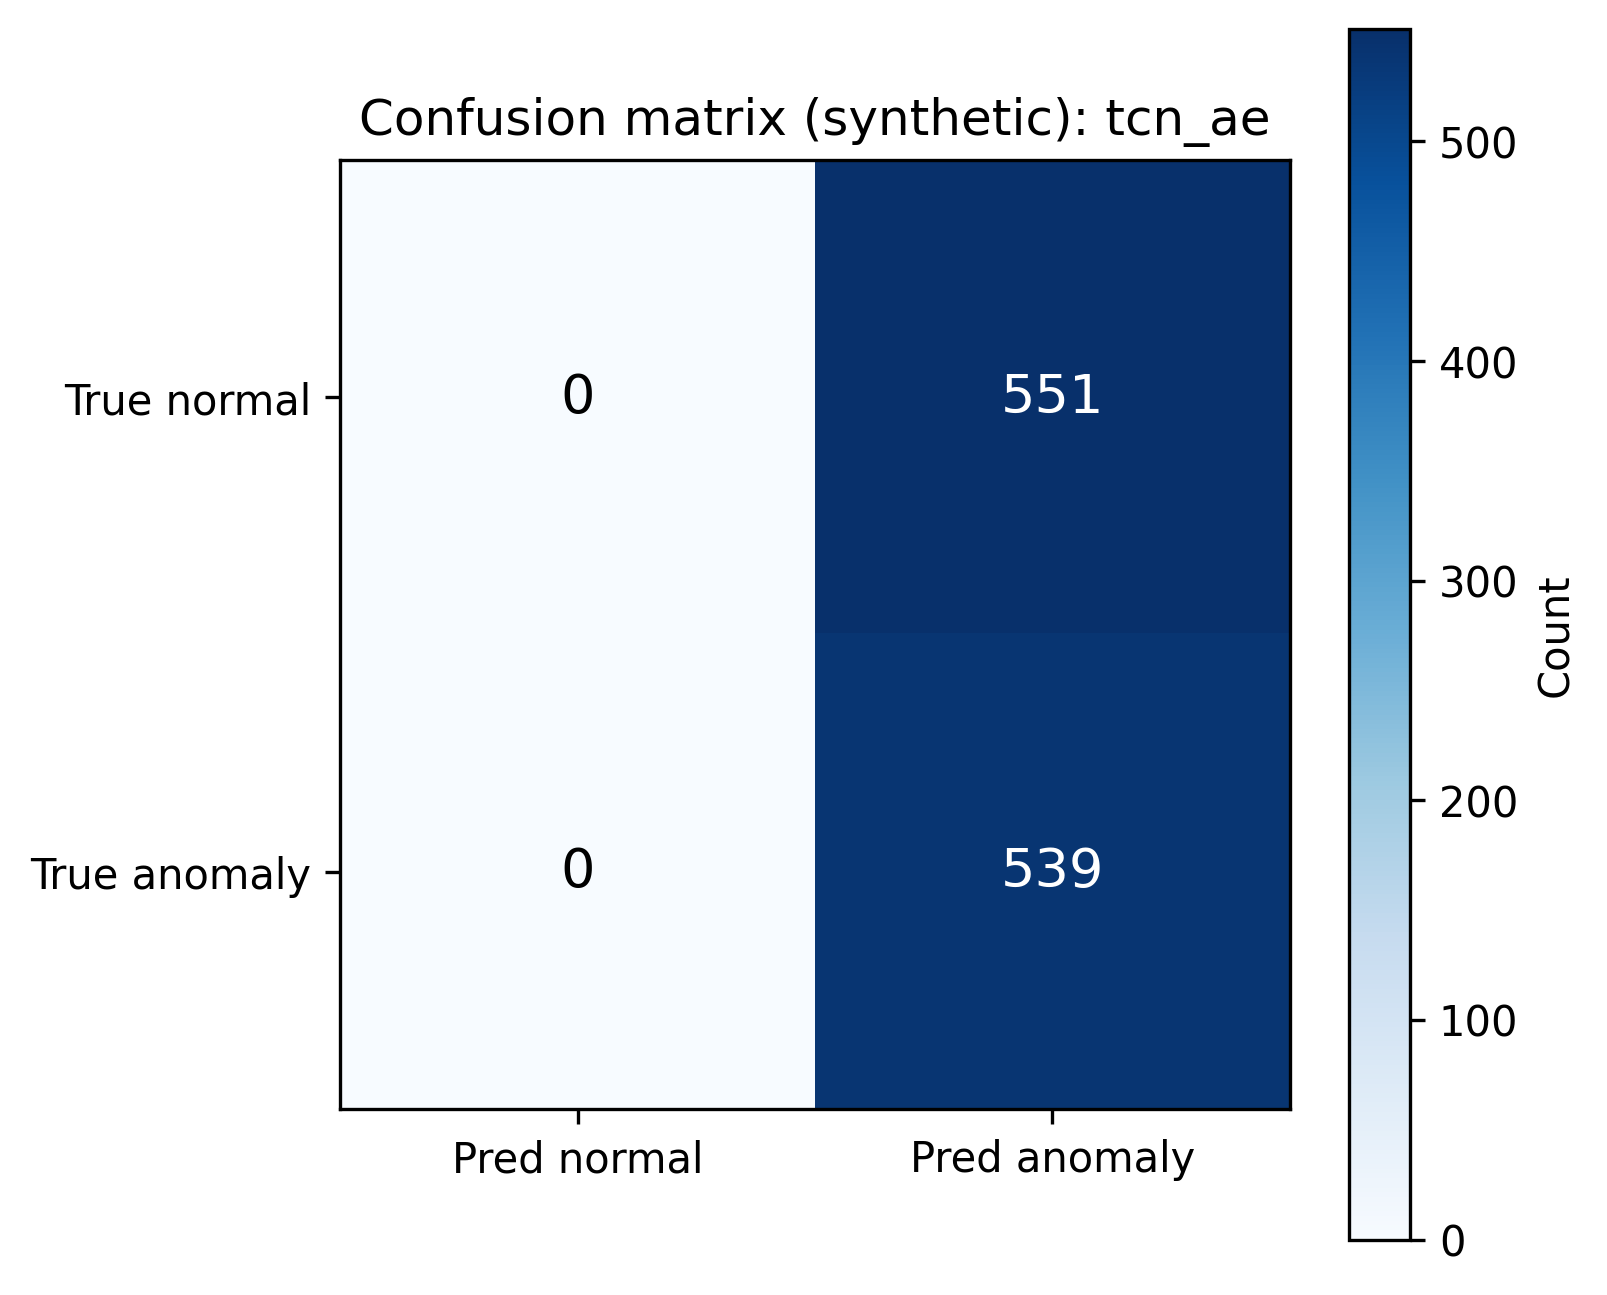

`confusion_matrix_tcn_transformer_ae_combined.png`

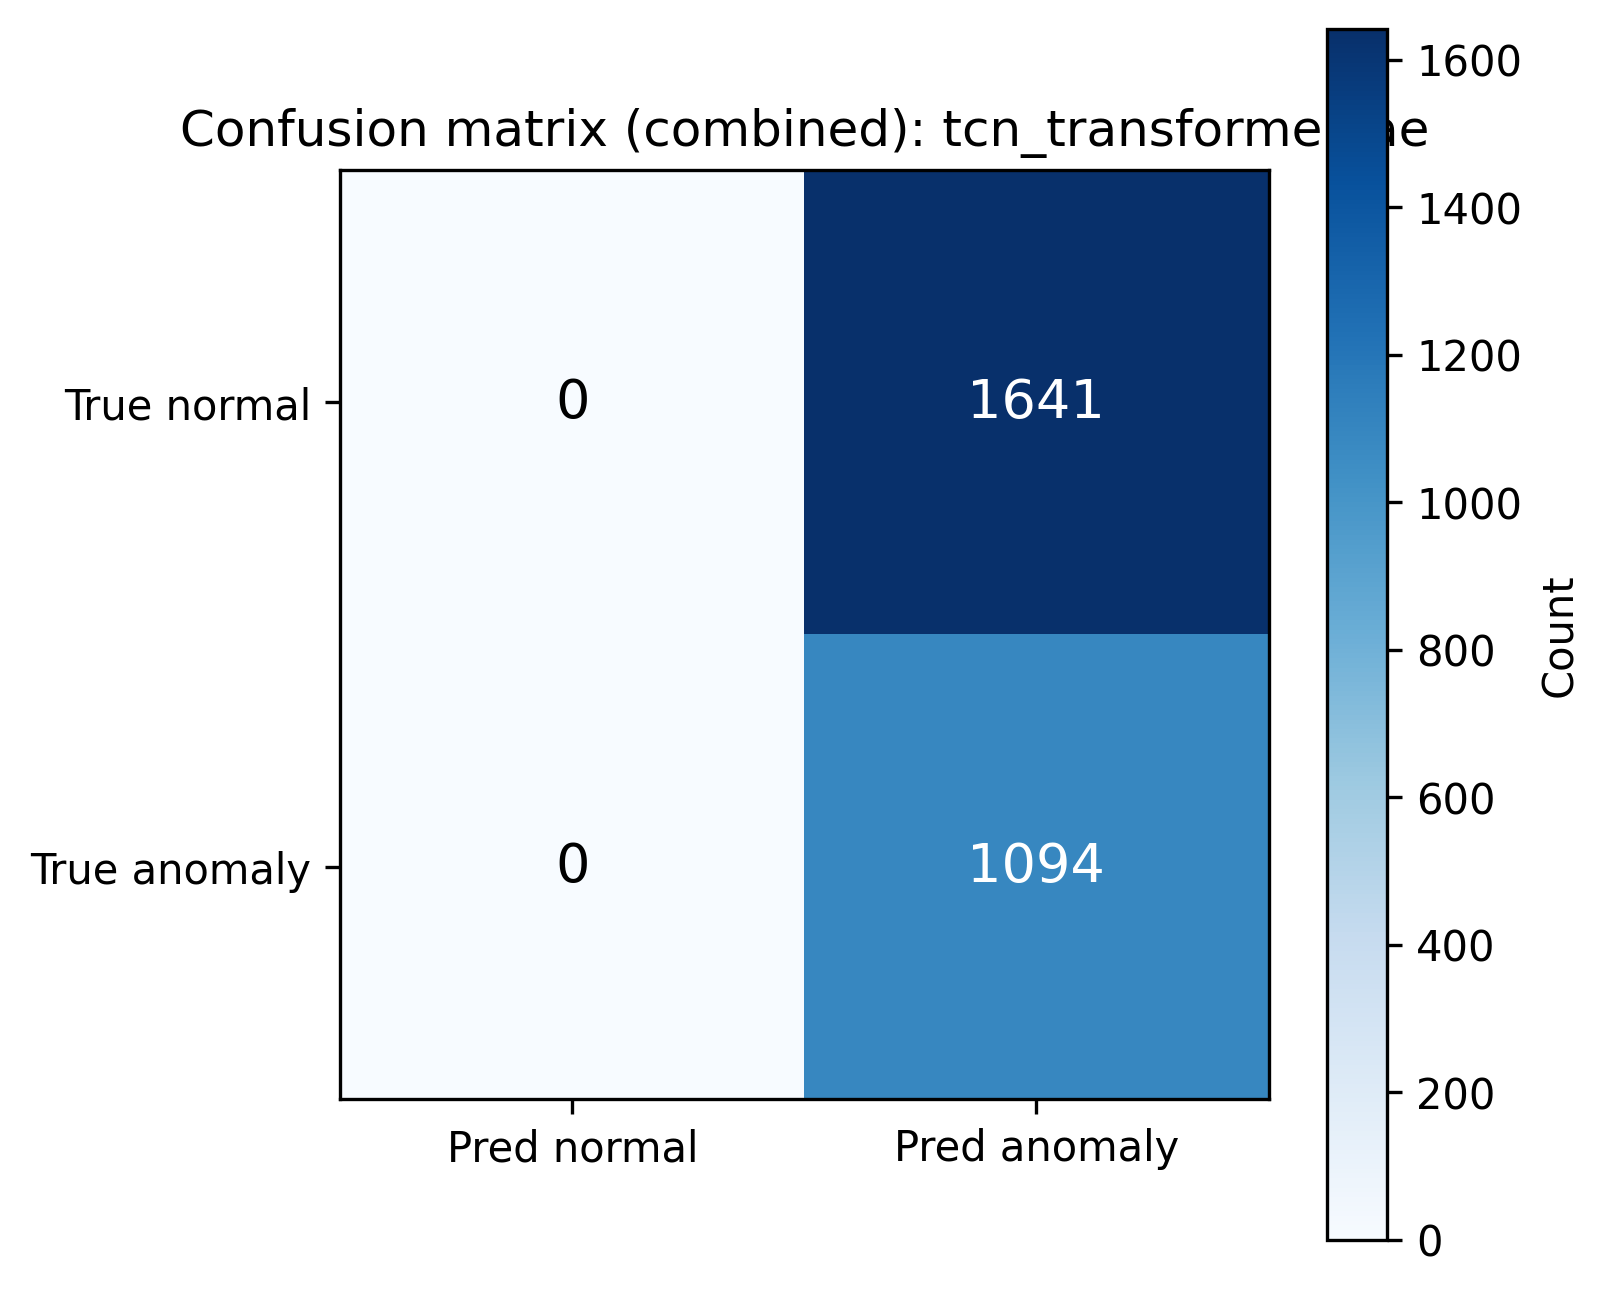

`confusion_matrix_tcn_transformer_ae_ensemble_combined.png`

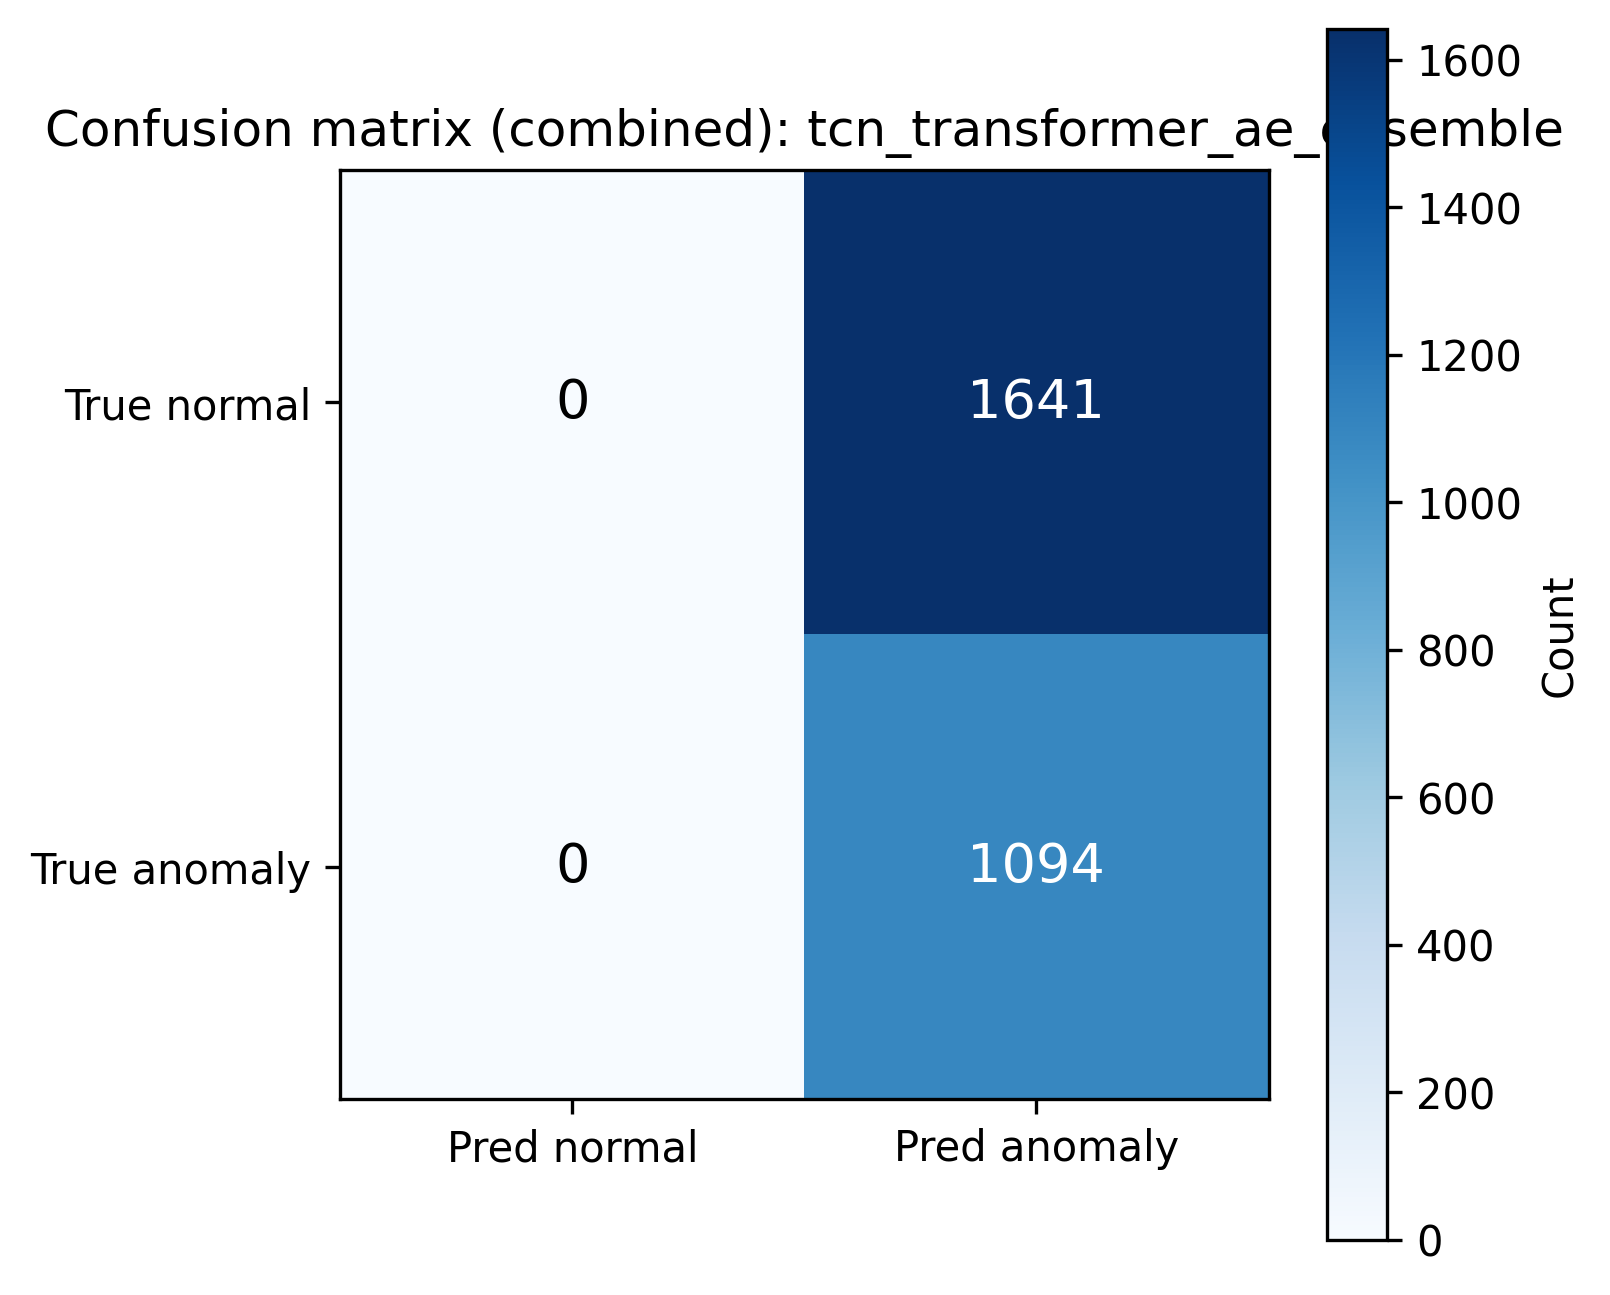

`confusion_matrix_tcn_transformer_ae_ensemble_real.png`

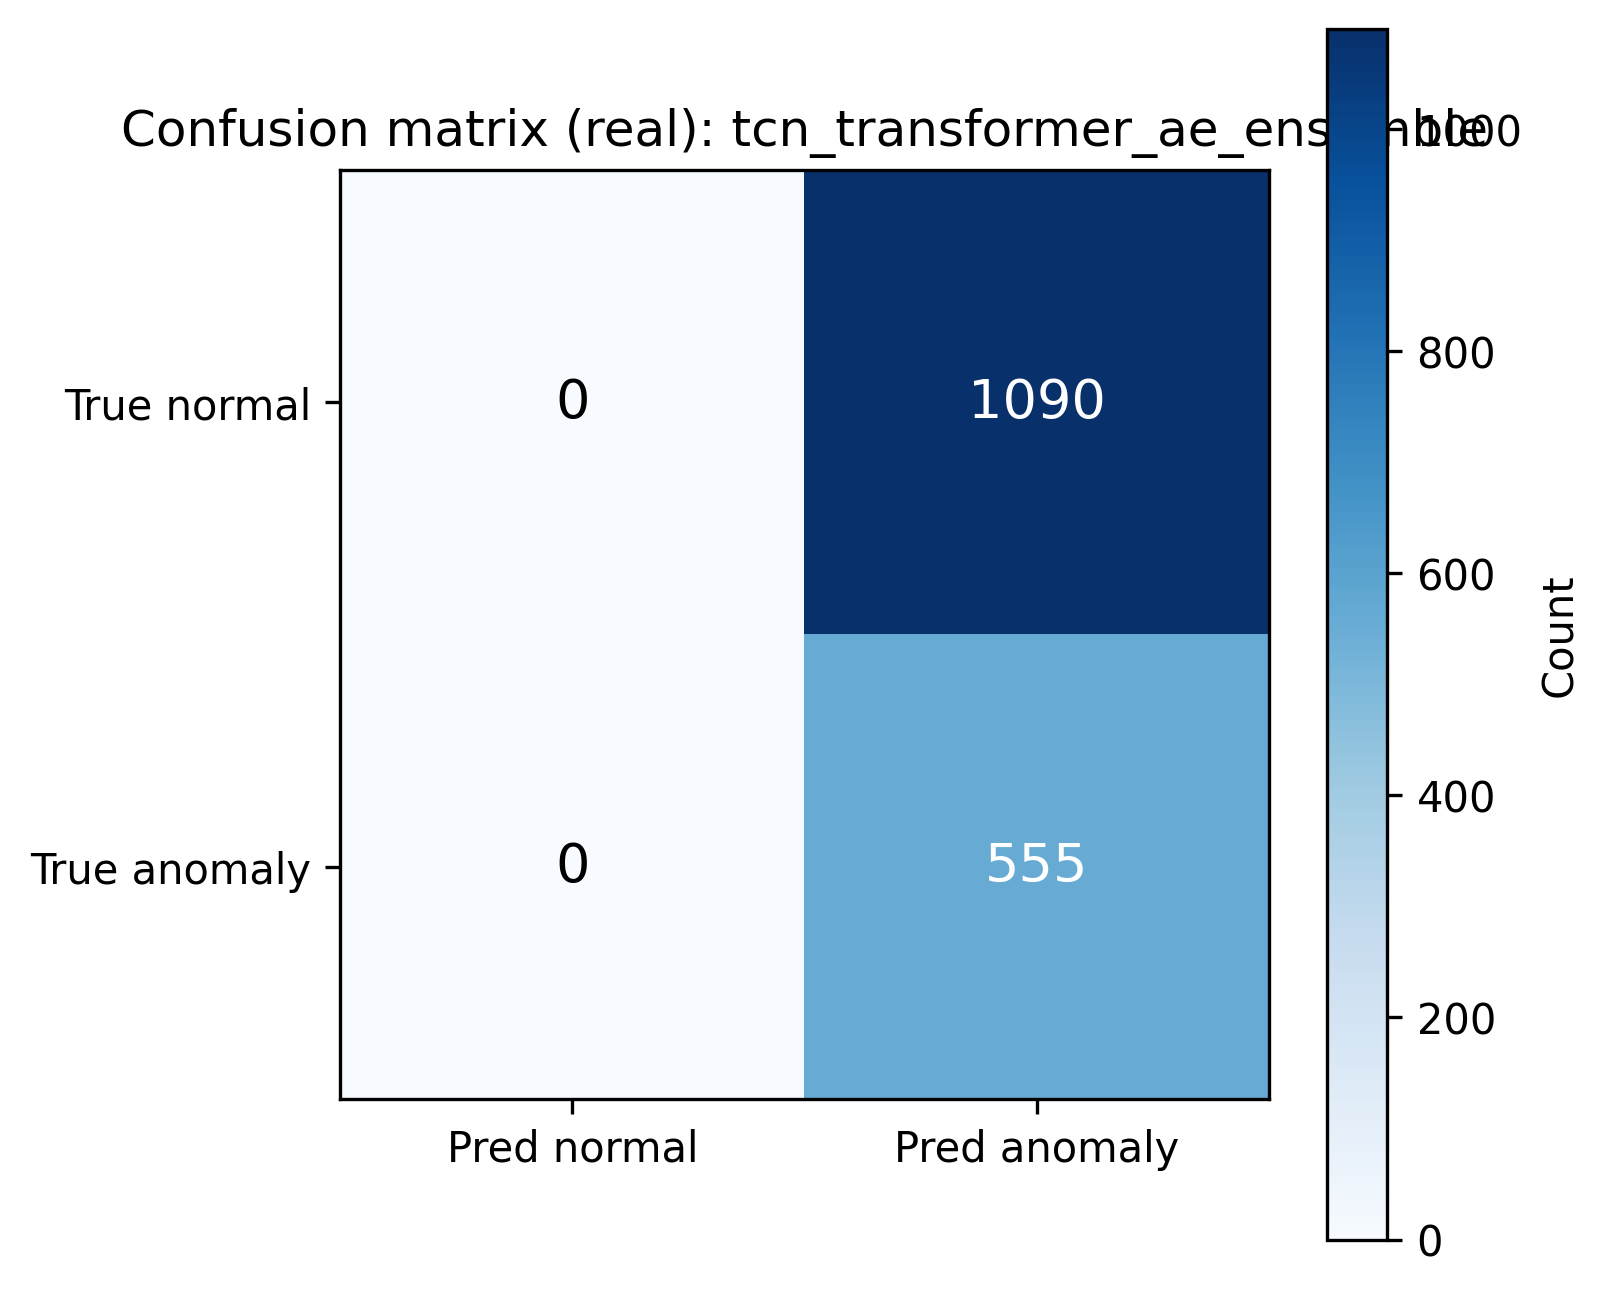

`confusion_matrix_tcn_transformer_ae_ensemble_synthetic.png`

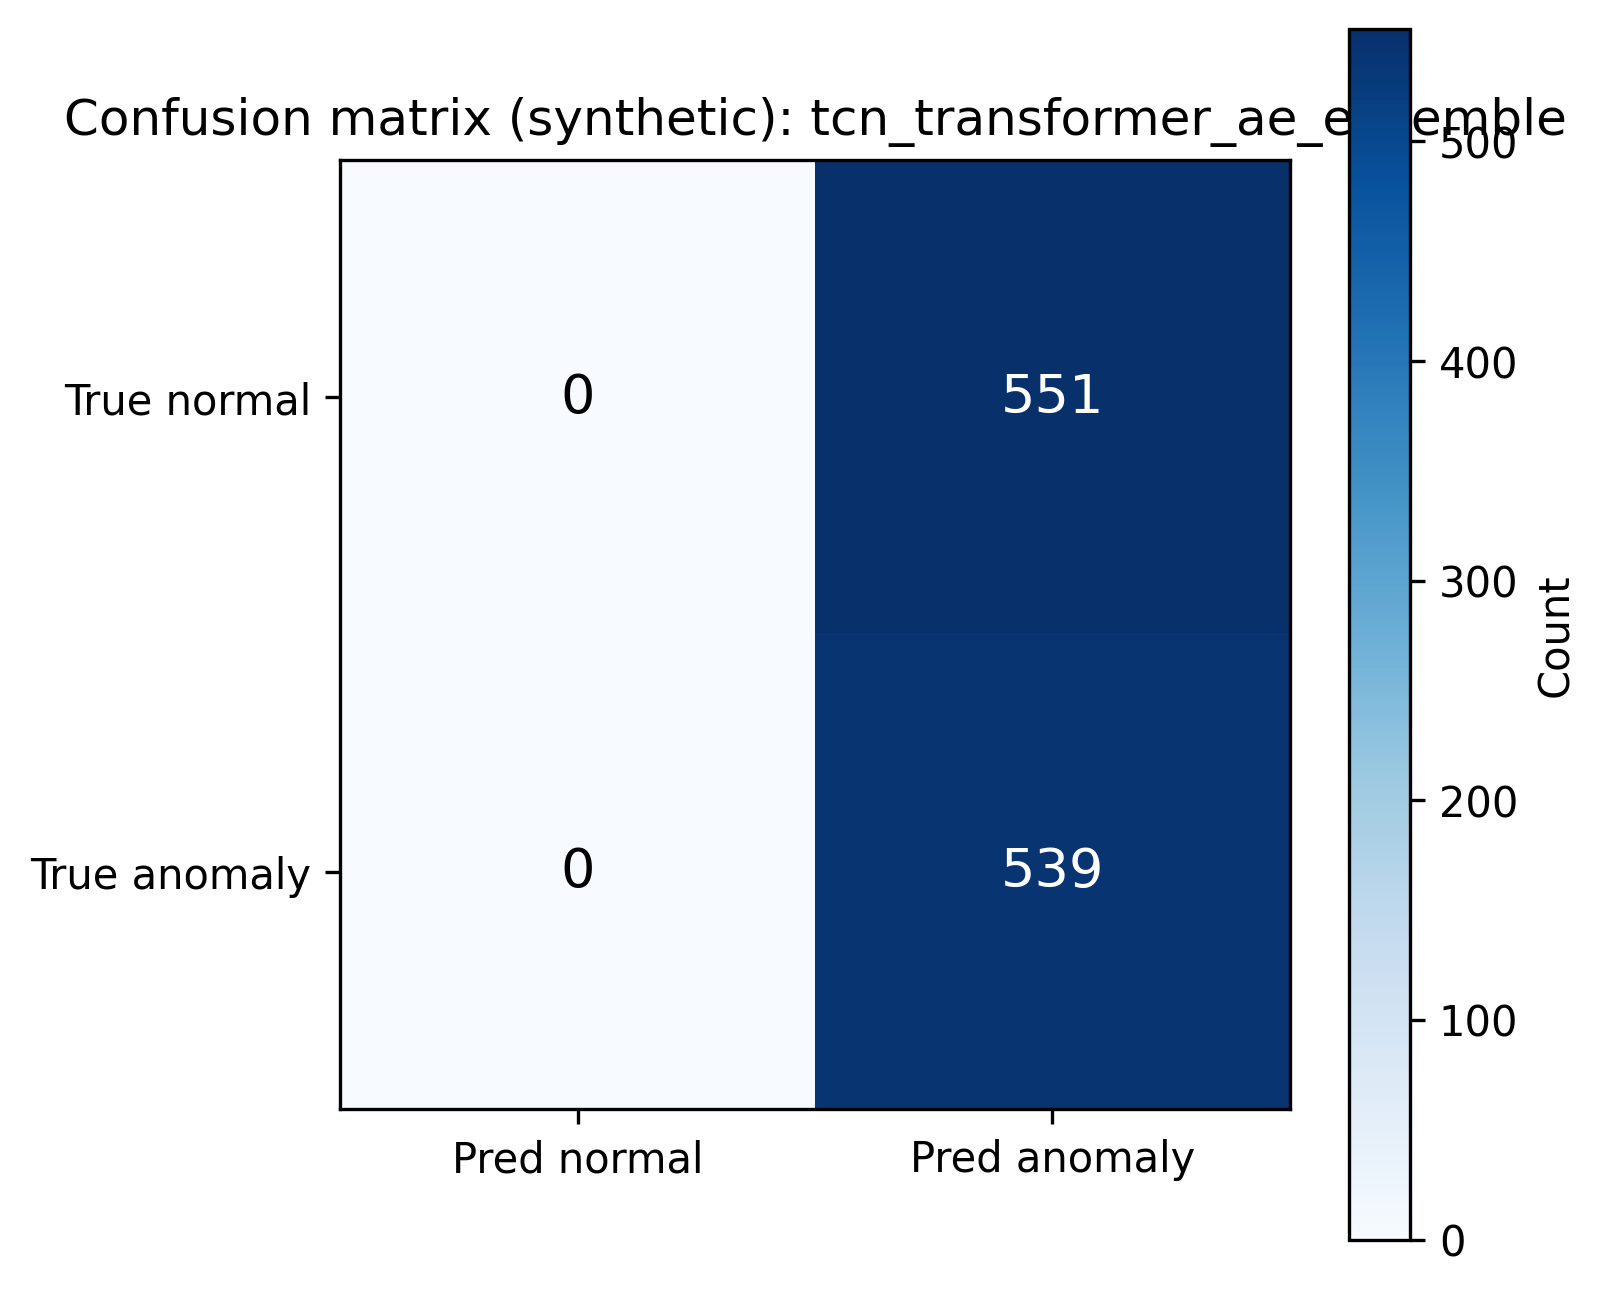

`confusion_matrix_tcn_transformer_ae_real.png`

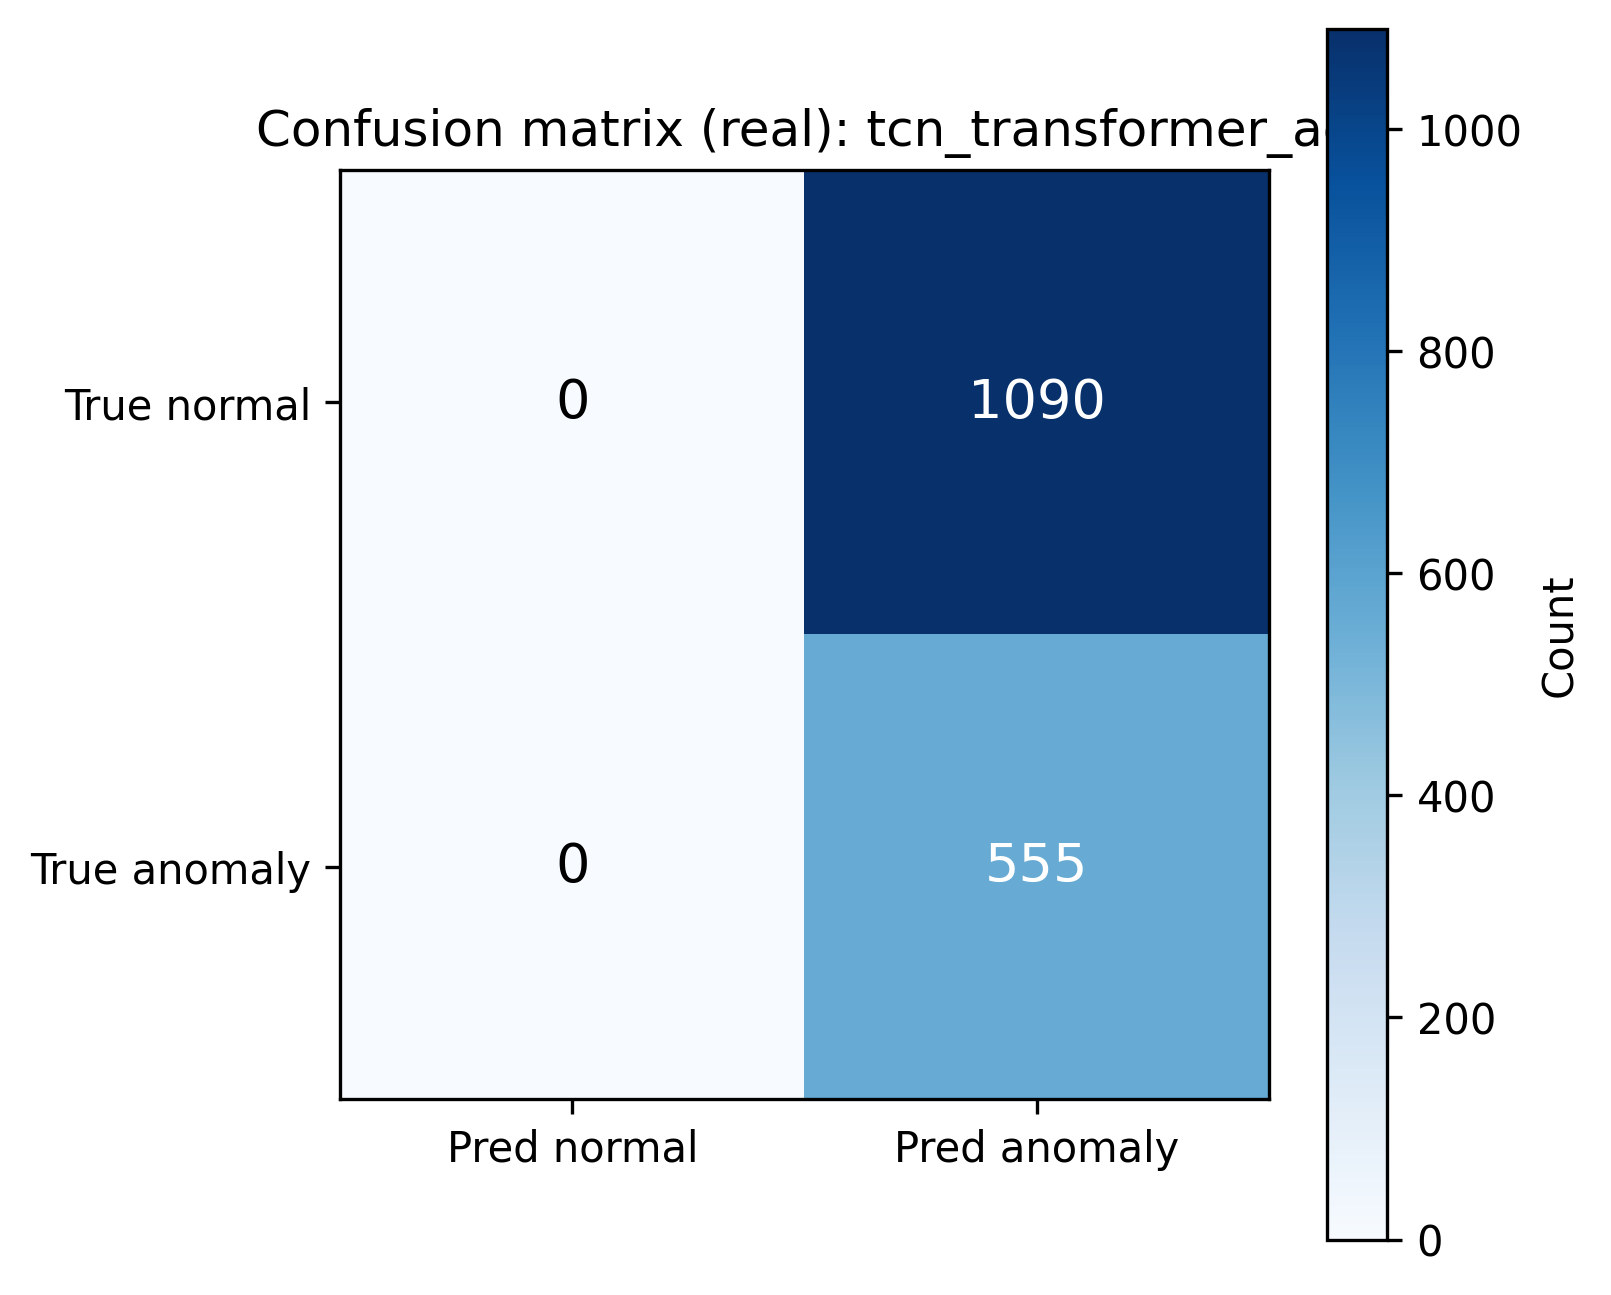

`confusion_matrix_tcn_transformer_ae_synthetic.png`

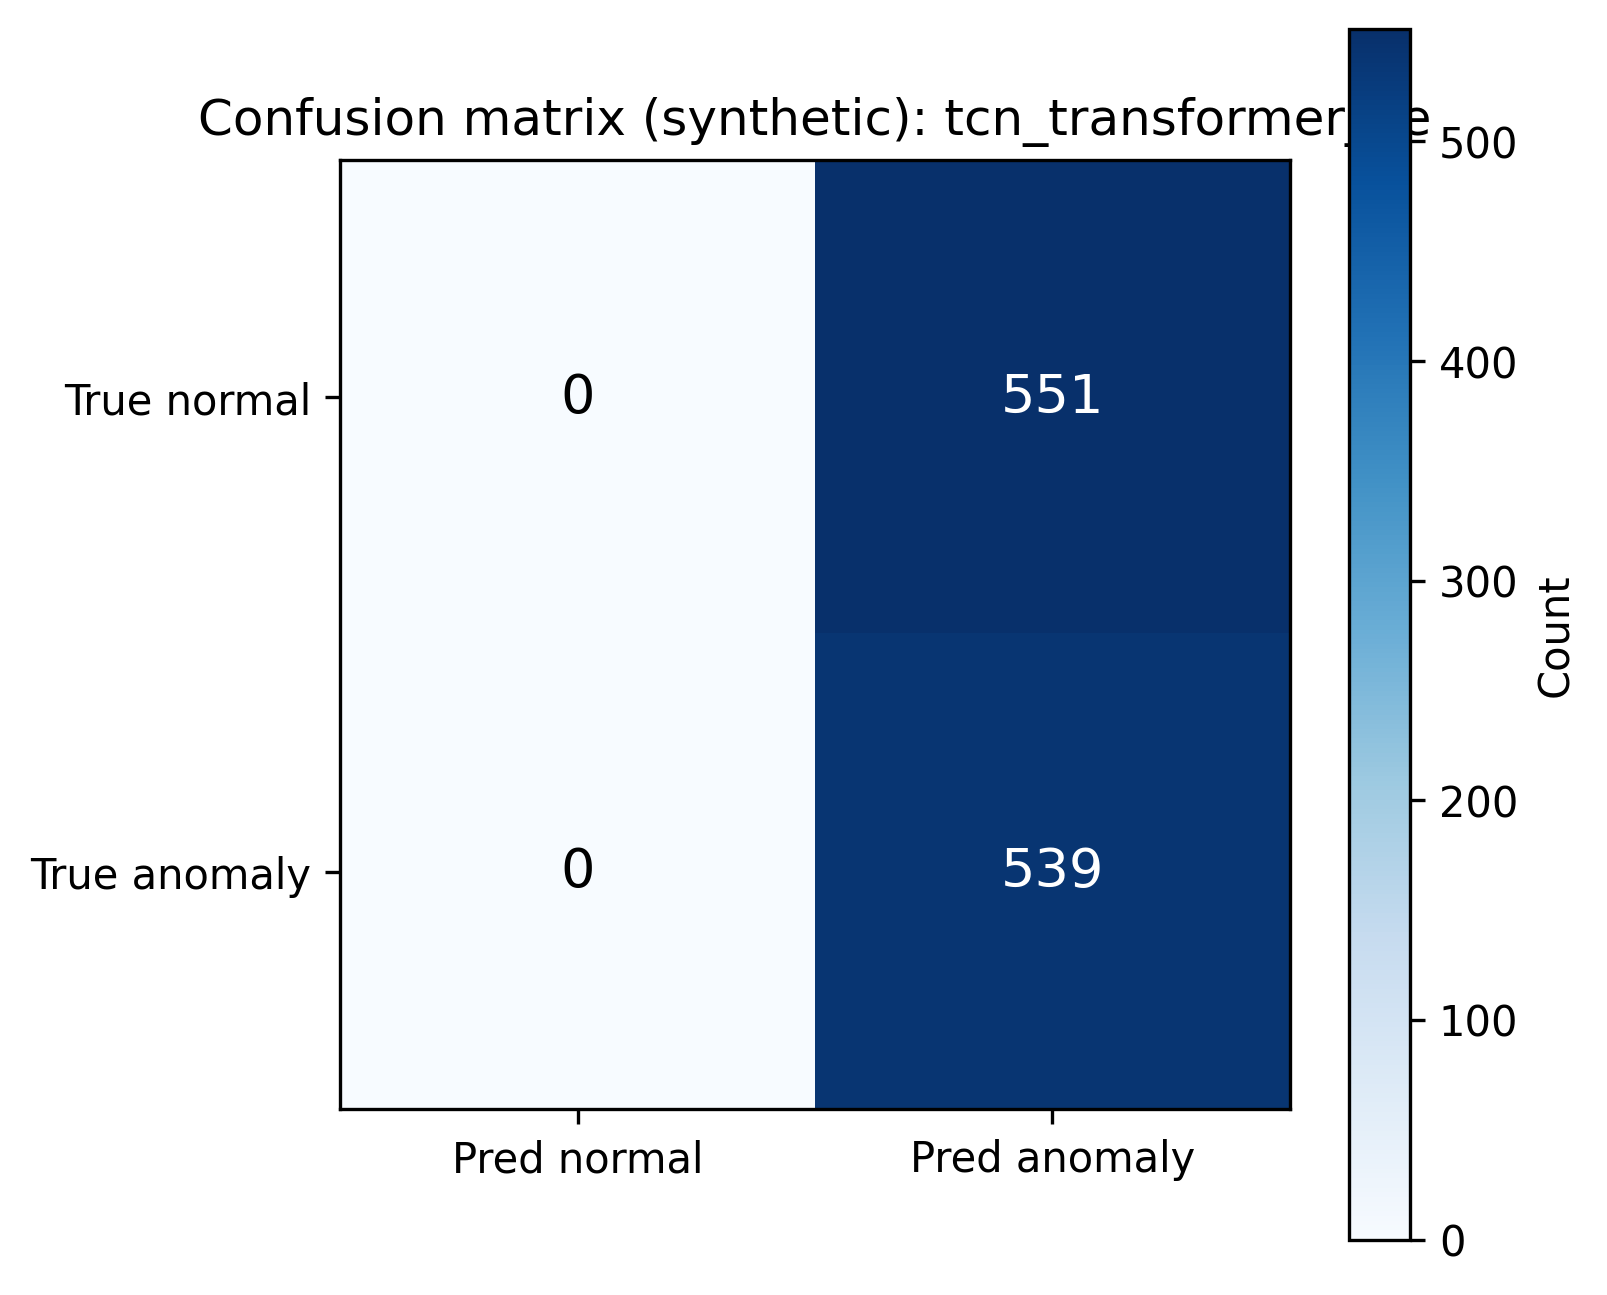

**Общие heatmap**

`aggregate_heatmap_tcn_ae_reconstruction.png`

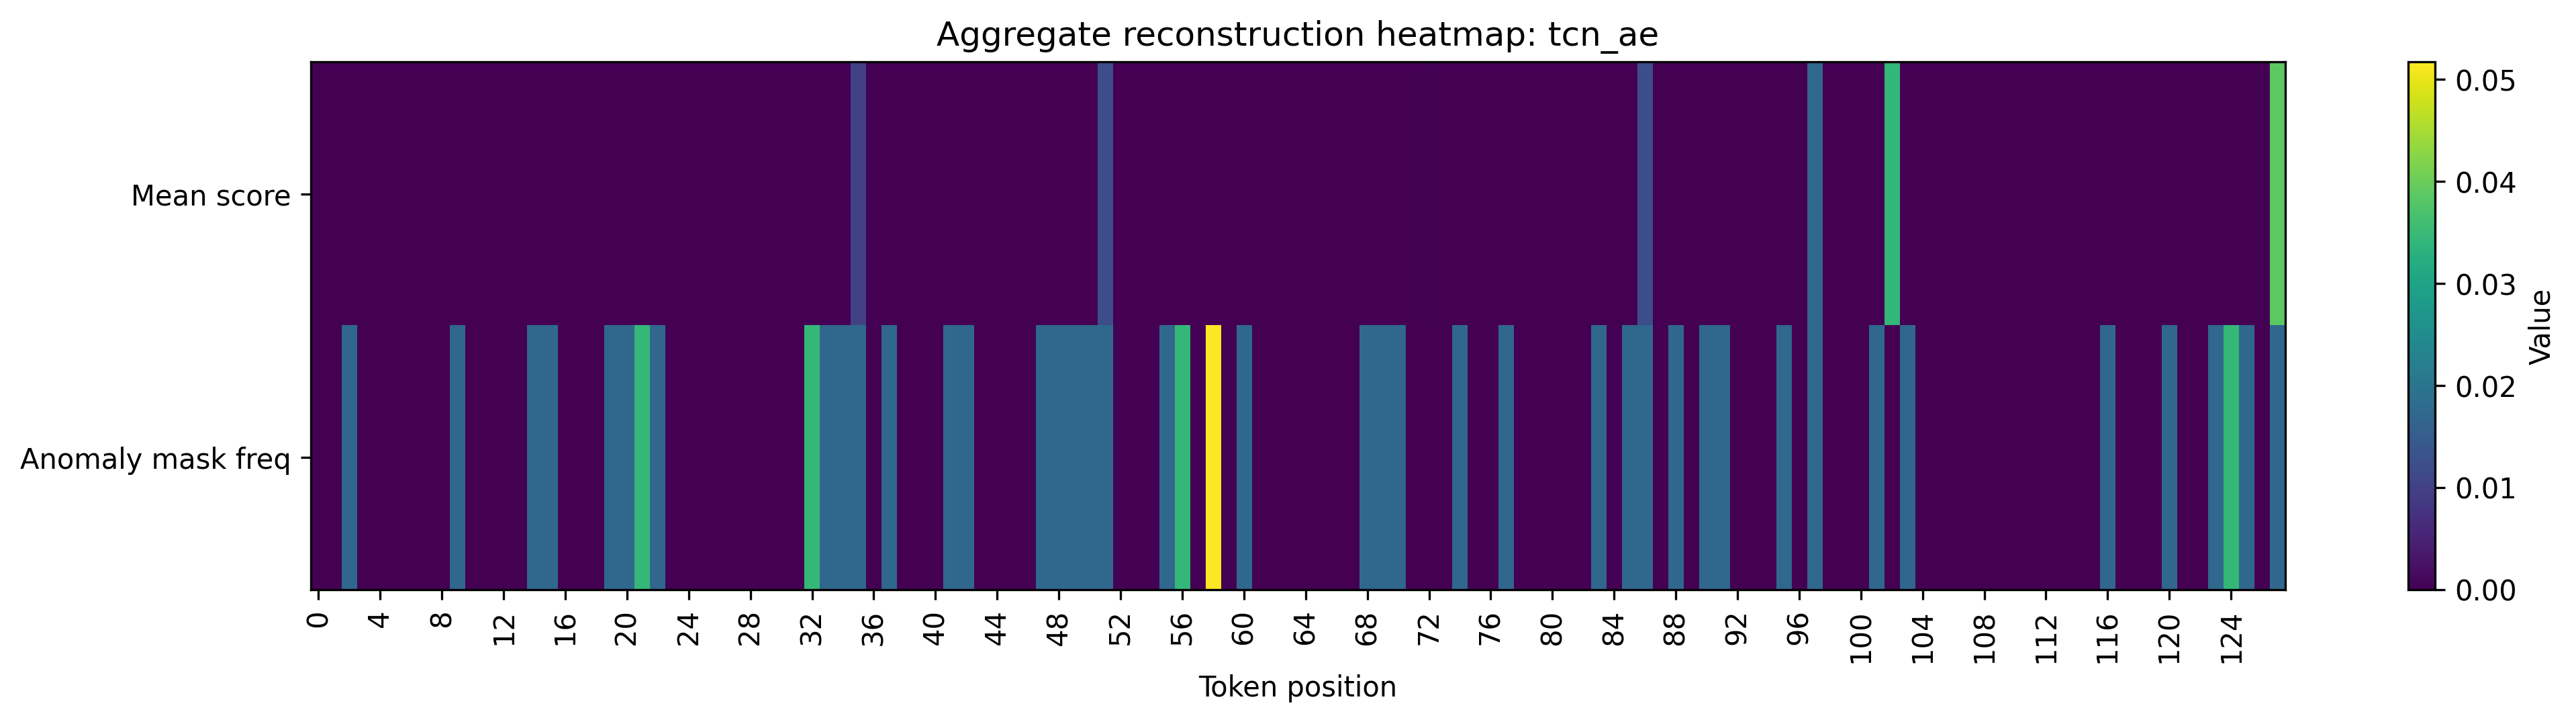

`aggregate_heatmap_tcn_transformer_ae_attention.png`

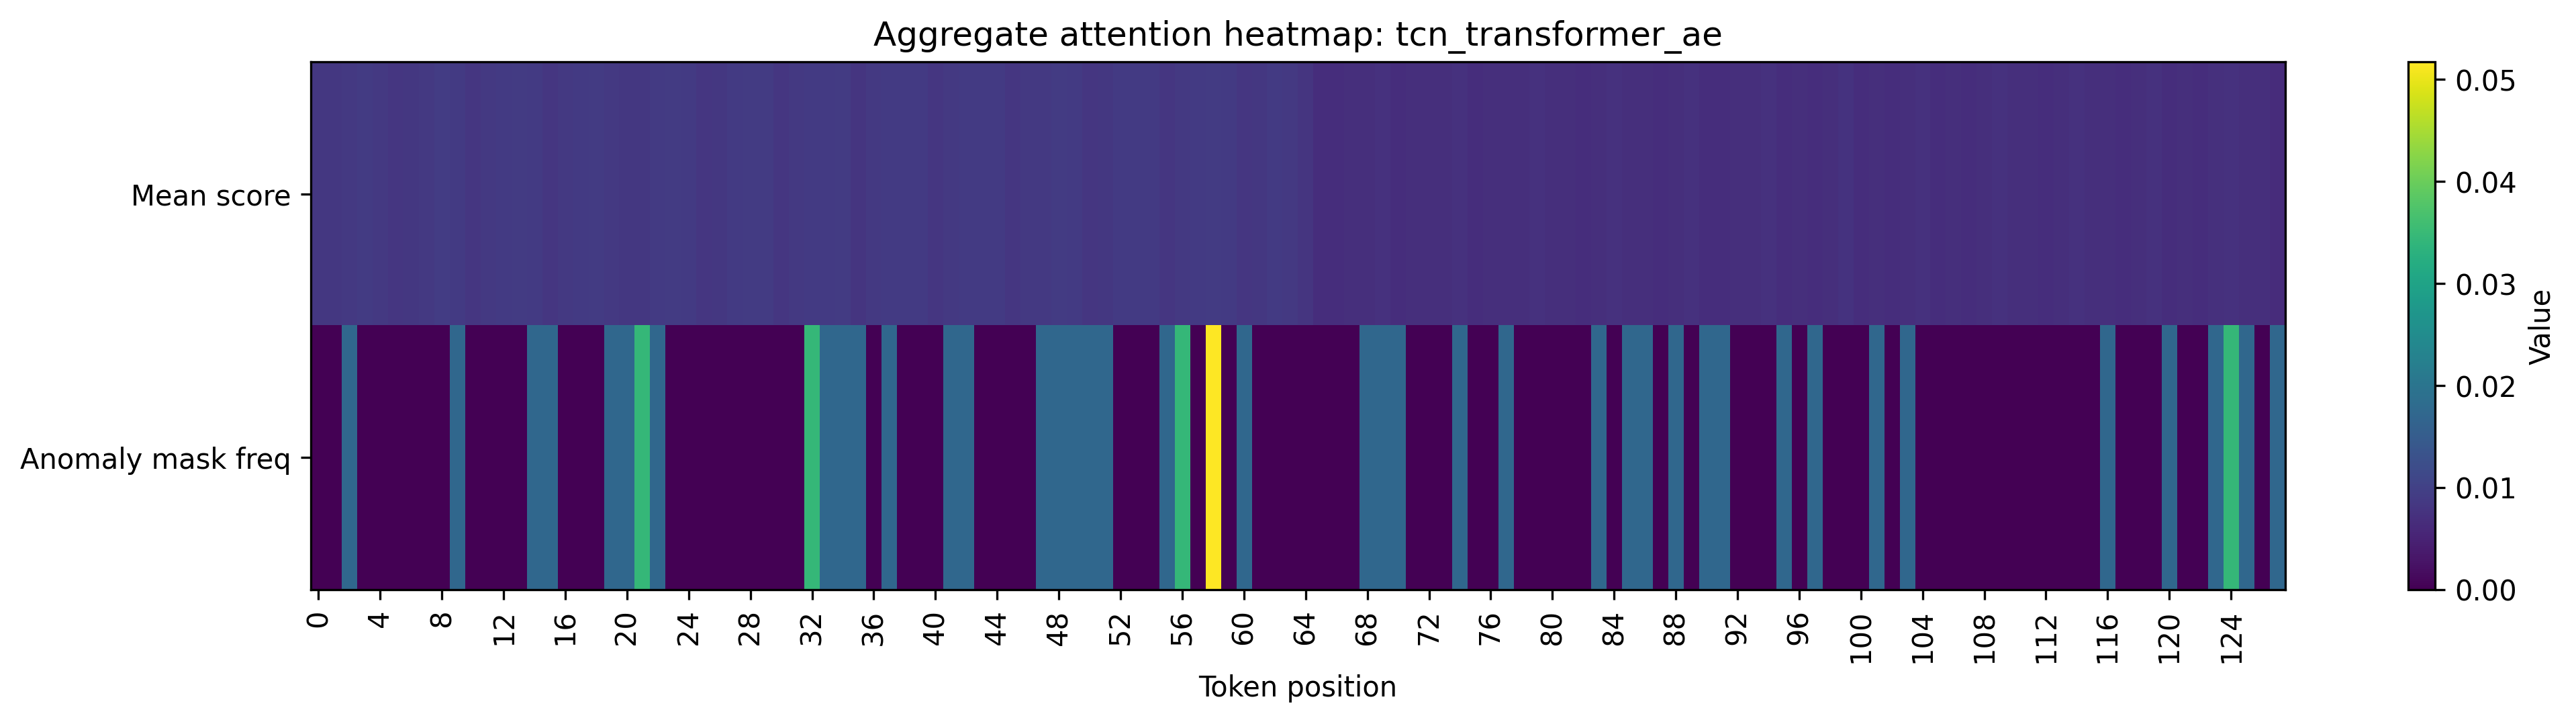

`aggregate_heatmap_tcn_transformer_ae_ensemble_attention.png`

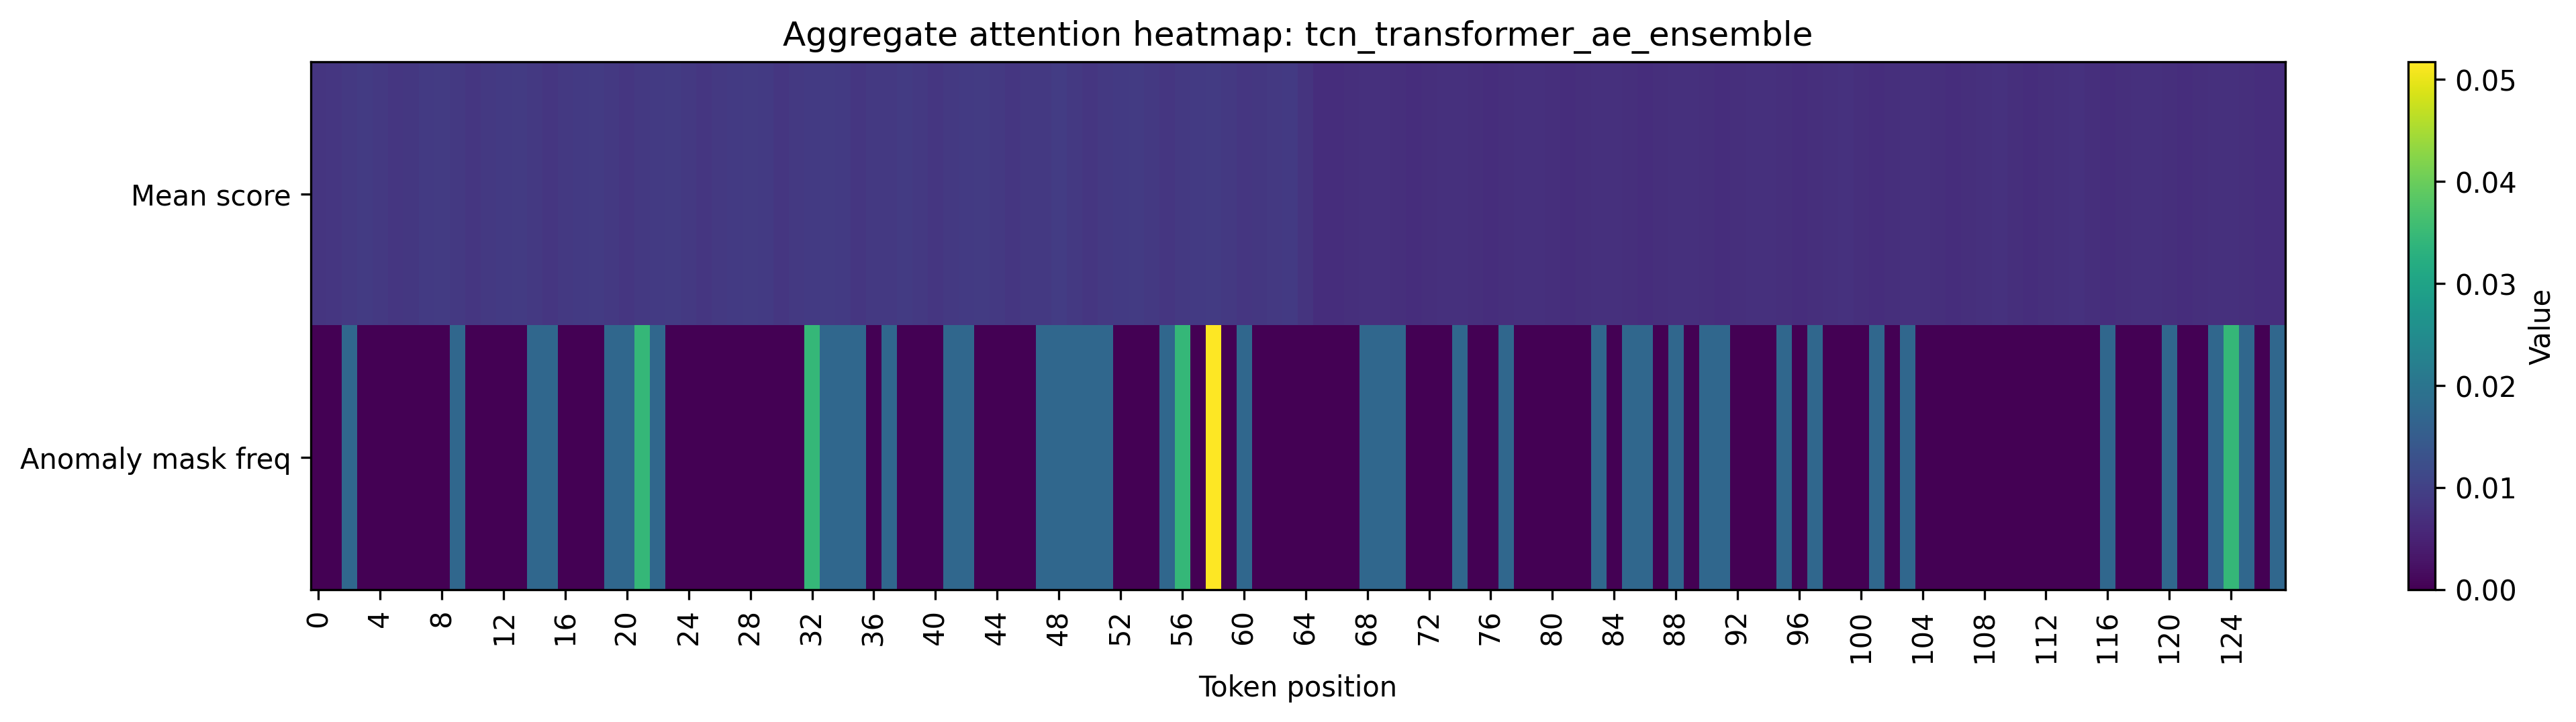

`aggregate_heatmap_tcn_transformer_ae_reconstruction.png`

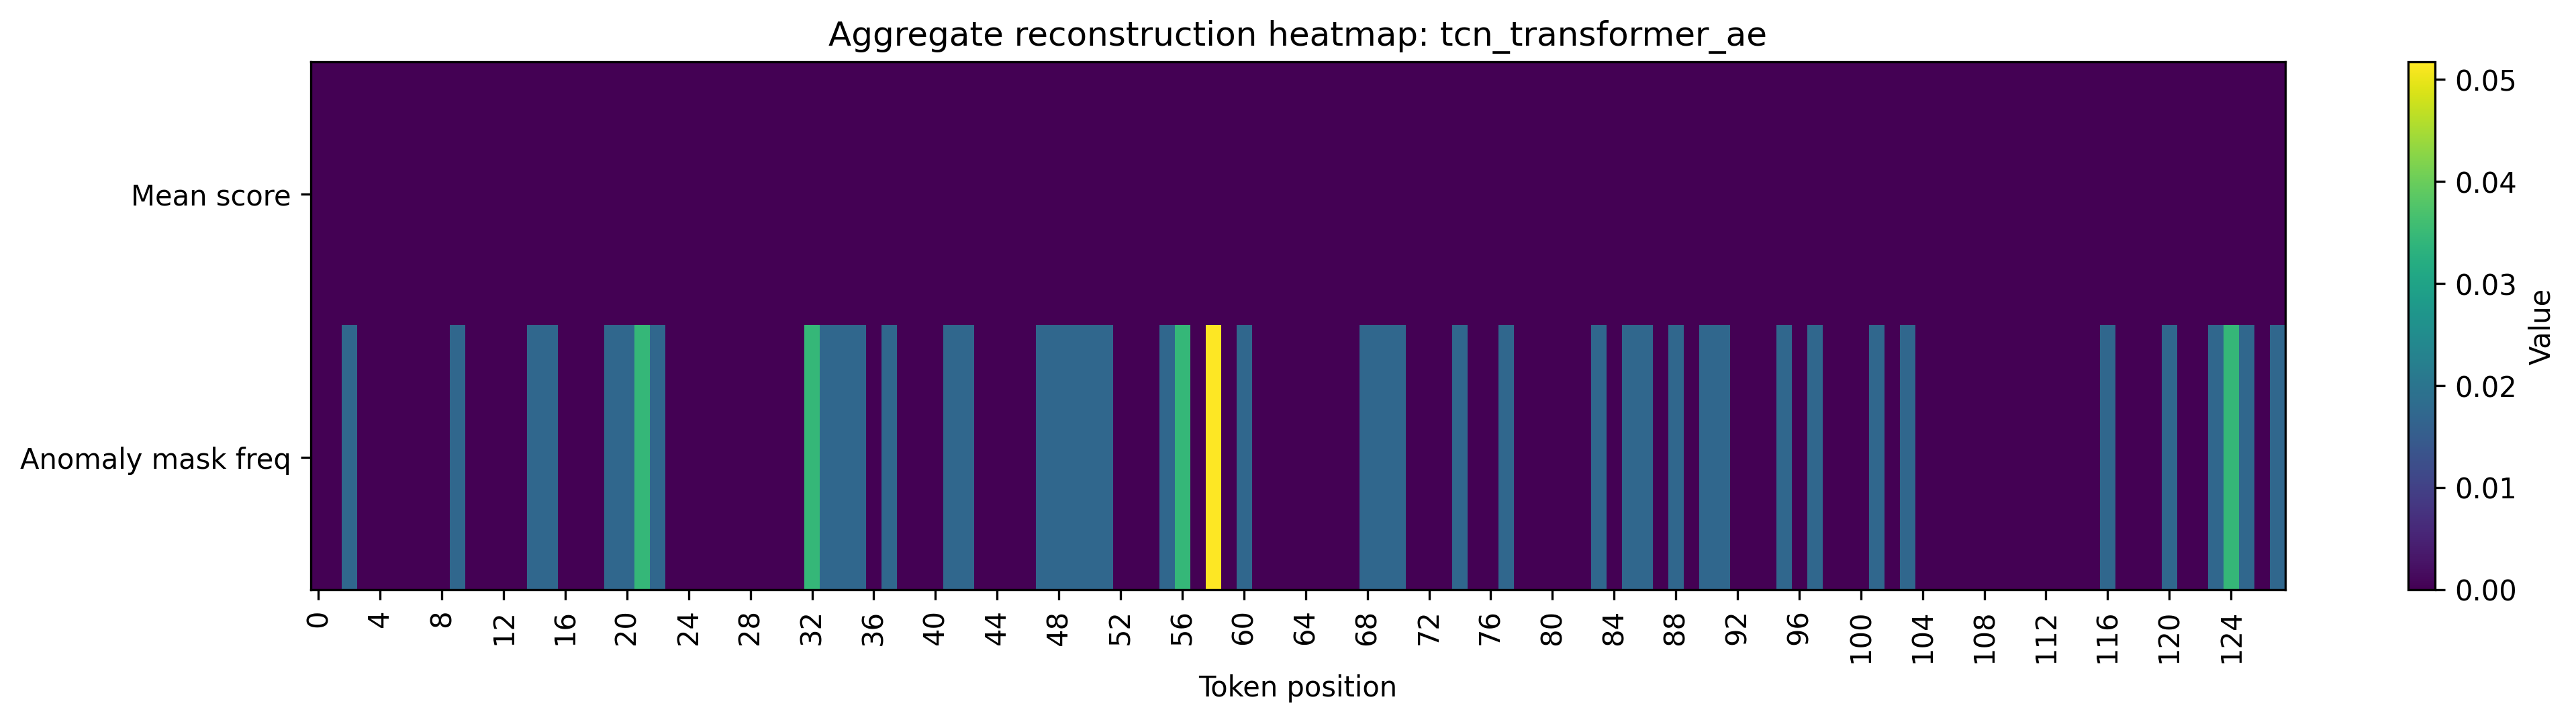

In [16]:
from IPython.display import Image, Markdown, display

for dataset_name, state in DATASET_STATE.items():
    figures_dir = state['output_dir'] / 'figures'
    display(Markdown(f'### {dataset_name}'))
    if not figures_dir.exists():
        display(Markdown(f'Нет папки с картинками: `{figures_dir}`'))
        continue

    confusion_paths = sorted(figures_dir.glob('confusion_matrix_*.png'))
    heatmap_paths = sorted(figures_dir.glob('aggregate_heatmap_*.png'))

    display(Markdown('**Матрицы ошибок**'))
    if confusion_paths:
        for path in confusion_paths:
            display(Markdown(f'`{path.name}`'))
            display(Image(filename=str(path)))
    else:
        display(Markdown('Пока нет `confusion_matrix_*.png`. Запусти evaluation/report для этого датасета.'))

    display(Markdown('**Общие heatmap**'))
    if heatmap_paths:
        for path in heatmap_paths:
            display(Markdown(f'`{path.name}`'))
            display(Image(filename=str(path)))
    else:
        display(Markdown('Пока нет `aggregate_heatmap_*.png`. Запусти localization/report для этого датасета.'))
